In [24]:
import os
from pathlib import Path
%matplotlib inline

%load_ext autoreload
%autoreload 2
    
import seaborn as sns

from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt


def calculate_gait_mae(ground_truth: np.ndarray, prediction: np.ndarray, tolerance: int = 20):
    """
    Matches gait events and computes overall and per-class MAE in one pass.

    Args:
        ground_truth: Array of ground truth labels.
        prediction: Array of predicted labels.
        tolerance: Max distance to consider a match.

    Returns:
        A tuple containing:
        - overall_mae (float): The MAE across all matched events.
        - per_class_mae (dict): A dictionary mapping class labels to their MAE.
    """
    gt_indices = np.where(ground_truth > 0)[0]
    available_preds = list(np.where(prediction > 0)[0])
    
    # Store tuples of (label, absolute_error) for each successful match
    errors_by_class = []
    
    # Greedily match each ground truth event to the closest prediction
    for gt_idx in gt_indices:
        gt_label = ground_truth[gt_idx]
        best_dist = float('inf')
        best_match_idx = -1
        
        # Find the closest available prediction of the same class within tolerance
        for pred_idx in available_preds:
            if prediction[pred_idx] == gt_label:
                dist = abs(gt_idx - pred_idx)
                if dist <= tolerance and dist < best_dist:
                    best_dist = dist
                    best_match_idx = pred_idx
        
        # If a match is found, record its error and remove it from the pool
        if best_match_idx != -1:
            error = abs(gt_idx - best_match_idx)
            errors_by_class.append((gt_label, error))
            available_preds.remove(best_match_idx)
            
    if not errors_by_class:
        return np.nan, {}

    # --- Calculate Final Metrics ---
    
    # Overall MAE is the mean of all collected errors
    all_errors = [err for lbl, err in errors_by_class]
    overall_mae = np.mean(all_errors)
    
    # Per-class MAE is calculated by grouping errors by label
    unique_labels = sorted(np.unique([lbl for lbl, err in errors_by_class]))
    per_class_mae = {
        int(label): np.mean([err for lbl, err in errors_by_class if lbl == label])
        for label in unique_labels
    }
    
    return overall_mae, per_class_mae


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Evaluate external dataset

In [25]:
import os
from pathlib import Path
%matplotlib inline
import seaborn as sns

from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt

In [26]:
from glob import glob
import numpy as np
from gait_ml import plotting
from gait_ml.data.datamodule import ExternalGaitDataModule
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Zero shot evaluation

In [27]:
# all_files = np.sort(glob("/home/qivy00li/projects/gait_ml/data/processed/external_data1/**/*.npy", recursive=True))
# Load dataset
all_files = np.sort(glob("/home/qivy00li/projects/gait_ml/data/processed/external_data1/**/levelground/imu/levelground_*_normal_*.npy", recursive=True))
cur_set_to_test = np.arange(len(all_files))

### 1.1 Load best model

In [28]:
with initialize(config_path="../configs", job_name="train", version_base="1.3"):
    config = compose(config_name="train_config")

pl.seed_everything(config.general.random_state)
print(f"Processing: {len(all_files)} samples")

model = LitSeq2Seq(
    input_dim=config.model.input_dim,
    output_dim=config.model.output_dim,
    hidden_dim=config.model.hidden_dim,
    num_layers=config.model.num_layers,
    dropout_prob=config.model.dropout_prob,
    learning_rate=config.model.learning_rate,
    teacher_forcing_ratio=config.model.teacher_forcing_ratio,
)

# model_fpath = "/home/qivy00li/projects/gait_ml/backpain/RerunExp-Fold1-GRU-expandlabel8_2025-11-05_16-14-27/checkpoints/model-epoch=46-val_f1score=0.94.ckpt"
# Zero shot
# model_fpath = "/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-10_15-13-18/checkpoints/model-epoch=97-val_f1score=0.88.ckpt"

# # Finetuning 1
model_fpath = "/home/qivy00li/projects/gait_ml/notebooks/backpain/ExternalDataset1FinetuneExp2-Fold1-GRU-expandlabel2_2025-11-12_12-23-04/checkpoints/model-epoch=124-val_f1score=0.91.ckpt"

# # Finetuning 2

device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
best_model = LitSeq2Seq.load_from_checkpoint(model_fpath).to(device_)

Seed set to 42


Processing: 202 samples


### 1.2 Evaluate model

 === Currently Evaluating curr_test_idx: 0 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


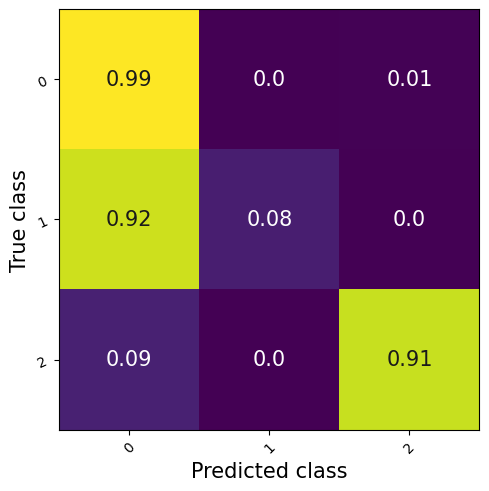

tensor([[1757,    1,   11],
        [  11,    1,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.5870 ✨
perclass_f1scores: tensor([0.9932, 0.1429, 0.6250])
perclass_precision: tensor([0.9932, 0.5000, 0.4762])
perclass_recall: tensor([0.9932, 0.0833, 0.9091])
MAE overall: 2.0000 ✨
MAE per_class: {1: np.float64(3.5), 2: np.float64(1.7272727272727273)} ✨
 === Currently Evaluating curr_test_idx: 1 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_02_

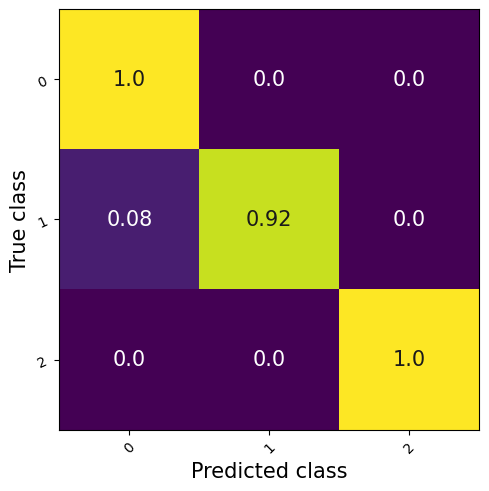

tensor([[1768,    1,    0],
        [   1,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9720 ✨
perclass_f1scores: tensor([0.9994, 0.9167, 1.0000])
perclass_precision: tensor([0.9994, 0.9167, 1.0000])
perclass_recall: tensor([0.9994, 0.9167, 1.0000])
MAE overall: 1.1739 ✨
MAE per_class: {1: np.float64(1.4166666666666667), 2: np.float64(0.9090909090909091)} ✨
 === Currently Evaluating curr_test_idx: 2 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground

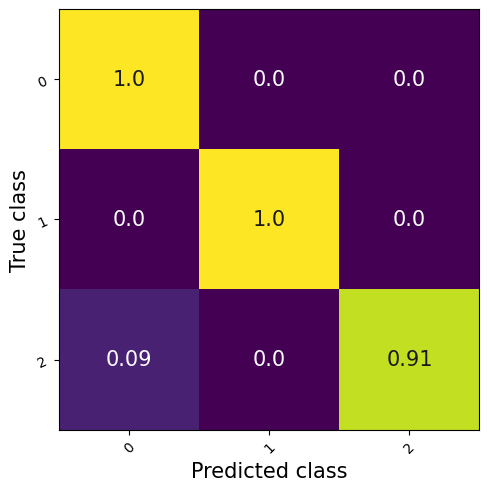

tensor([[1768,    1,    1],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9549 ✨
perclass_f1scores: tensor([0.9992, 0.9565, 0.9091])
perclass_precision: tensor([0.9994, 0.9167, 0.9091])
perclass_recall: tensor([0.9989, 1.0000, 0.9091])
MAE overall: 1.6364 ✨
MAE per_class: {1: np.float64(1.8181818181818181), 2: np.float64(1.4545454545454546)} ✨
 === Currently Evaluating curr_test_idx: 3 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground

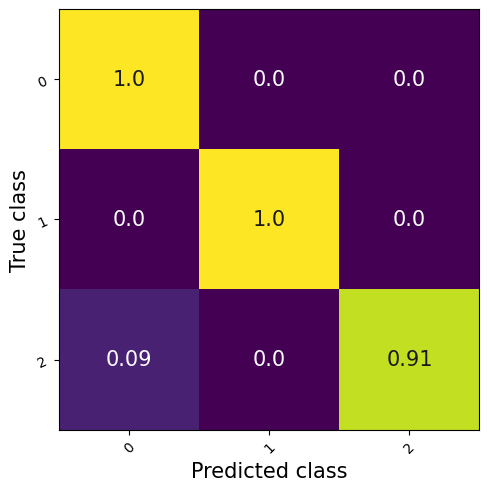

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9840 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9524])
perclass_precision: tensor([0.9993, 1.0000, 1.0000])
perclass_recall: tensor([1.0000, 1.0000, 0.9091])
MAE overall: 1.0952 ✨
MAE per_class: {1: np.float64(1.1818181818181819), 2: np.float64(1.0)} ✨
 === Currently Evaluating curr_test_idx: 4 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_05_

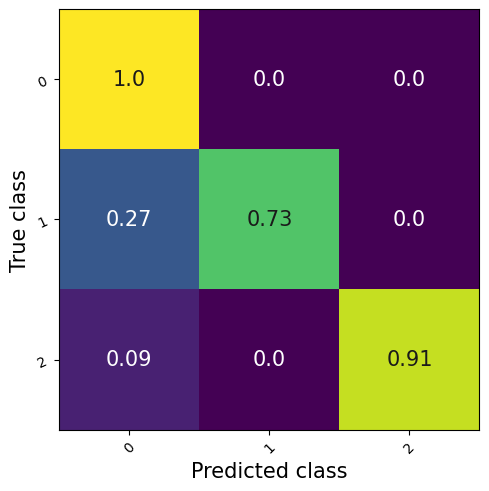

tensor([[1510,    3,    1],
        [   3,    8,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.8779 ✨
perclass_f1scores: tensor([0.9974, 0.7273, 0.9091])
perclass_precision: tensor([0.9974, 0.7273, 0.9091])
perclass_recall: tensor([0.9974, 0.7273, 0.9091])
MAE overall: 1.7273 ✨
MAE per_class: {1: np.float64(2.090909090909091), 2: np.float64(1.3636363636363635)} ✨
 === Currently Evaluating curr_test_idx: 5 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_

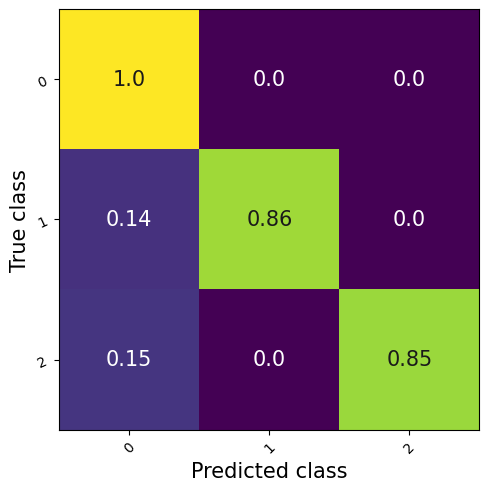

tensor([[1761,    0,    4],
        [   2,   12,    0],
        [   2,    0,   11]])
Macro F1-Score: 0.9022 ✨
perclass_f1scores: tensor([0.9977, 0.9231, 0.7857])
perclass_precision: tensor([0.9977, 1.0000, 0.7333])
perclass_recall: tensor([0.9977, 0.8571, 0.8462])
MAE overall: 1.4800 ✨
MAE per_class: {1: np.float64(1.4166666666666667), 2: np.float64(1.5384615384615385)} ✨
 === Currently Evaluating curr_test_idx: 6 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground

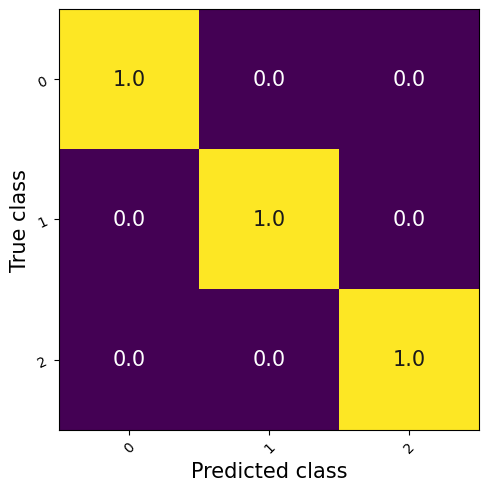

tensor([[1766,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.3077 ✨
MAE per_class: {1: np.float64(1.2857142857142858), 2: np.float64(1.3333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 7 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_03_01.npy
self.expand_lab

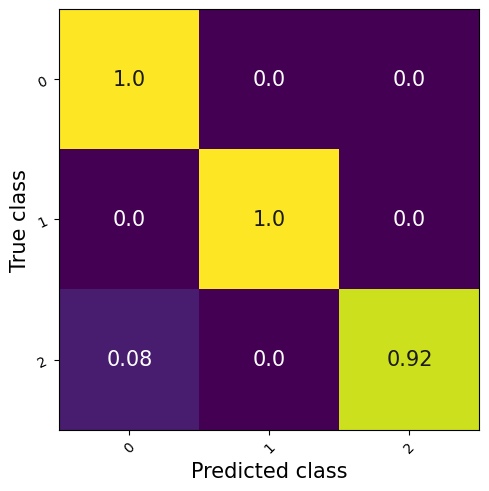

tensor([[1764,    0,    1],
        [   0,   14,    0],
        [   1,    0,   12]])
Macro F1-Score: 0.9742 ✨
perclass_f1scores: tensor([0.9994, 1.0000, 0.9231])
perclass_precision: tensor([0.9994, 1.0000, 0.9231])
perclass_recall: tensor([0.9994, 1.0000, 0.9231])
MAE overall: 1.1852 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(1.3846153846153846)} ✨
 === Currently Evaluating curr_test_idx: 8 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_04_0

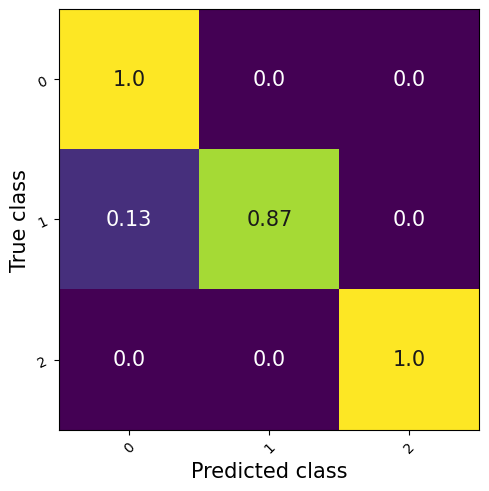

tensor([[1762,    2,    0],
        [   2,   13,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9552 ✨
perclass_f1scores: tensor([0.9989, 0.8667, 1.0000])
perclass_precision: tensor([0.9989, 0.8667, 1.0000])
perclass_recall: tensor([0.9989, 0.8667, 1.0000])
MAE overall: 1.3929 ✨
MAE per_class: {1: np.float64(1.6666666666666667), 2: np.float64(1.0769230769230769)} ✨
 === Currently Evaluating curr_test_idx: 9 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground

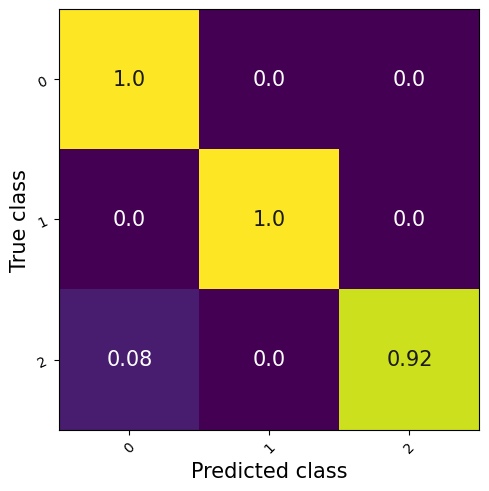

tensor([[1764,    0,    1],
        [   0,   14,    0],
        [   1,    0,   12]])
Macro F1-Score: 0.9742 ✨
perclass_f1scores: tensor([0.9994, 1.0000, 0.9231])
perclass_precision: tensor([0.9994, 1.0000, 0.9231])
perclass_recall: tensor([0.9994, 1.0000, 0.9231])
MAE overall: 1.3704 ✨
MAE per_class: {1: np.float64(1.2142857142857142), 2: np.float64(1.5384615384615385)} ✨
 === Currently Evaluating curr_test_idx: 10 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelgroun

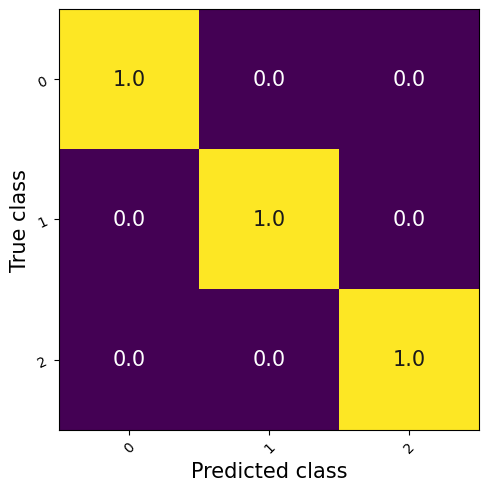

tensor([[2282,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4091 ✨
MAE per_class: {1: np.float64(0.6363636363636364), 2: np.float64(0.18181818181818182)} ✨
 === Currently Evaluating curr_test_idx: 11 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_

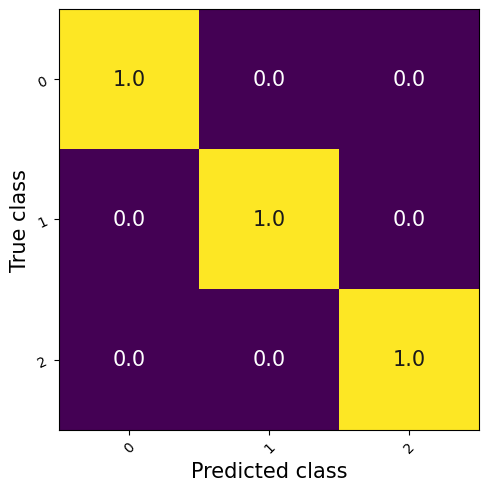

tensor([[2026,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3182 ✨
MAE per_class: {1: np.float64(0.36363636363636365), 2: np.float64(0.2727272727272727)} ✨
 === Currently Evaluating curr_test_idx: 12 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_

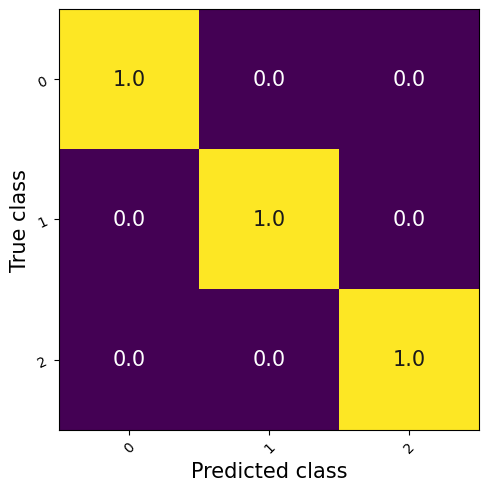

tensor([[2025,    0,    1],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9998, 1.0000, 0.9565])
perclass_precision: tensor([1.0000, 1.0000, 0.9167])
perclass_recall: tensor([0.9995, 1.0000, 1.0000])
MAE overall: 0.5455 ✨
MAE per_class: {1: np.float64(0.6363636363636364), 2: np.float64(0.45454545454545453)} ✨
 === Currently Evaluating curr_test_idx: 13 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelgrou

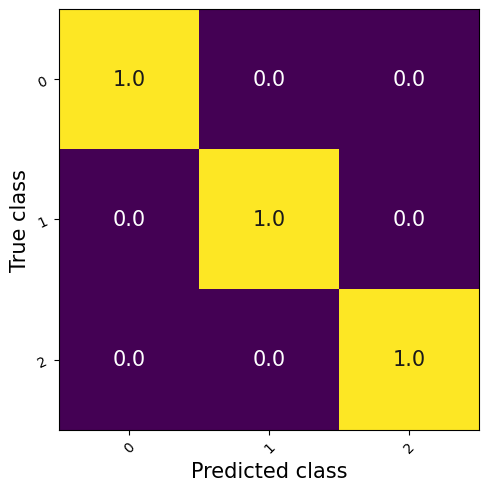

tensor([[2794,    0,    1],
        [   0,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9998, 1.0000, 0.9565])
perclass_precision: tensor([1.0000, 1.0000, 0.9167])
perclass_recall: tensor([0.9996, 1.0000, 1.0000])
MAE overall: 0.5714 ✨
MAE per_class: {1: np.float64(0.4), 2: np.float64(0.7272727272727273)} ✨
 === Currently Evaluating curr_test_idx: 14 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_02

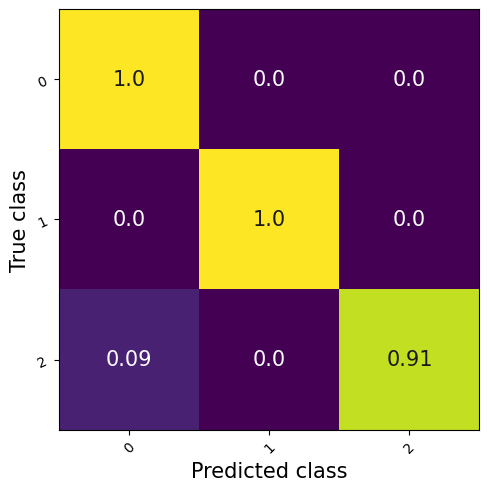

tensor([[2025,    0,    1],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9695 ✨
perclass_f1scores: tensor([0.9995, 1.0000, 0.9091])
perclass_precision: tensor([0.9995, 1.0000, 0.9091])
perclass_recall: tensor([0.9995, 1.0000, 0.9091])
MAE overall: 0.4091 ✨
MAE per_class: {1: np.float64(0.36363636363636365), 2: np.float64(0.45454545454545453)} ✨
 === Currently Evaluating curr_test_idx: 15 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelgro

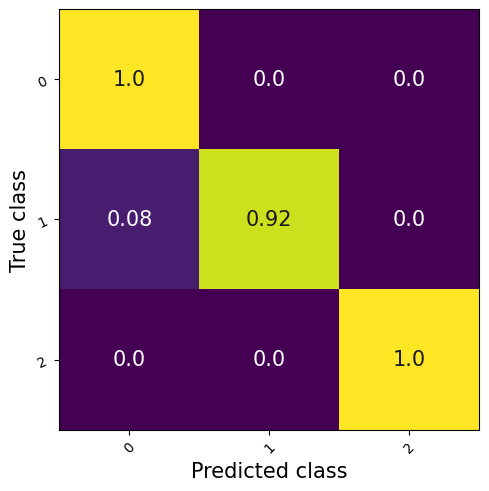

tensor([[2531,    1,    1],
        [   1,   12,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9627 ✨
perclass_f1scores: tensor([0.9994, 0.9231, 0.9655])
perclass_precision: tensor([0.9996, 0.9231, 0.9333])
perclass_recall: tensor([0.9992, 0.9231, 1.0000])
MAE overall: 0.6154 ✨
MAE per_class: {1: np.float64(0.9166666666666666), 2: np.float64(0.35714285714285715)} ✨
 === Currently Evaluating curr_test_idx: 16 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelgrou

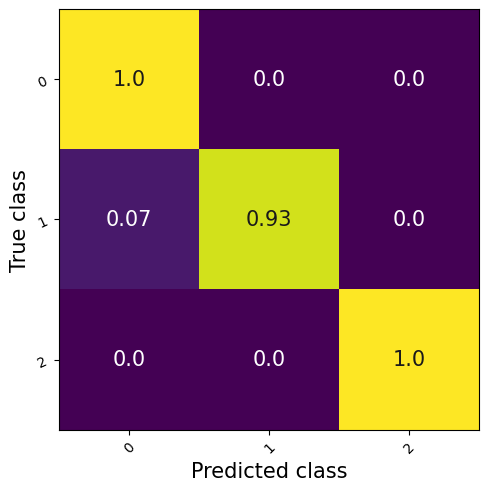

tensor([[2274,    0,    1],
        [   1,   14,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9769 ✨
perclass_f1scores: tensor([0.9996, 0.9655, 0.9655])
perclass_precision: tensor([0.9996, 1.0000, 0.9333])
perclass_recall: tensor([0.9996, 0.9333, 1.0000])
MAE overall: 0.4643 ✨
MAE per_class: {1: np.float64(0.8571428571428571), 2: np.float64(0.07142857142857142)} ✨
 === Currently Evaluating curr_test_idx: 17 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelgrou

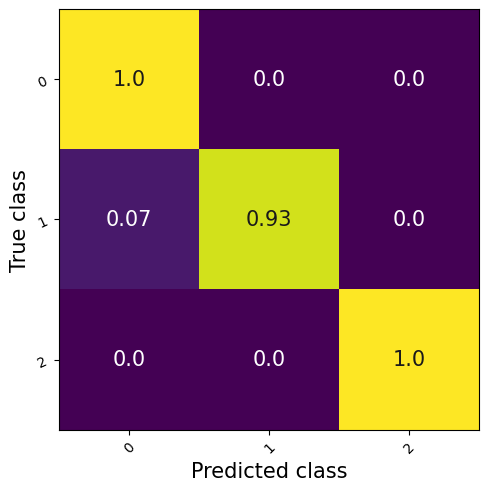

tensor([[2529,    0,    1],
        [   1,   14,    0],
        [   0,    0,   15]])
Macro F1-Score: 0.9776 ✨
perclass_f1scores: tensor([0.9996, 0.9655, 0.9677])
perclass_precision: tensor([0.9996, 1.0000, 0.9375])
perclass_recall: tensor([0.9996, 0.9333, 1.0000])
MAE overall: 0.5172 ✨
MAE per_class: {1: np.float64(0.7857142857142857), 2: np.float64(0.26666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 18 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelgrou

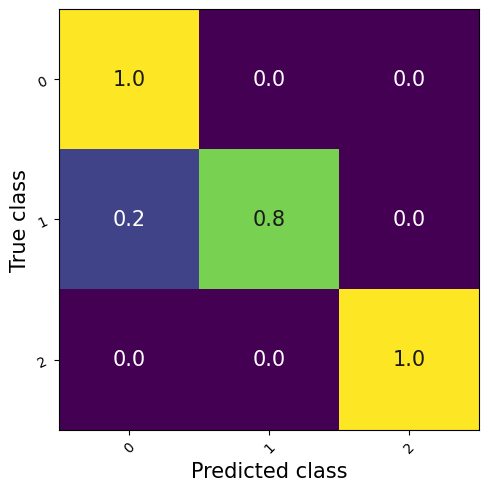

tensor([[2273,    0,    3],
        [   3,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9280 ✨
perclass_f1scores: tensor([0.9987, 0.8889, 0.8966])
perclass_precision: tensor([0.9987, 1.0000, 0.8125])
perclass_recall: tensor([0.9987, 0.8000, 1.0000])
MAE overall: 0.6000 ✨
MAE per_class: {1: np.float64(0.8333333333333334), 2: np.float64(0.38461538461538464)} ✨
 === Currently Evaluating curr_test_idx: 19 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelgrou

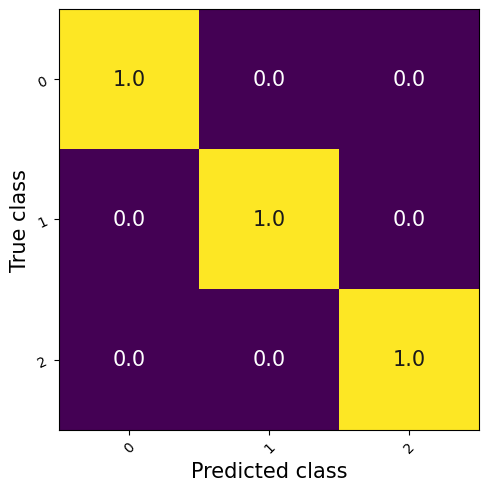

tensor([[2276,    0,    0],
        [   0,   15,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6429 ✨
MAE per_class: {1: np.float64(0.8), 2: np.float64(0.46153846153846156)} ✨
 === Currently Evaluating curr_test_idx: 20 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
crop

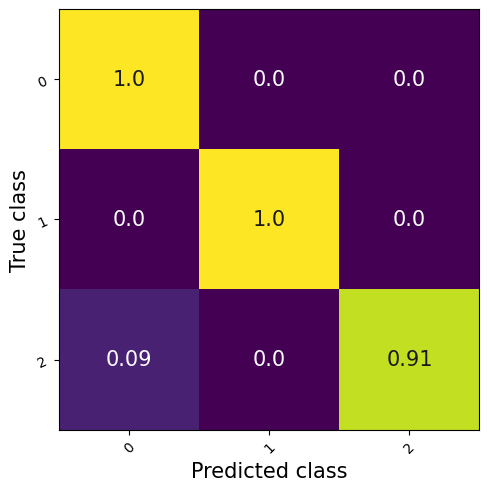

tensor([[2026,    0,    1],
        [   0,   10,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9695 ✨
perclass_f1scores: tensor([0.9995, 1.0000, 0.9091])
perclass_precision: tensor([0.9995, 1.0000, 0.9091])
perclass_recall: tensor([0.9995, 1.0000, 0.9091])
MAE overall: 0.7619 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.5454545454545454)} ✨
 === Currently Evaluating curr_test_idx: 21 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_

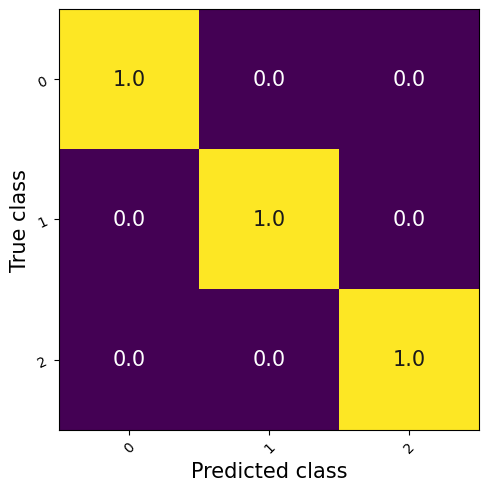

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6364 ✨
MAE per_class: {1: np.float64(1.1818181818181819), 2: np.float64(0.09090909090909091)} ✨
 === Currently Evaluating curr_test_idx: 22 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expan

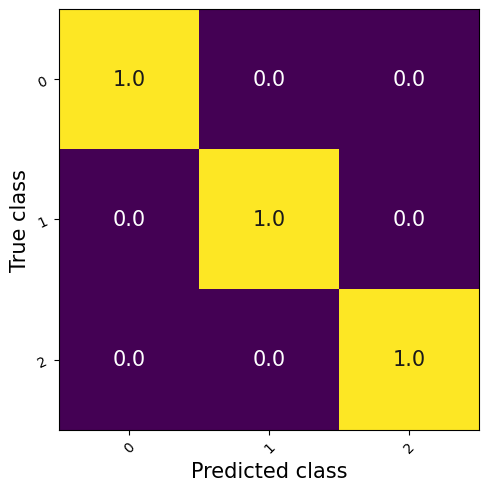

tensor([[1513,    0,    1],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9565])
perclass_precision: tensor([1.0000, 1.0000, 0.9167])
perclass_recall: tensor([0.9993, 1.0000, 1.0000])
MAE overall: 0.5909 ✨
MAE per_class: {1: np.float64(1.1818181818181819), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 23 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_

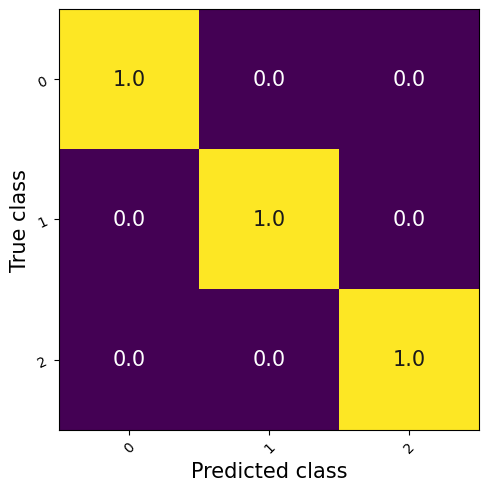

tensor([[1513,    1,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 0.9565, 1.0000])
perclass_precision: tensor([1.0000, 0.9167, 1.0000])
perclass_recall: tensor([0.9993, 1.0000, 1.0000])
MAE overall: 0.5455 ✨
MAE per_class: {1: np.float64(1.0909090909090908), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 24 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_ccw_normal_

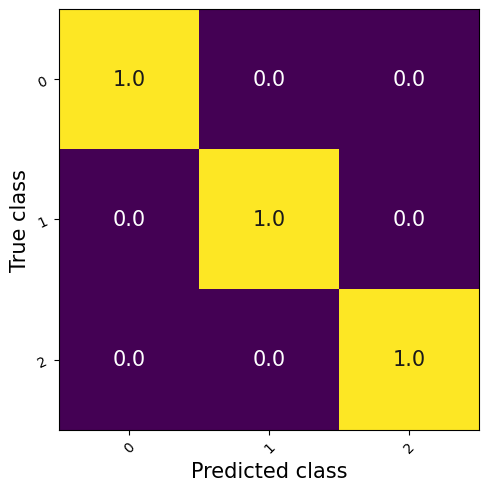

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5455 ✨
MAE per_class: {1: np.float64(1.0909090909090908), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 25 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
croppe

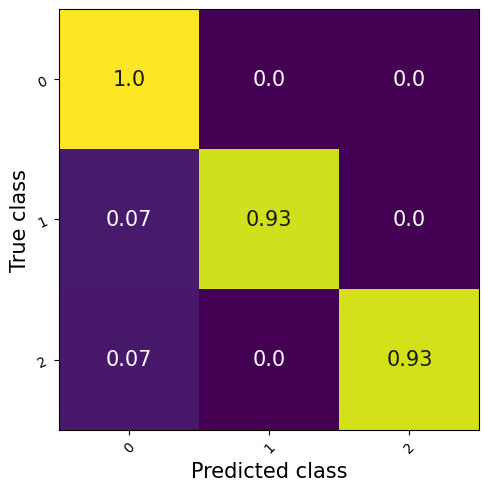

tensor([[2528,    0,    3],
        [   1,   13,    0],
        [   1,    0,   14]])
Macro F1-Score: 0.9457 ✨
perclass_f1scores: tensor([0.9990, 0.9630, 0.8750])
perclass_precision: tensor([0.9992, 1.0000, 0.8235])
perclass_recall: tensor([0.9988, 0.9286, 0.9333])
MAE overall: 0.7143 ✨
MAE per_class: {1: np.float64(1.0769230769230769), 2: np.float64(0.4)} ✨
 === Currently Evaluating curr_test_idx: 26 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_0

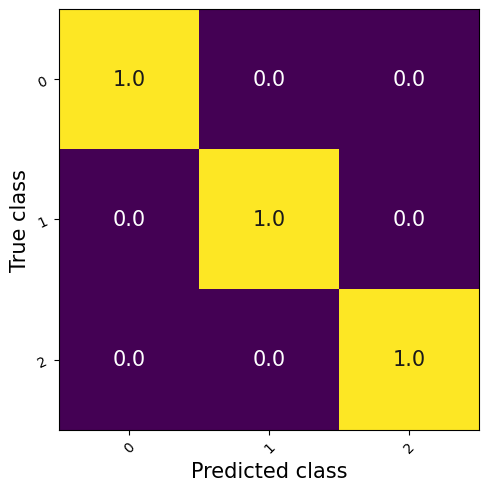

tensor([[1765,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5556 ✨
MAE per_class: {1: np.float64(0.9285714285714286), 2: np.float64(0.15384615384615385)} ✨
 === Currently Evaluating curr_test_idx: 27 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand

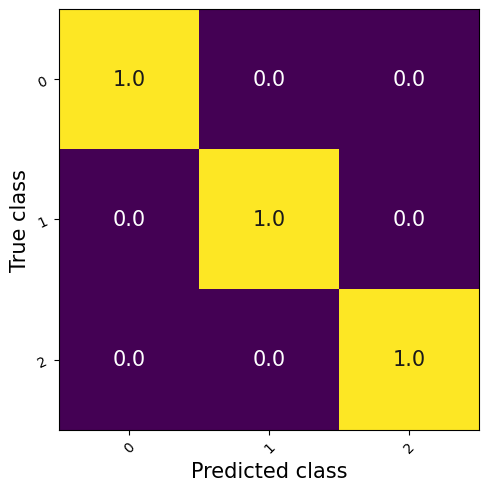

tensor([[1764,    1,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9884 ✨
perclass_f1scores: tensor([0.9997, 0.9655, 1.0000])
perclass_precision: tensor([1.0000, 0.9333, 1.0000])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.5926 ✨
MAE per_class: {1: np.float64(1.1428571428571428), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 28 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_0

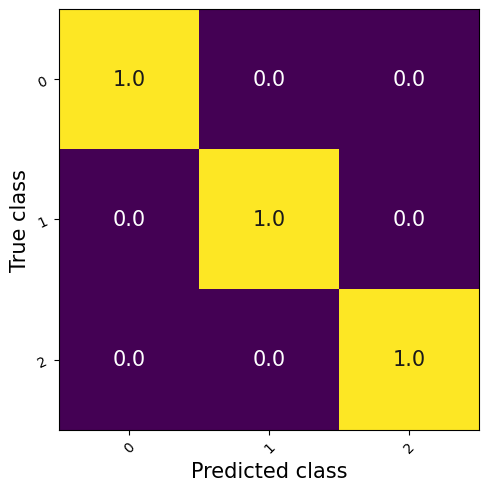

tensor([[1764,    1,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9884 ✨
perclass_f1scores: tensor([0.9997, 0.9655, 1.0000])
perclass_precision: tensor([1.0000, 0.9333, 1.0000])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.4444 ✨
MAE per_class: {1: np.float64(0.8571428571428571), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 29 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB08/10_21_2018/levelground/imu/levelground_cw_normal_0

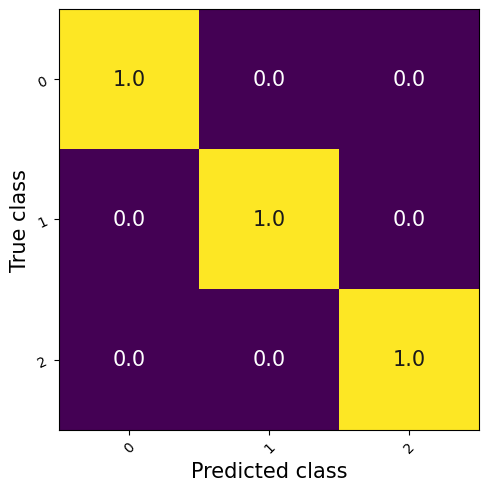

tensor([[1765,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5185 ✨
MAE per_class: {1: np.float64(0.9285714285714286), 2: np.float64(0.07692307692307693)} ✨
 === Currently Evaluating curr_test_idx: 30 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expan

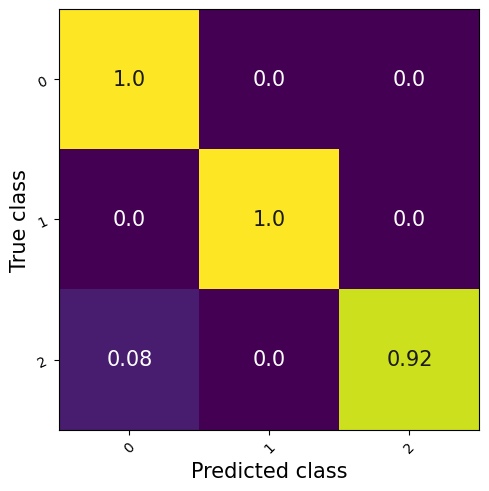

tensor([[2277,    1,    1],
        [   0,   12,    0],
        [   1,    0,   12]])
Macro F1-Score: 0.9608 ✨
perclass_f1scores: tensor([0.9993, 0.9600, 0.9231])
perclass_precision: tensor([0.9996, 0.9231, 0.9231])
perclass_recall: tensor([0.9991, 1.0000, 0.9231])
MAE overall: 0.7600 ✨
MAE per_class: {1: np.float64(0.3333333333333333), 2: np.float64(1.1538461538461537)} ✨
 === Currently Evaluating curr_test_idx: 31 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelgro

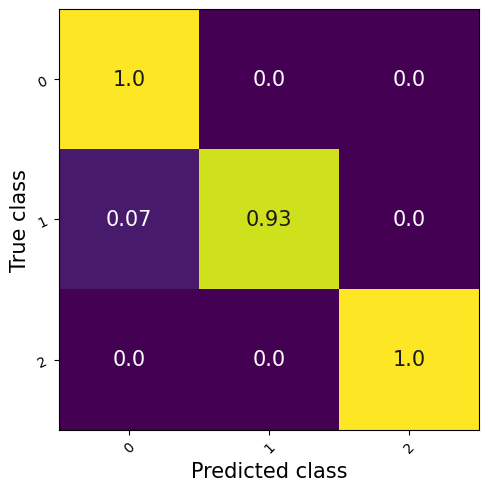

tensor([[2020,    0,    1],
        [   1,   13,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9751 ✨
perclass_f1scores: tensor([0.9995, 0.9630, 0.9630])
perclass_precision: tensor([0.9995, 1.0000, 0.9286])
perclass_recall: tensor([0.9995, 0.9286, 1.0000])
MAE overall: 0.6154 ✨
MAE per_class: {1: np.float64(0.6153846153846154), 2: np.float64(0.6153846153846154)} ✨
 === Currently Evaluating curr_test_idx: 32 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelgro

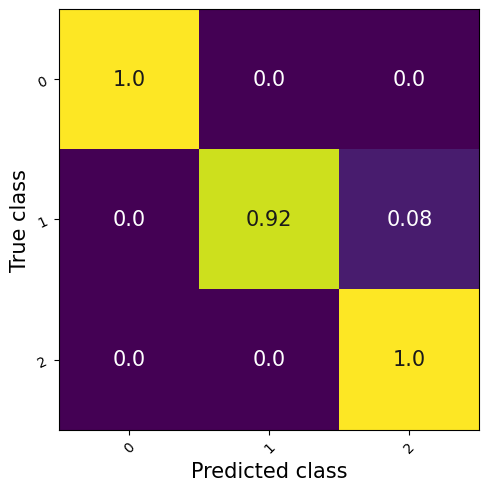

tensor([[1766,    0,    0],
        [   0,   12,    1],
        [   0,    0,   13]])
Macro F1-Score: 0.9743 ✨
perclass_f1scores: tensor([1.0000, 0.9600, 0.9630])
perclass_precision: tensor([1.0000, 1.0000, 0.9286])
perclass_recall: tensor([1.0000, 0.9231, 1.0000])
MAE overall: 0.6000 ✨
MAE per_class: {1: np.float64(0.5), 2: np.float64(0.6923076923076923)} ✨
 === Currently Evaluating curr_test_idx: 33 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_

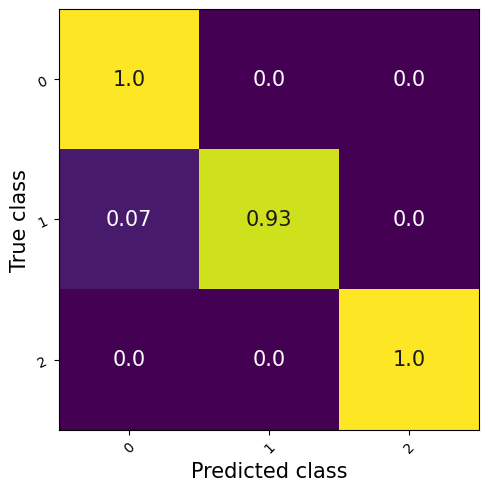

tensor([[1765,    0,    1],
        [   1,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9741 ✨
perclass_f1scores: tensor([0.9994, 0.9630, 0.9600])
perclass_precision: tensor([0.9994, 1.0000, 0.9231])
perclass_recall: tensor([0.9994, 0.9286, 1.0000])
MAE overall: 0.8000 ✨
MAE per_class: {1: np.float64(0.6923076923076923), 2: np.float64(0.9166666666666666)} ✨
 === Currently Evaluating curr_test_idx: 34 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelgro

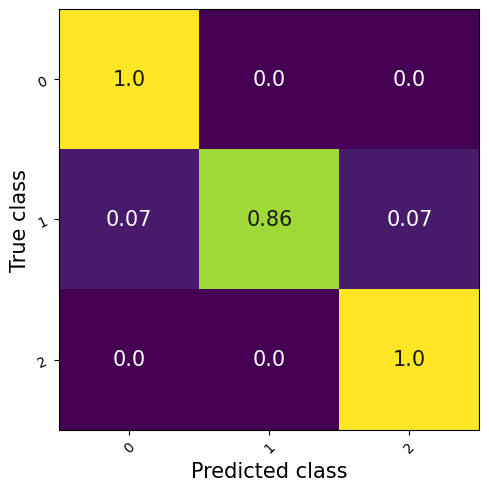

tensor([[2020,    0,    1],
        [   1,   12,    1],
        [   0,    0,   13]])
Macro F1-Score: 0.9504 ✨
perclass_f1scores: tensor([0.9995, 0.9231, 0.9286])
perclass_precision: tensor([0.9995, 1.0000, 0.8667])
perclass_recall: tensor([0.9995, 0.8571, 1.0000])
MAE overall: 0.8000 ✨
MAE per_class: {1: np.float64(0.8333333333333334), 2: np.float64(0.7692307692307693)} ✨
 === Currently Evaluating curr_test_idx: 35 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelgro

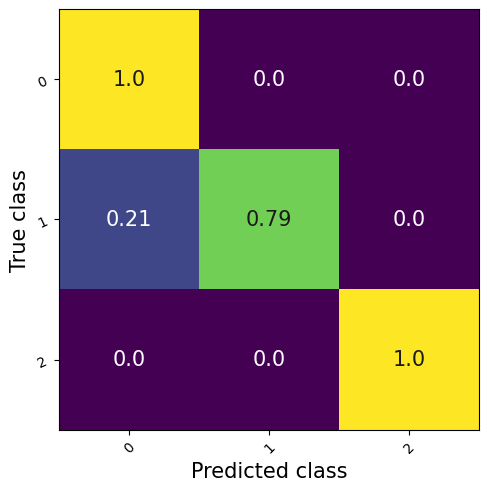

tensor([[1761,    0,    3],
        [   3,   11,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9272 ✨
perclass_f1scores: tensor([0.9983, 0.8800, 0.9032])
perclass_precision: tensor([0.9983, 1.0000, 0.8235])
perclass_recall: tensor([0.9983, 0.7857, 1.0000])
MAE overall: 0.7600 ✨
MAE per_class: {1: np.float64(0.8181818181818182), 2: np.float64(0.7142857142857143)} ✨
 === Currently Evaluating curr_test_idx: 36 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelgro

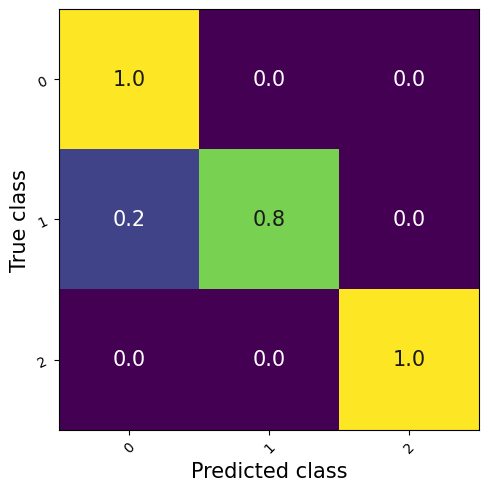

tensor([[2272,    0,    3],
        [   3,   12,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9303 ✨
perclass_f1scores: tensor([0.9987, 0.8889, 0.9032])
perclass_precision: tensor([0.9987, 1.0000, 0.8235])
perclass_recall: tensor([0.9987, 0.8000, 1.0000])
MAE overall: 0.6538 ✨
MAE per_class: {1: np.float64(0.6666666666666666), 2: np.float64(0.6428571428571429)} ✨
 === Currently Evaluating curr_test_idx: 37 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelgro

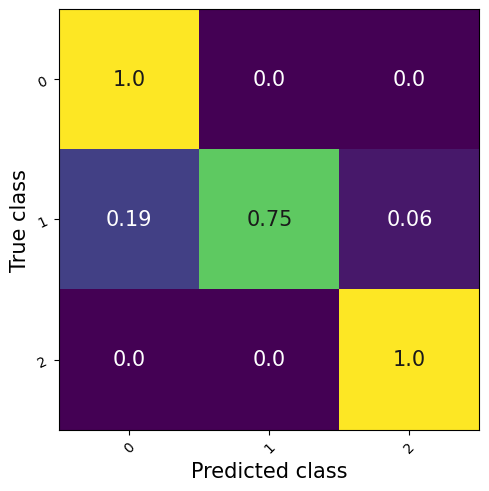

tensor([[2013,    0,    3],
        [   3,   12,    1],
        [   0,    0,   16]])
Macro F1-Score: 0.9148 ✨
perclass_f1scores: tensor([0.9985, 0.8571, 0.8889])
perclass_precision: tensor([0.9985, 1.0000, 0.8000])
perclass_recall: tensor([0.9985, 0.7500, 1.0000])
MAE overall: 1.0000 ✨
MAE per_class: {1: np.float64(1.1666666666666667), 2: np.float64(0.875)} ✨
 === Currently Evaluating curr_test_idx: 38 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal

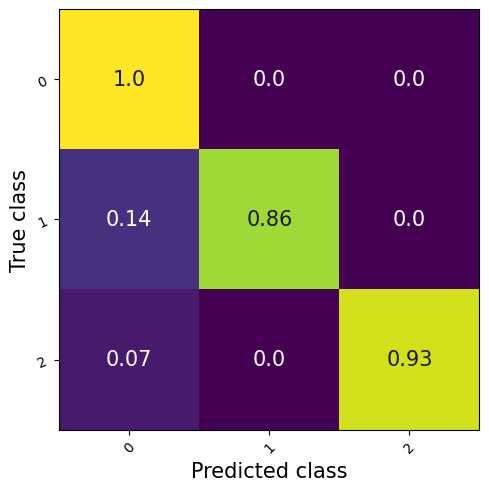

tensor([[2784,    1,    3],
        [   2,   12,    0],
        [   1,    0,   13]])
Macro F1-Score: 0.9181 ✨
perclass_f1scores: tensor([0.9987, 0.8889, 0.8667])
perclass_precision: tensor([0.9989, 0.9231, 0.8125])
perclass_recall: tensor([0.9986, 0.8571, 0.9286])
MAE overall: 0.8462 ✨
MAE per_class: {1: np.float64(0.75), 2: np.float64(0.9285714285714286)} ✨
 === Currently Evaluating curr_test_idx: 39 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_ccw_normal

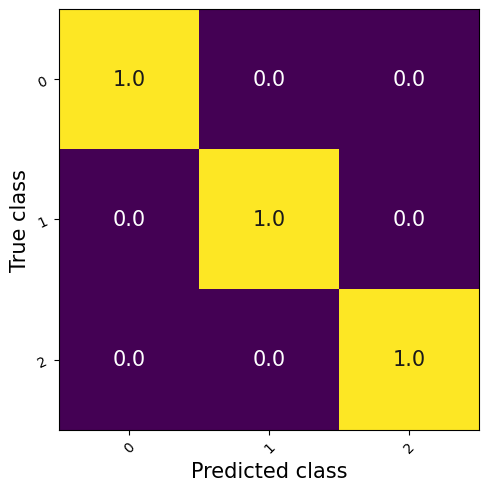

tensor([[2537,    2,    0],
        [   0,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9696 ✨
perclass_f1scores: tensor([0.9996, 0.9091, 1.0000])
perclass_precision: tensor([1.0000, 0.8333, 1.0000])
perclass_recall: tensor([0.9992, 1.0000, 1.0000])
MAE overall: 0.6667 ✨
MAE per_class: {1: np.float64(1.1), 2: np.float64(0.2727272727272727)} ✨
 === Currently Evaluating curr_test_idx: 40 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_ccw_normal_

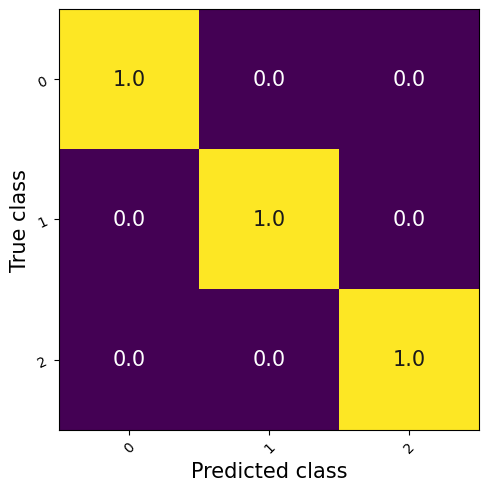

tensor([[1515,    0,    0],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3810 ✨
MAE per_class: {1: np.float64(0.7272727272727273), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 41 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropp

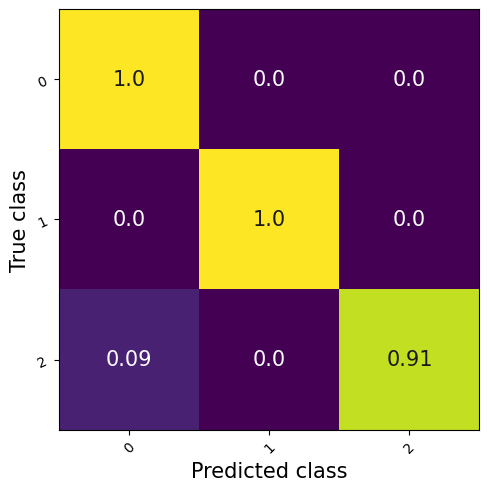

tensor([[1769,    0,    1],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9695 ✨
perclass_f1scores: tensor([0.9994, 1.0000, 0.9091])
perclass_precision: tensor([0.9994, 1.0000, 0.9091])
perclass_recall: tensor([0.9994, 1.0000, 0.9091])
MAE overall: 0.5455 ✨
MAE per_class: {1: np.float64(0.7272727272727273), 2: np.float64(0.36363636363636365)} ✨
 === Currently Evaluating curr_test_idx: 42 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelgr

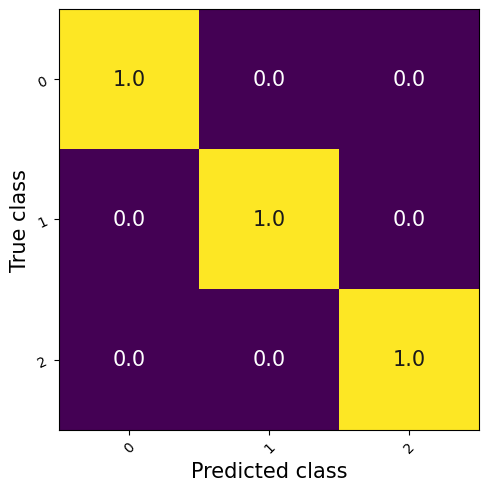

tensor([[1515,    0,    0],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4762 ✨
MAE per_class: {1: np.float64(0.9090909090909091), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 43 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropp

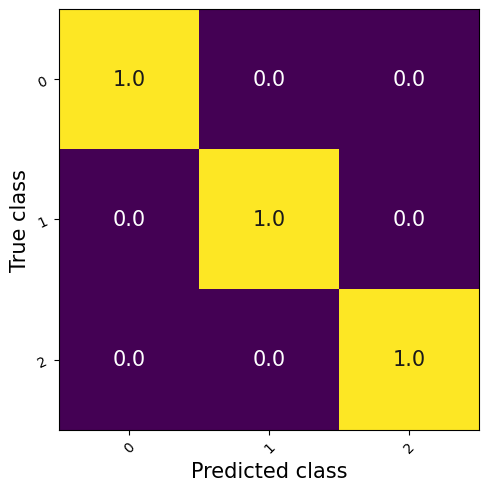

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4091 ✨
MAE per_class: {1: np.float64(0.8181818181818182), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 44 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
croppe

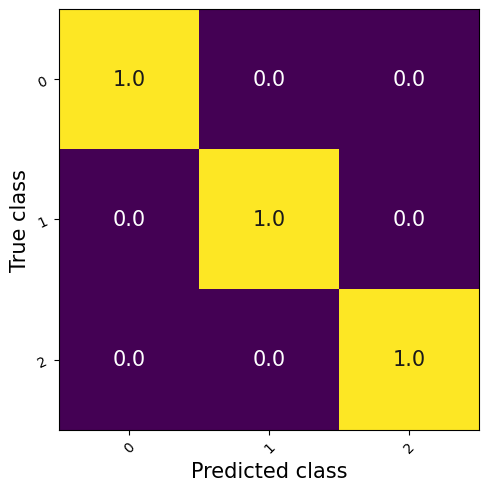

tensor([[2278,    1,    0],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9866 ✨
perclass_f1scores: tensor([0.9998, 0.9600, 1.0000])
perclass_precision: tensor([1.0000, 0.9231, 1.0000])
perclass_recall: tensor([0.9996, 1.0000, 1.0000])
MAE overall: 0.7200 ✨
MAE per_class: {1: np.float64(1.1666666666666667), 2: np.float64(0.3076923076923077)} ✨
 === Currently Evaluating curr_test_idx: 45 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelgro

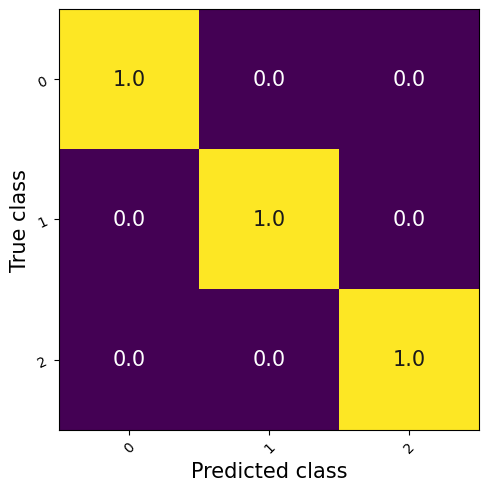

tensor([[1765,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.8889 ✨
MAE per_class: {1: np.float64(1.4285714285714286), 2: np.float64(0.3076923076923077)} ✨
 === Currently Evaluating curr_test_idx: 46 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_

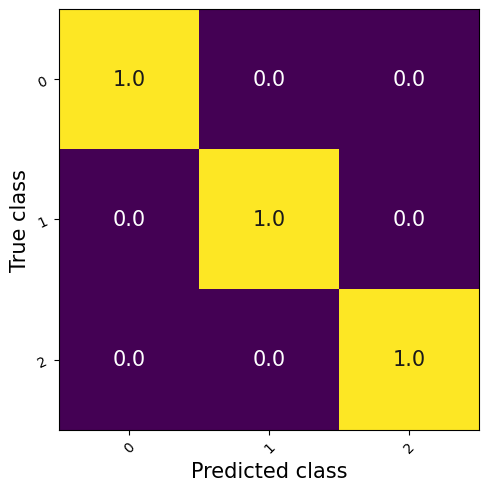

tensor([[1766,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6154 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.16666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 47 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropp

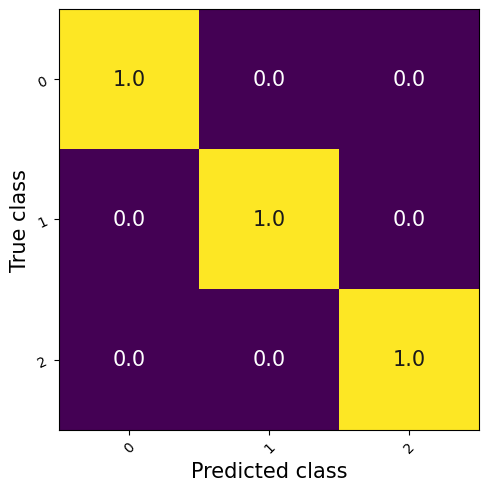

tensor([[1766,    0,    0],
        [   0,   13,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5385 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.07692307692307693)} ✨
 === Currently Evaluating curr_test_idx: 48 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB10/10_28_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropp

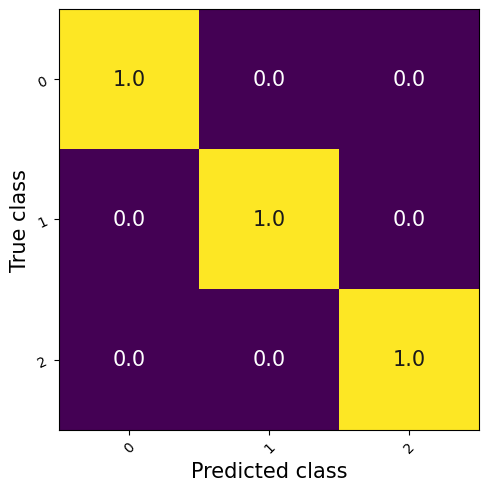

tensor([[1766,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.7692 ✨
MAE per_class: {1: np.float64(1.2857142857142858), 2: np.float64(0.16666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 49 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expan

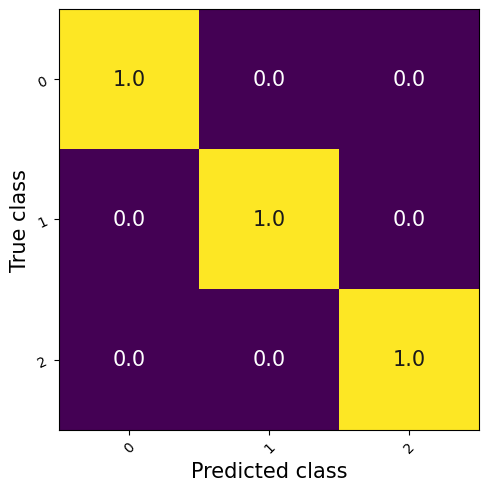

tensor([[1767,    2,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9720 ✨
perclass_f1scores: tensor([0.9994, 0.9167, 1.0000])
perclass_precision: tensor([1.0000, 0.8462, 1.0000])
perclass_recall: tensor([0.9989, 1.0000, 1.0000])
MAE overall: 1.2174 ✨
MAE per_class: {1: np.float64(1.0909090909090908), 2: np.float64(1.3333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 50 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelgro

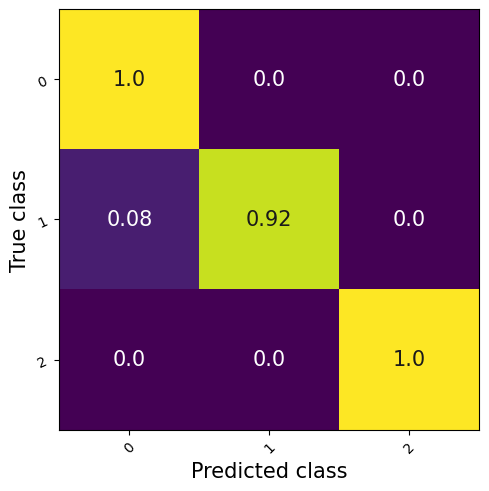

tensor([[1512,    1,    1],
        [   1,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 0.9560 ✨
perclass_f1scores: tensor([0.9990, 0.9167, 0.9524])
perclass_precision: tensor([0.9993, 0.9167, 0.9091])
perclass_recall: tensor([0.9987, 0.9167, 1.0000])
MAE overall: 1.1429 ✨
MAE per_class: {1: np.float64(1.1818181818181819), 2: np.float64(1.1)} ✨
 === Currently Evaluating curr_test_idx: 51 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_

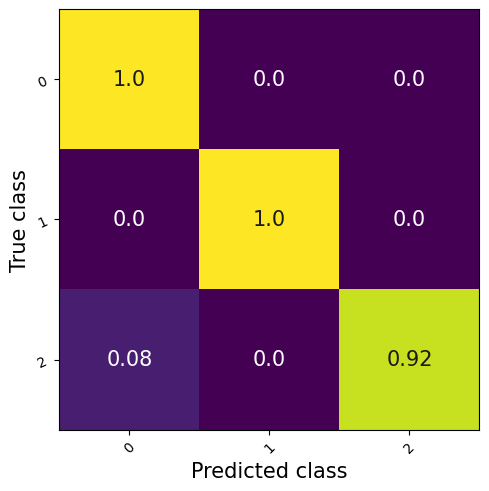

tensor([[1511,    0,    1],
        [   0,   12,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9720 ✨
perclass_f1scores: tensor([0.9993, 1.0000, 0.9167])
perclass_precision: tensor([0.9993, 1.0000, 0.9167])
perclass_recall: tensor([0.9993, 1.0000, 0.9167])
MAE overall: 1.2500 ✨
MAE per_class: {1: np.float64(1.0833333333333333), 2: np.float64(1.4166666666666667)} ✨
 === Currently Evaluating curr_test_idx: 52 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelgro

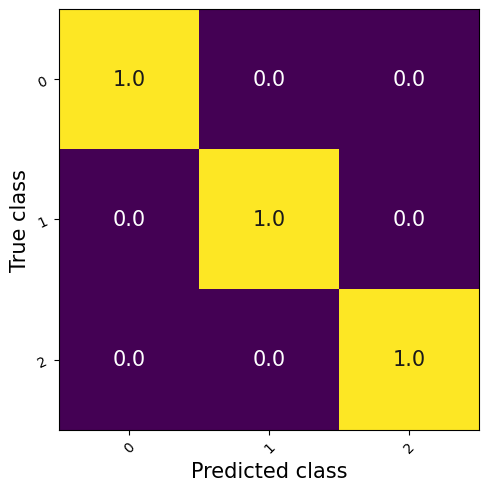

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.9091 ✨
MAE per_class: {1: np.float64(0.5454545454545454), 2: np.float64(1.2727272727272727)} ✨
 === Currently Evaluating curr_test_idx: 53 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand

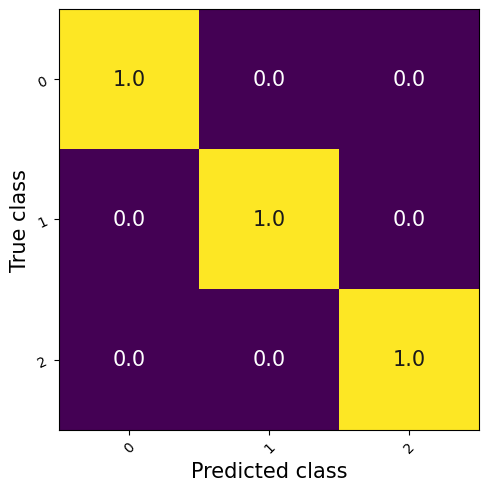

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.8182 ✨
MAE per_class: {1: np.float64(0.7272727272727273), 2: np.float64(0.9090909090909091)} ✨
 === Currently Evaluating curr_test_idx: 54 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_06.npy
self.expand

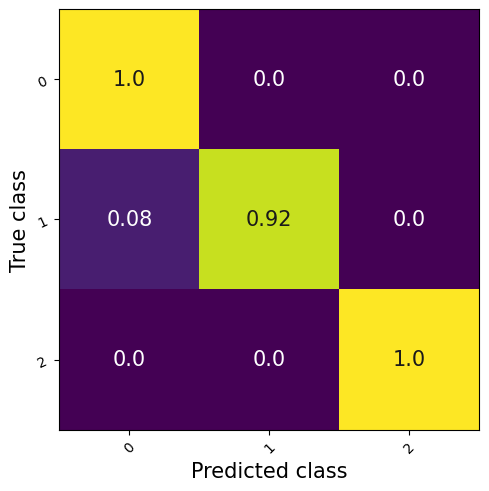

tensor([[1513,    0,    1],
        [   1,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 0.9694 ✨
perclass_f1scores: tensor([0.9993, 0.9565, 0.9524])
perclass_precision: tensor([0.9993, 1.0000, 0.9091])
perclass_recall: tensor([0.9993, 0.9167, 1.0000])
MAE overall: 0.7619 ✨
MAE per_class: {1: np.float64(0.7272727272727273), 2: np.float64(0.8)} ✨
 === Currently Evaluating curr_test_idx: 55 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_

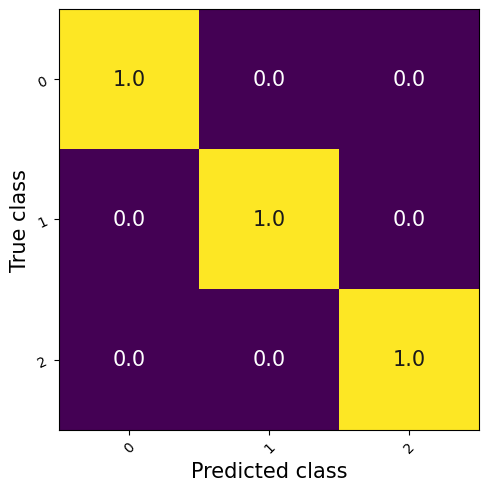

tensor([[1515,    0,    0],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.9048 ✨
MAE per_class: {1: np.float64(0.9090909090909091), 2: np.float64(0.9)} ✨
 === Currently Evaluating curr_test_idx: 56 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
croppe

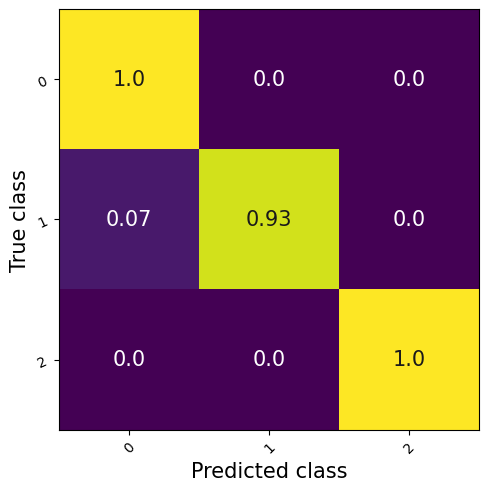

tensor([[1762,    1,    1],
        [   1,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9651 ✨
perclass_f1scores: tensor([0.9991, 0.9333, 0.9630])
perclass_precision: tensor([0.9994, 0.9333, 0.9286])
perclass_recall: tensor([0.9989, 0.9333, 1.0000])
MAE overall: 1.0741 ✨
MAE per_class: {1: np.float64(0.8571428571428571), 2: np.float64(1.3076923076923077)} ✨
 === Currently Evaluating curr_test_idx: 57 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelgro

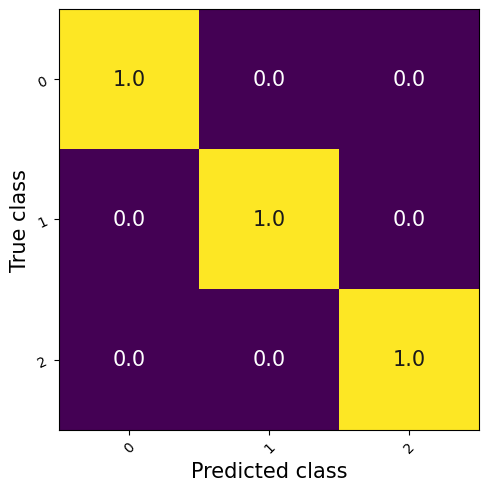

tensor([[1764,    0,    0],
        [   0,   14,    0],
        [   0,    0,   14]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.2143 ✨
MAE per_class: {1: np.float64(0.8571428571428571), 2: np.float64(1.5714285714285714)} ✨
 === Currently Evaluating curr_test_idx: 58 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_

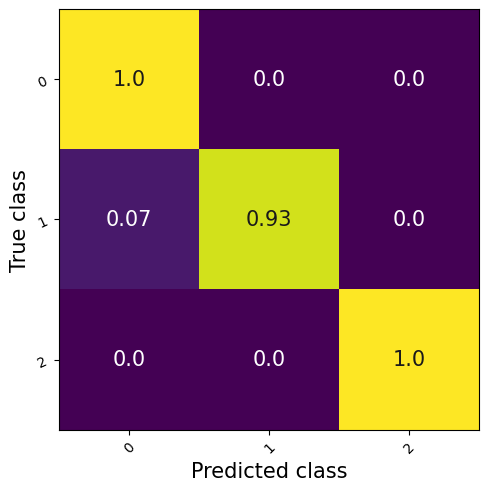

tensor([[1763,    0,    1],
        [   1,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9760 ✨
perclass_f1scores: tensor([0.9994, 0.9655, 0.9630])
perclass_precision: tensor([0.9994, 1.0000, 0.9286])
perclass_recall: tensor([0.9994, 0.9333, 1.0000])
MAE overall: 1.1852 ✨
MAE per_class: {1: np.float64(1.0714285714285714), 2: np.float64(1.3076923076923077)} ✨
 === Currently Evaluating curr_test_idx: 59 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelgro

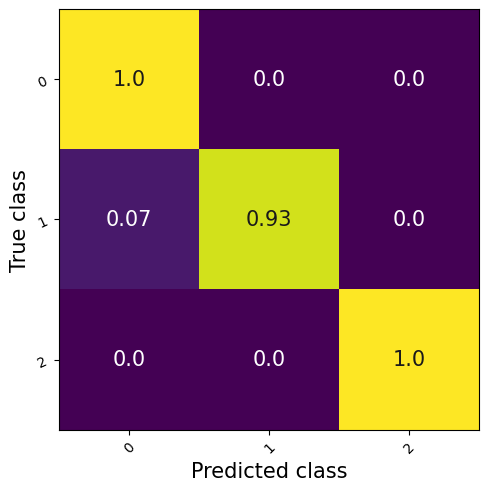

tensor([[2019,    0,    1],
        [   1,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9760 ✨
perclass_f1scores: tensor([0.9995, 0.9655, 0.9630])
perclass_precision: tensor([0.9995, 1.0000, 0.9286])
perclass_recall: tensor([0.9995, 0.9333, 1.0000])
MAE overall: 1.0000 ✨
MAE per_class: {1: np.float64(0.8571428571428571), 2: np.float64(1.1538461538461537)} ✨
 === Currently Evaluating curr_test_idx: 60 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelgro

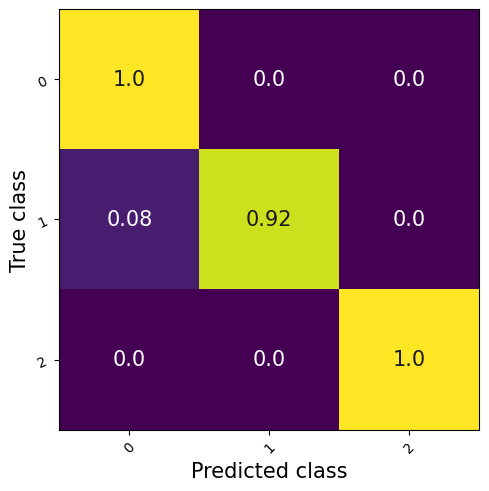

tensor([[2531,    1,    1],
        [   1,   12,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9627 ✨
perclass_f1scores: tensor([0.9994, 0.9231, 0.9655])
perclass_precision: tensor([0.9996, 0.9231, 0.9333])
perclass_recall: tensor([0.9992, 0.9231, 1.0000])
MAE overall: 1.2308 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(1.4285714285714286)} ✨
 === Currently Evaluating curr_test_idx: 61 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_

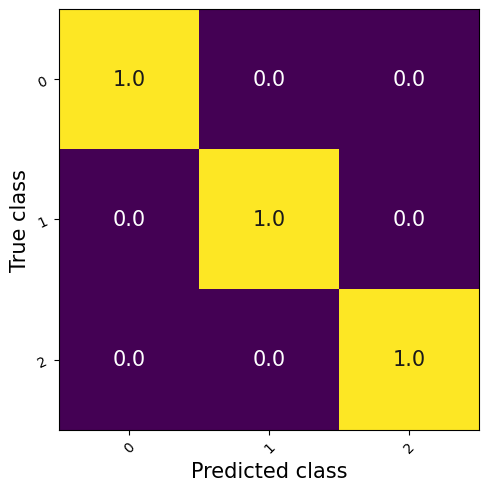

tensor([[1771,    0,    0],
        [   0,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.7619 ✨
MAE per_class: {1: np.float64(1.1), 2: np.float64(0.45454545454545453)} ✨
 === Currently Evaluating curr_test_idx: 62 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
crop

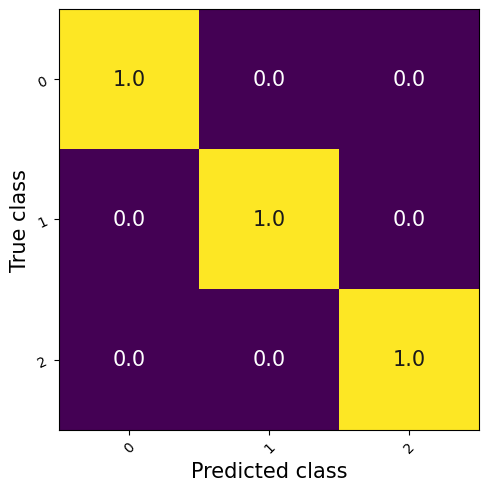

tensor([[1258,    0,    1],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 0.9840 ✨
perclass_f1scores: tensor([0.9996, 1.0000, 0.9524])
perclass_precision: tensor([1.0000, 1.0000, 0.9091])
perclass_recall: tensor([0.9992, 1.0000, 1.0000])
MAE overall: 0.6667 ✨
MAE per_class: {1: np.float64(1.2727272727272727), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 63 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_

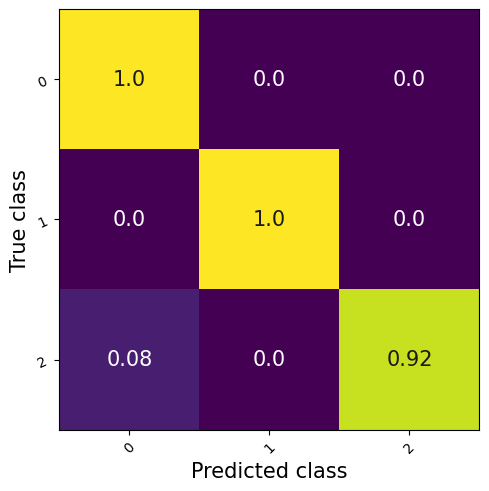

tensor([[1512,    0,    0],
        [   0,   12,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9565])
perclass_precision: tensor([0.9993, 1.0000, 1.0000])
perclass_recall: tensor([1.0000, 1.0000, 0.9167])
MAE overall: 0.5217 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 64 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.

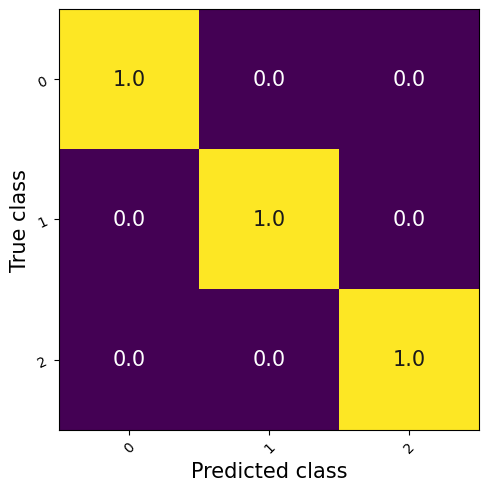

tensor([[1258,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6818 ✨
MAE per_class: {1: np.float64(1.0909090909090908), 2: np.float64(0.2727272727272727)} ✨
 === Currently Evaluating curr_test_idx: 65 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand

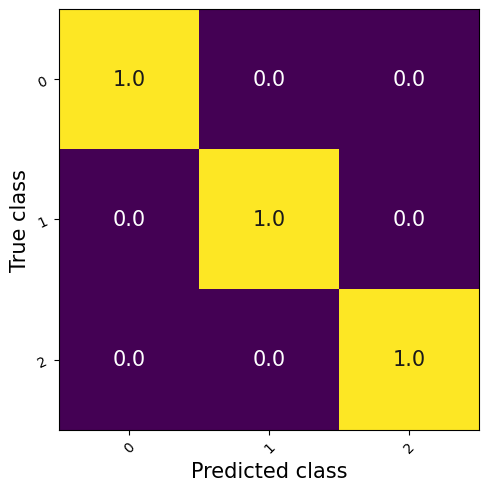

tensor([[1511,    0,    0],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5200 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.07692307692307693)} ✨
 === Currently Evaluating curr_test_idx: 66 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropp

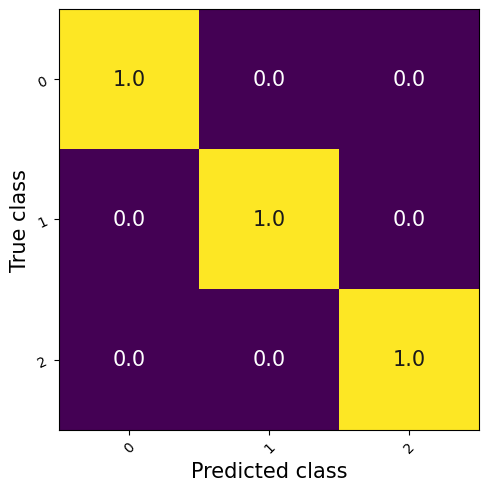

tensor([[2022,    0,    0],
        [   0,   12,    0],
        [   0,    0,   14]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6538 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.35714285714285715)} ✨
 === Currently Evaluating curr_test_idx: 67 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropp

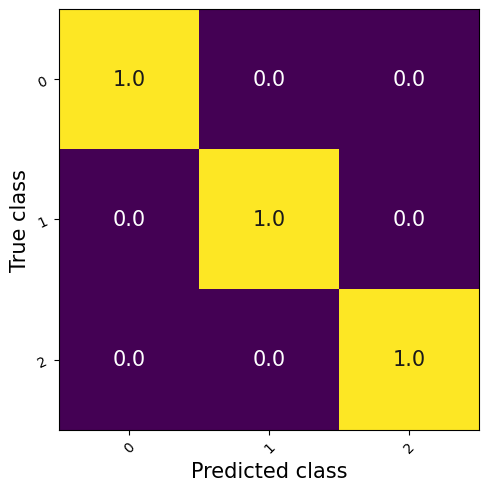

tensor([[1511,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4800 ✨
MAE per_class: {1: np.float64(0.8461538461538461), 2: np.float64(0.08333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 68 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand

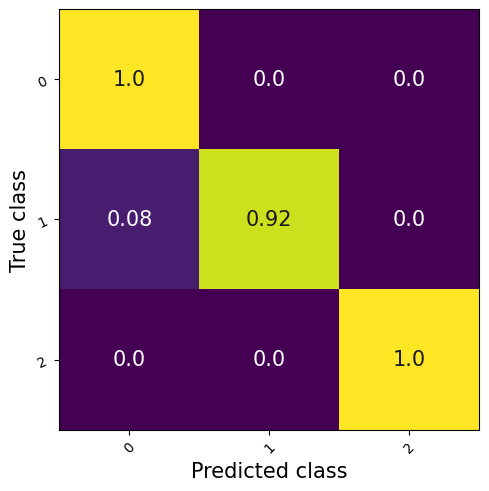

tensor([[1510,    0,    1],
        [   1,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9731 ✨
perclass_f1scores: tensor([0.9993, 0.9600, 0.9600])
perclass_precision: tensor([0.9993, 1.0000, 0.9231])
perclass_recall: tensor([0.9993, 0.9231, 1.0000])
MAE overall: 0.7083 ✨
MAE per_class: {1: np.float64(1.25), 2: np.float64(0.16666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 69 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal

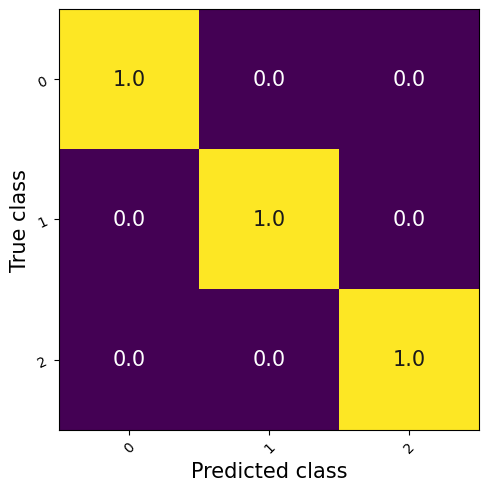

tensor([[1767,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5200 ✨
MAE per_class: {1: np.float64(0.8461538461538461), 2: np.float64(0.16666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 70 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand

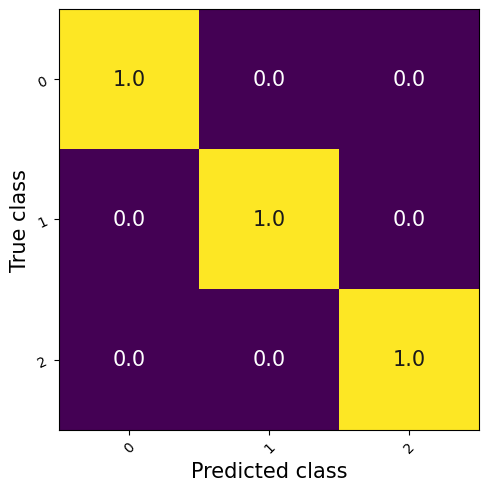

tensor([[2022,    0,    1],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9876 ✨
perclass_f1scores: tensor([0.9998, 1.0000, 0.9630])
perclass_precision: tensor([1.0000, 1.0000, 0.9286])
perclass_recall: tensor([0.9995, 1.0000, 1.0000])
MAE overall: 0.5200 ✨
MAE per_class: {1: np.float64(0.75), 2: np.float64(0.3076923076923077)} ✨
 === Currently Evaluating curr_test_idx: 71 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal_

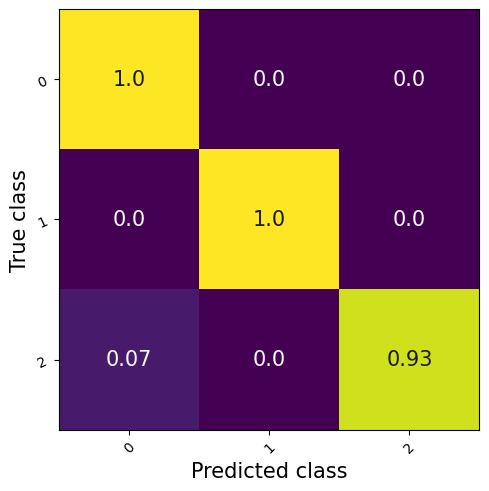

tensor([[2021,    0,    1],
        [   0,   12,    0],
        [   1,    0,   13]])
Macro F1-Score: 0.9760 ✨
perclass_f1scores: tensor([0.9995, 1.0000, 0.9286])
perclass_precision: tensor([0.9995, 1.0000, 0.9286])
perclass_recall: tensor([0.9995, 1.0000, 0.9286])
MAE overall: 0.7200 ✨
MAE per_class: {1: np.float64(1.25), 2: np.float64(0.23076923076923078)} ✨
 === Currently Evaluating curr_test_idx: 72 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB12/11_04_2018/levelground/imu/levelground_cw_normal

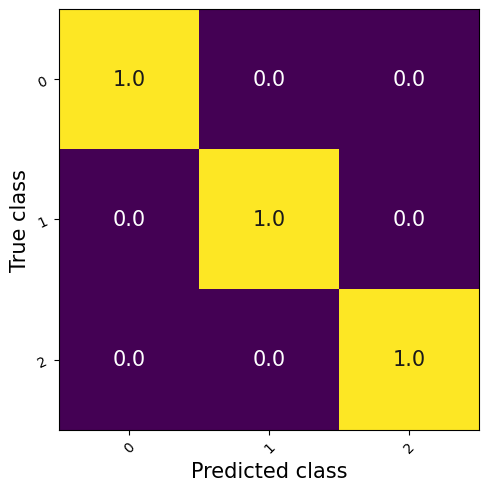

tensor([[1767,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6400 ✨
MAE per_class: {1: np.float64(1.1538461538461537), 2: np.float64(0.08333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 73 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expan

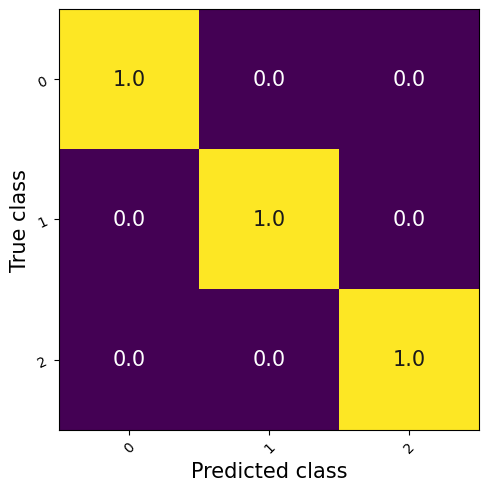

tensor([[2027,    0,    0],
        [   0,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4286 ✨
MAE per_class: {1: np.float64(0.6), 2: np.float64(0.2727272727272727)} ✨
 === Currently Evaluating curr_test_idx: 74 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropp

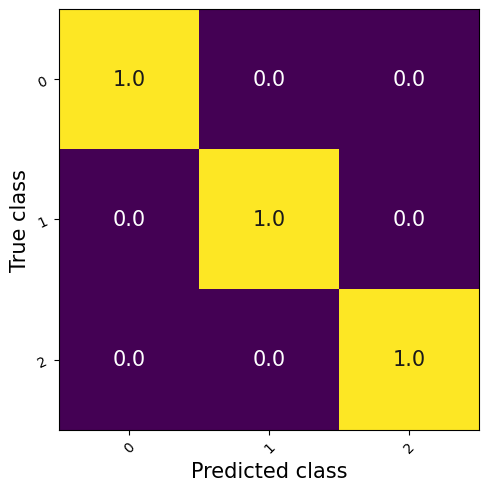

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4545 ✨
MAE per_class: {1: np.float64(0.9090909090909091), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 75 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropp

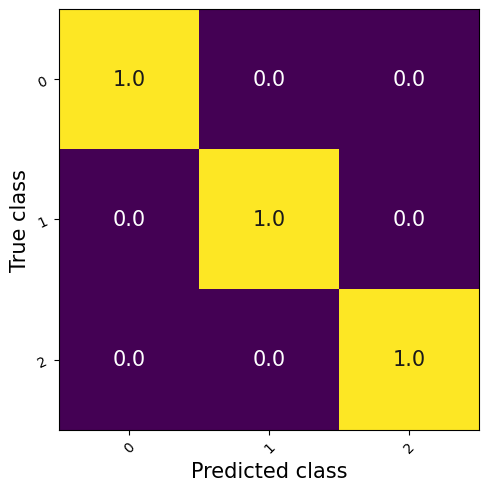

tensor([[1513,    1,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 0.9565, 1.0000])
perclass_precision: tensor([1.0000, 0.9167, 1.0000])
perclass_recall: tensor([0.9993, 1.0000, 1.0000])
MAE overall: 0.5000 ✨
MAE per_class: {1: np.float64(0.7272727272727273), 2: np.float64(0.2727272727272727)} ✨
 === Currently Evaluating curr_test_idx: 76 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelgro

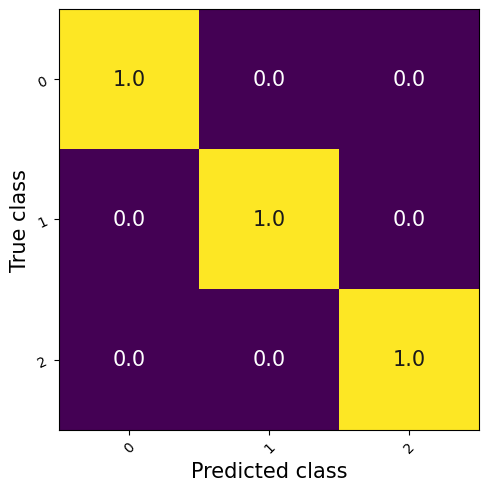

tensor([[1769,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1304 ✨
MAE per_class: {1: np.float64(0.2727272727272727), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 77 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropp

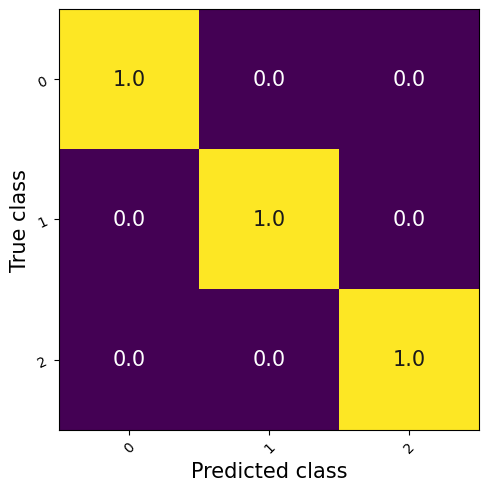

tensor([[1769,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3043 ✨
MAE per_class: {1: np.float64(0.5454545454545454), 2: np.float64(0.08333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 78 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand

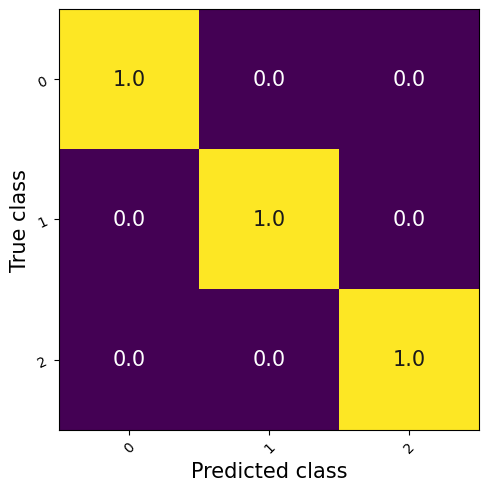

tensor([[1767,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4000 ✨
MAE per_class: {1: np.float64(0.5384615384615384), 2: np.float64(0.25)} ✨
 === Currently Evaluating curr_test_idx: 79 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropp

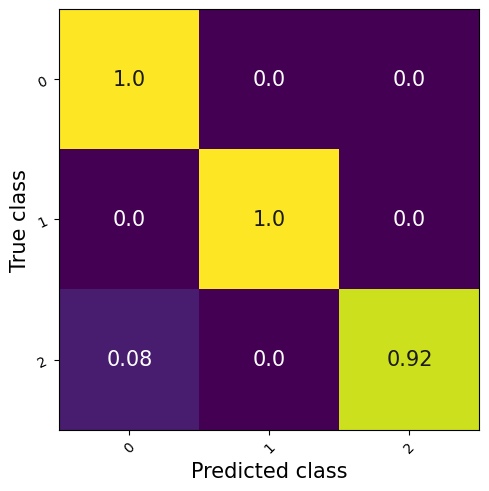

tensor([[2021,    1,    0],
        [   0,   13,    0],
        [   1,    0,   12]])
Macro F1-Score: 0.9742 ✨
perclass_f1scores: tensor([0.9995, 0.9630, 0.9600])
perclass_precision: tensor([0.9995, 0.9286, 1.0000])
perclass_recall: tensor([0.9995, 1.0000, 0.9231])
MAE overall: 0.2000 ✨
MAE per_class: {1: np.float64(0.38461538461538464), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 80 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelground_cw_normal_

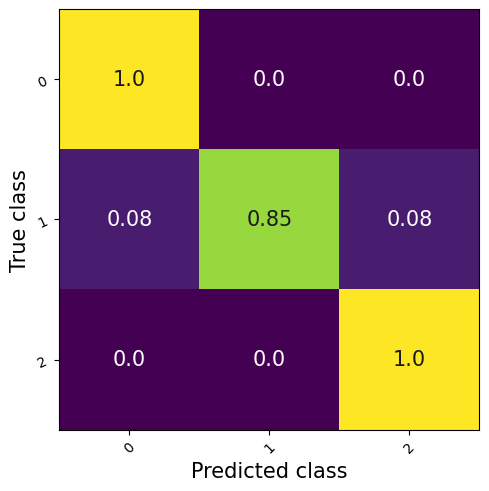

tensor([[2022,    0,    0],
        [   1,   11,    1],
        [   0,    0,   13]])
Macro F1-Score: 0.9598 ✨
perclass_f1scores: tensor([0.9998, 0.9167, 0.9630])
perclass_precision: tensor([0.9995, 1.0000, 0.9286])
perclass_recall: tensor([1.0000, 0.8462, 1.0000])
MAE overall: 0.2500 ✨
MAE per_class: {1: np.float64(0.36363636363636365), 2: np.float64(0.15384615384615385)} ✨
 === Currently Evaluating curr_test_idx: 81 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB13/11_04_2018/levelground/imu/levelg

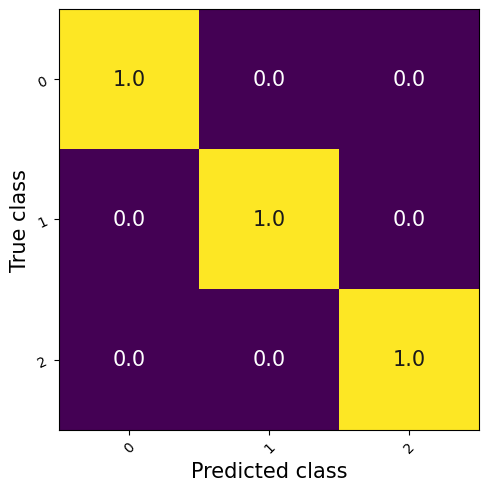

tensor([[2023,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.2000 ✨
MAE per_class: {1: np.float64(0.38461538461538464), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 82 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
crop

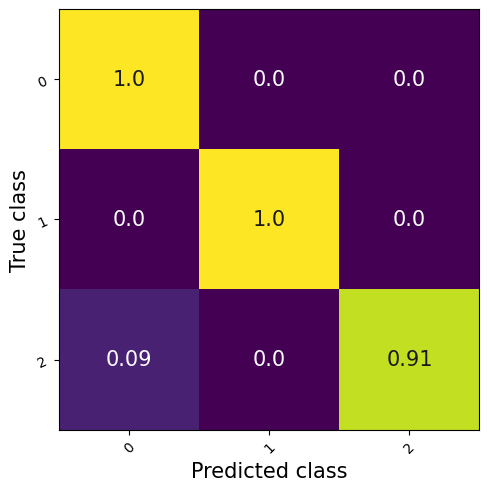

tensor([[1514,    0,    1],
        [   0,   10,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9695 ✨
perclass_f1scores: tensor([0.9993, 1.0000, 0.9091])
perclass_precision: tensor([0.9993, 1.0000, 0.9091])
perclass_recall: tensor([0.9993, 1.0000, 0.9091])
MAE overall: 1.4000 ✨
MAE per_class: {1: np.float64(2.1), 2: np.float64(0.7)} ✨
 === Currently Evaluating curr_test_idx: 83 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.

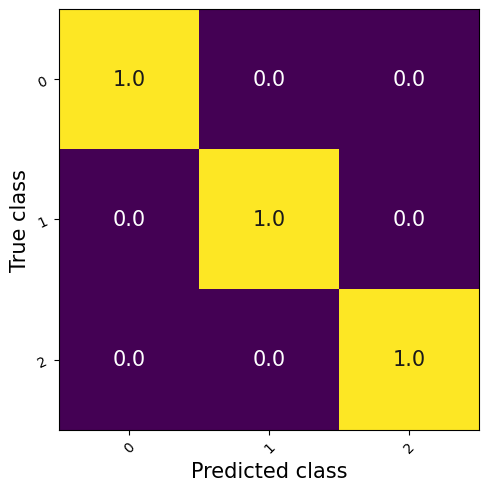

tensor([[1003,    0,    0],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.4286 ✨
MAE per_class: {1: np.float64(2.090909090909091), 2: np.float64(0.7)} ✨
 === Currently Evaluating curr_test_idx: 84 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
croppe

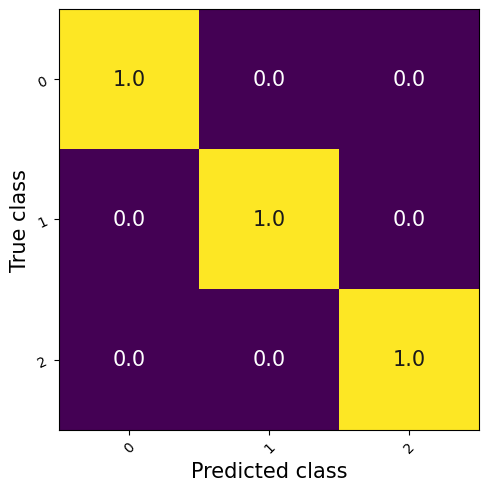

tensor([[1002,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.2727 ✨
MAE per_class: {1: np.float64(1.9090909090909092), 2: np.float64(0.6363636363636364)} ✨
 === Currently Evaluating curr_test_idx: 85 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand

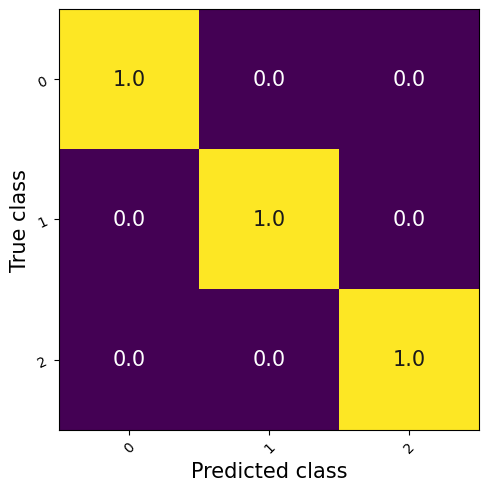

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.3913 ✨
MAE per_class: {1: np.float64(2.0), 2: np.float64(0.7272727272727273)} ✨
 === Currently Evaluating curr_test_idx: 86 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropp

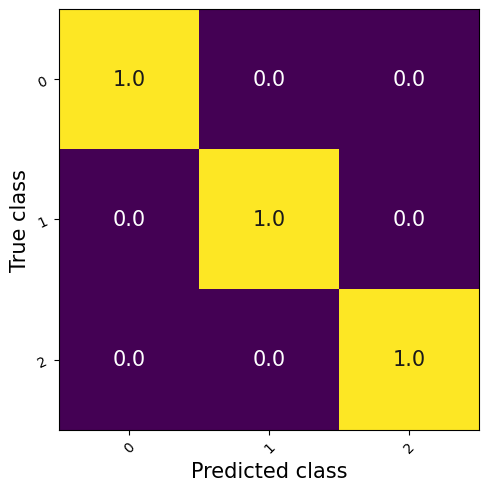

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.2174 ✨
MAE per_class: {1: np.float64(1.8333333333333333), 2: np.float64(0.5454545454545454)} ✨
 === Currently Evaluating curr_test_idx: 87 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_

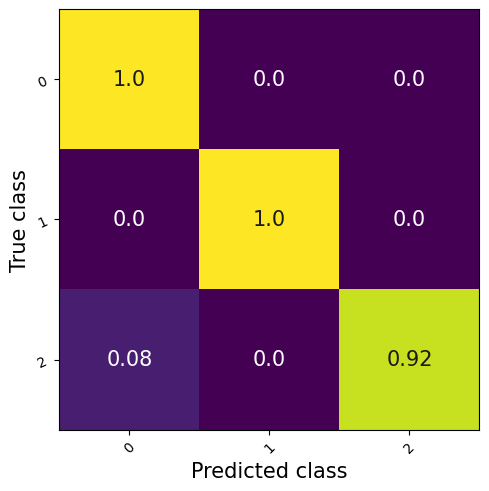

tensor([[1513,    0,    1],
        [   0,   10,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9720 ✨
perclass_f1scores: tensor([0.9993, 1.0000, 0.9167])
perclass_precision: tensor([0.9993, 1.0000, 0.9167])
perclass_recall: tensor([0.9993, 1.0000, 0.9167])
MAE overall: 1.8182 ✨
MAE per_class: {1: np.float64(2.0), 2: np.float64(1.6666666666666667)} ✨
 === Currently Evaluating curr_test_idx: 88 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_0

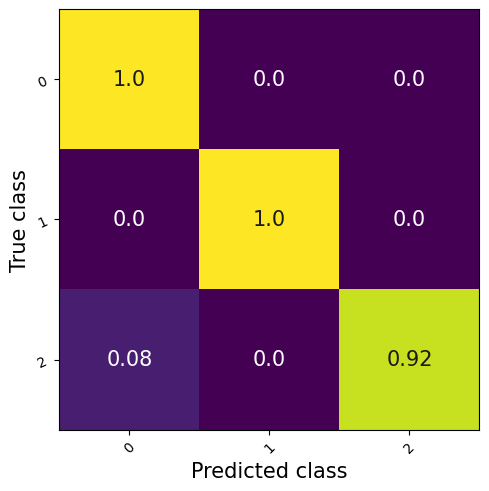

tensor([[1254,    0,    1],
        [   0,   13,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9720 ✨
perclass_f1scores: tensor([0.9992, 1.0000, 0.9167])
perclass_precision: tensor([0.9992, 1.0000, 0.9167])
perclass_recall: tensor([0.9992, 1.0000, 0.9167])
MAE overall: 1.9200 ✨
MAE per_class: {1: np.float64(2.0), 2: np.float64(1.8333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 89 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_0

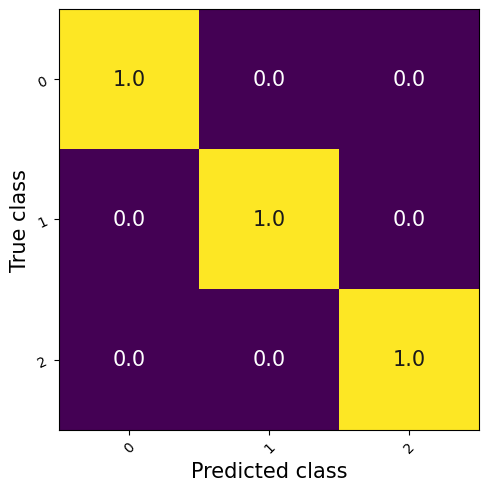

tensor([[1001,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.5652 ✨
MAE per_class: {1: np.float64(1.6666666666666667), 2: np.float64(1.4545454545454546)} ✨
 === Currently Evaluating curr_test_idx: 90 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_

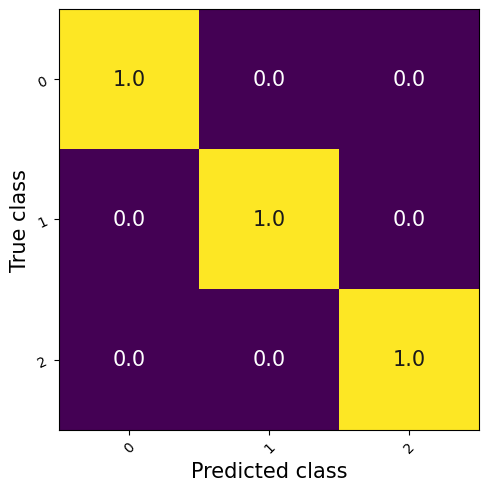

tensor([[1511,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.6400 ✨
MAE per_class: {1: np.float64(1.6923076923076923), 2: np.float64(1.5833333333333333)} ✨
 === Currently Evaluating curr_test_idx: 91 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_

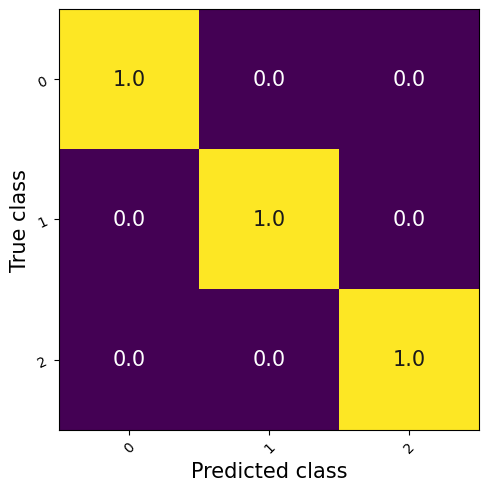

tensor([[1255,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.5600 ✨
MAE per_class: {1: np.float64(1.7692307692307692), 2: np.float64(1.3333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 92 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand

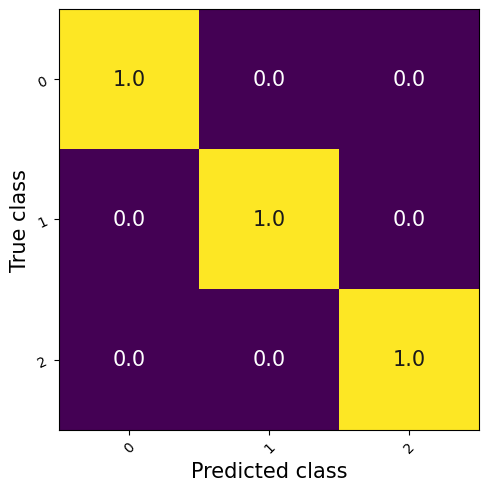

tensor([[2029,    0,    0],
        [   0,    9,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4211 ✨
MAE per_class: {1: np.float64(0.5555555555555556), 2: np.float64(0.3)} ✨
 === Currently Evaluating curr_test_idx: 93 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropp

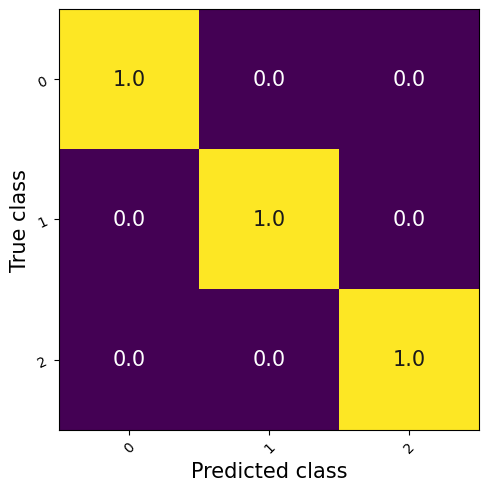

tensor([[1512,    1,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 0.9565, 1.0000])
perclass_precision: tensor([1.0000, 0.9167, 1.0000])
perclass_recall: tensor([0.9993, 1.0000, 1.0000])
MAE overall: 0.4783 ✨
MAE per_class: {1: np.float64(0.9090909090909091), 2: np.float64(0.08333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 94 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelgr

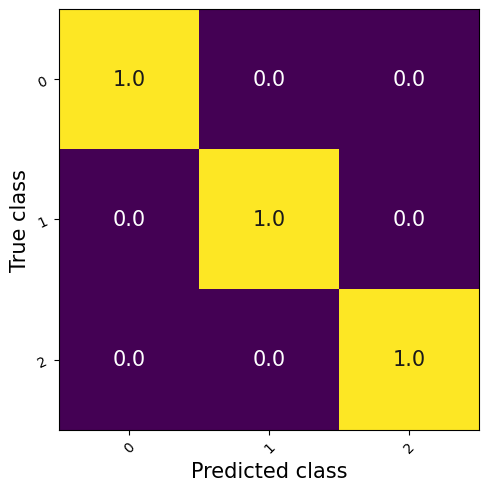

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4545 ✨
MAE per_class: {1: np.float64(0.9090909090909091), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 95 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropp

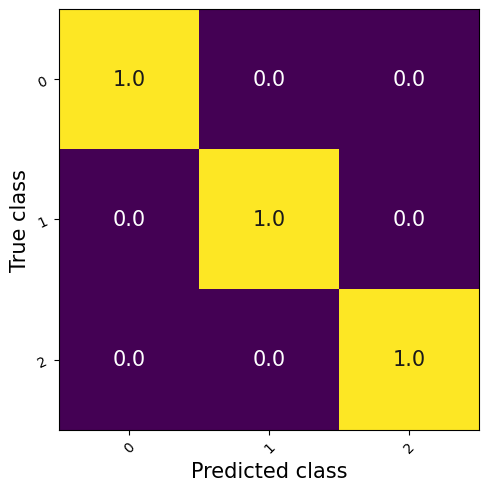

tensor([[1515,    0,    0],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5238 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 96 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: 

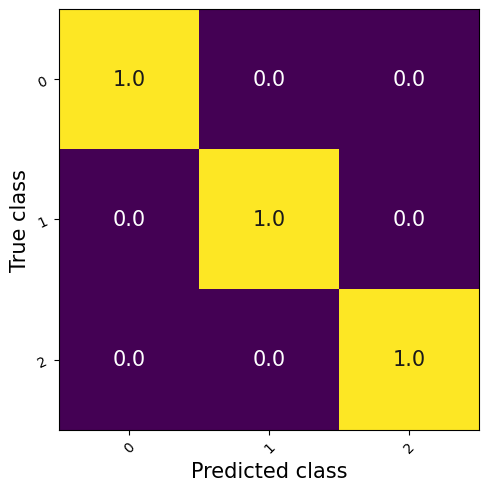

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3182 ✨
MAE per_class: {1: np.float64(0.6363636363636364), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 97 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
croppe

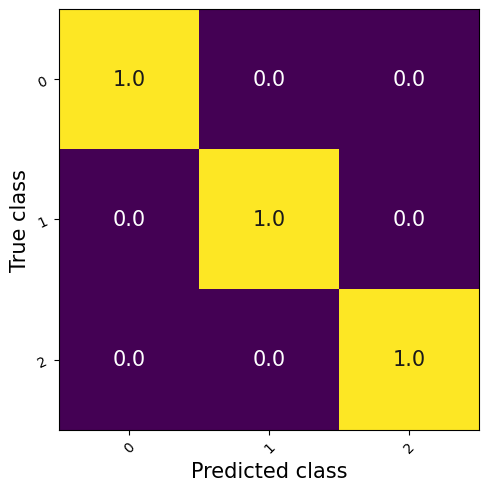

tensor([[1511,    0,    1],
        [   0,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9866 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9600])
perclass_precision: tensor([1.0000, 1.0000, 0.9231])
perclass_recall: tensor([0.9993, 1.0000, 1.0000])
MAE overall: 0.3750 ✨
MAE per_class: {1: np.float64(0.5833333333333334), 2: np.float64(0.16666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 98 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelgr

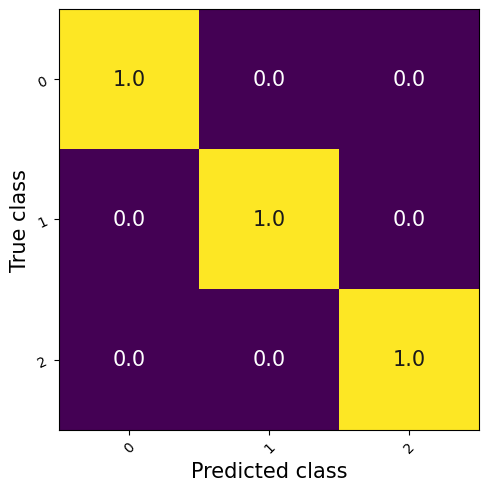

tensor([[1768,    0,    0],
        [   0,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5833 ✨
MAE per_class: {1: np.float64(0.9166666666666666), 2: np.float64(0.25)} ✨
 === Currently Evaluating curr_test_idx: 99 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
crop

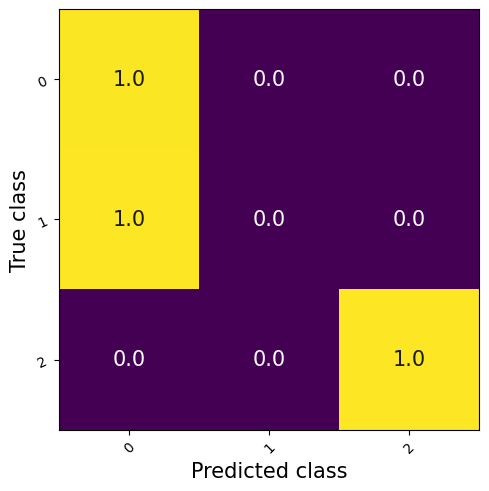

tensor([[2268,    5,    6],
        [  12,    0,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.6025 ✨
perclass_f1scores: tensor([0.9950, 0.0000, 0.8125])
perclass_precision: tensor([0.9947, 0.0000, 0.6842])
perclass_recall: tensor([0.9952, 0.0000, 1.0000])
MAE overall: 1.4118 ✨
MAE per_class: {1: np.float64(4.0), 2: np.float64(0.6153846153846154)} ✨
 === Currently Evaluating curr_test_idx: 100 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_normal

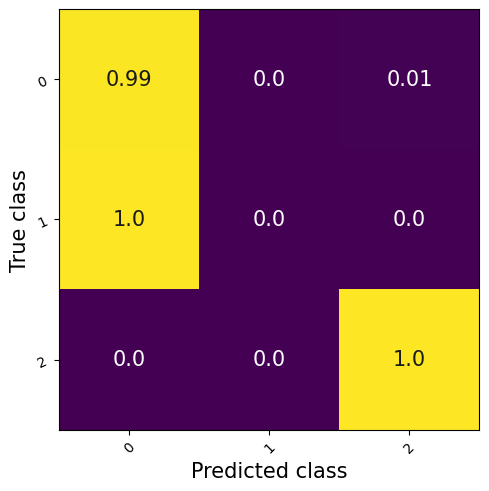

tensor([[1753,    2,   10],
        [  14,    0,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.5716 ✨
perclass_f1scores: tensor([0.9926, 0.0000, 0.7222])
perclass_precision: tensor([0.9921, 0.0000, 0.5652])
perclass_recall: tensor([0.9932, 0.0000, 1.0000])
MAE overall: 0.9333 ✨
MAE per_class: {1: np.float64(4.0), 2: np.float64(0.46153846153846156)} ✨
 === Currently Evaluating curr_test_idx: 101 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_norma

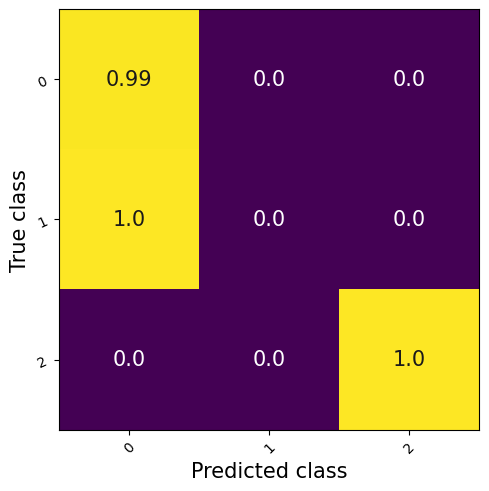

tensor([[2008,    5,    6],
        [  15,    0,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.6057 ✨
perclass_f1scores: tensor([0.9936, 0.0000, 0.8235])
perclass_precision: tensor([0.9926, 0.0000, 0.7000])
perclass_recall: tensor([0.9946, 0.0000, 1.0000])
MAE overall: 1.5789 ✨
MAE per_class: {1: np.float64(4.2), 2: np.float64(0.6428571428571429)} ✨
 === Currently Evaluating curr_test_idx: 102 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_normal

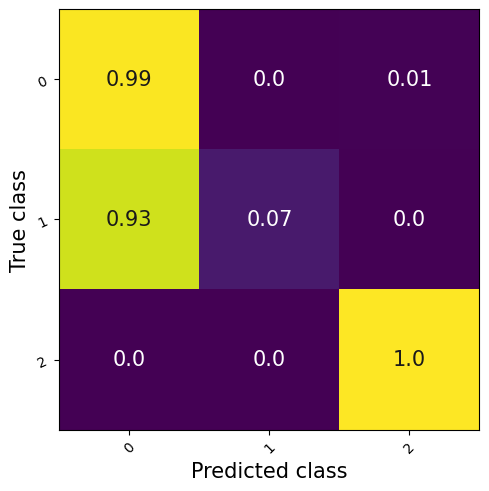

tensor([[1754,    2,    9],
        [  13,    1,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.6179 ✨
perclass_f1scores: tensor([0.9932, 0.1176, 0.7429])
perclass_precision: tensor([0.9926, 0.3333, 0.5909])
perclass_recall: tensor([0.9938, 0.0714, 1.0000])
MAE overall: 1.1875 ✨
MAE per_class: {1: np.float64(3.3333333333333335), 2: np.float64(0.6923076923076923)} ✨
 === Currently Evaluating curr_test_idx: 103 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelgr

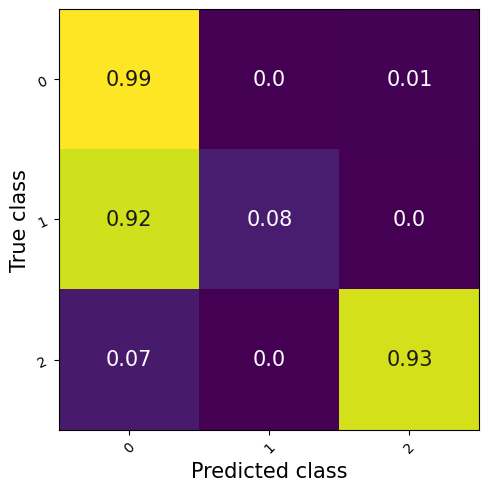

tensor([[1753,    2,   10],
        [  12,    1,    0],
        [   1,    0,   13]])
Macro F1-Score: 0.6069 ✨
perclass_f1scores: tensor([0.9929, 0.1250, 0.7027])
perclass_precision: tensor([0.9926, 0.3333, 0.5652])
perclass_recall: tensor([0.9932, 0.0769, 0.9286])
MAE overall: 0.6667 ✨
MAE per_class: {1: np.float64(2.0), 2: np.float64(0.46153846153846156)} ✨
 === Currently Evaluating curr_test_idx: 104 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_ccw_norma

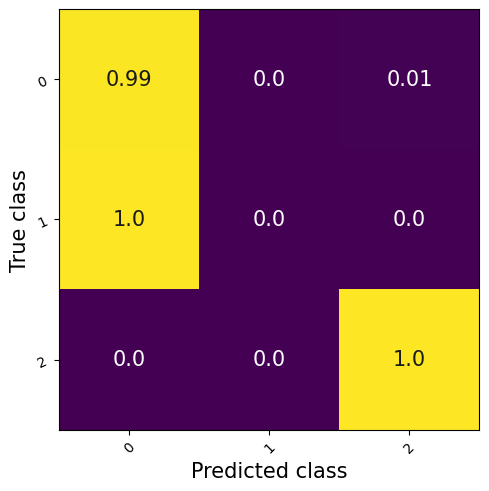

tensor([[1752,    2,   10],
        [  14,    0,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.5765 ✨
perclass_f1scores: tensor([0.9926, 0.0000, 0.7368])
perclass_precision: tensor([0.9921, 0.0000, 0.5833])
perclass_recall: tensor([0.9932, 0.0000, 1.0000])
MAE overall: 1.0000 ✨
MAE per_class: {1: np.float64(4.0), 2: np.float64(0.5714285714285714)} ✨
 === Currently Evaluating curr_test_idx: 105 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_normal_

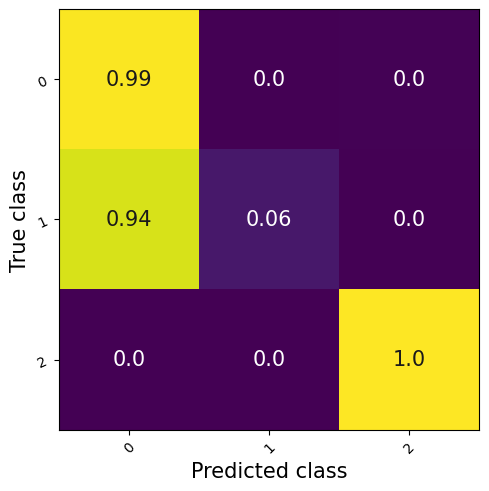

tensor([[2262,    1,   11],
        [  15,    1,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.6077 ✨
perclass_f1scores: tensor([0.9941, 0.1111, 0.7179])
perclass_precision: tensor([0.9934, 0.5000, 0.5600])
perclass_recall: tensor([0.9947, 0.0625, 1.0000])
MAE overall: 0.6250 ✨
MAE per_class: {1: np.float64(2.0), 2: np.float64(0.42857142857142855)} ✨
 === Currently Evaluating curr_test_idx: 106 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_normal

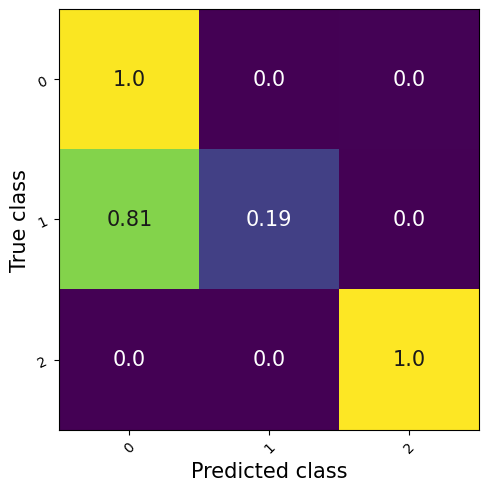

tensor([[2261,    0,   11],
        [  13,    3,    0],
        [   0,    0,   16]])
Macro F1-Score: 0.6849 ✨
perclass_f1scores: tensor([0.9947, 0.3158, 0.7442])
perclass_precision: tensor([0.9943, 1.0000, 0.5926])
perclass_recall: tensor([0.9952, 0.1875, 1.0000])
MAE overall: 1.0000 ✨
MAE per_class: {1: np.float64(2.0), 2: np.float64(0.8125)} ✨
 === Currently Evaluating curr_test_idx: 107 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_normal_01_03.npy
se

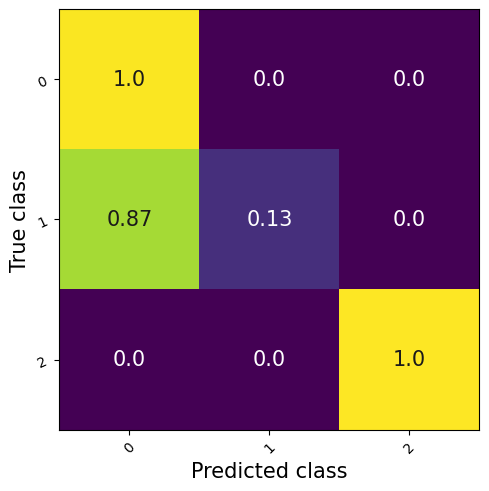

tensor([[2264,    1,    8],
        [  13,    2,    0],
        [   0,    0,   16]])
Macro F1-Score: 0.6725 ✨
perclass_f1scores: tensor([0.9952, 0.2222, 0.8000])
perclass_precision: tensor([0.9943, 0.6667, 0.6667])
perclass_recall: tensor([0.9960, 0.1333, 1.0000])
MAE overall: 0.8421 ✨
MAE per_class: {1: np.float64(2.3333333333333335), 2: np.float64(0.5625)} ✨
 === Currently Evaluating curr_test_idx: 108 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_norm

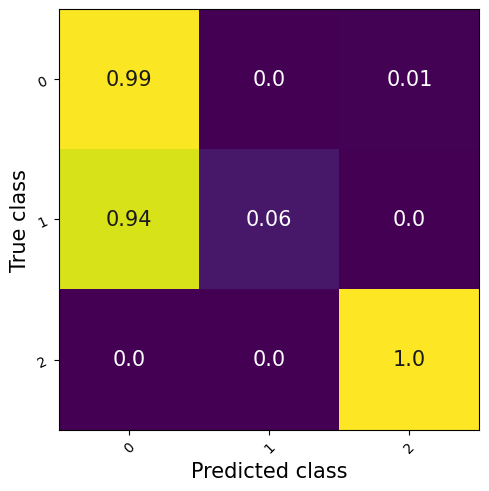

tensor([[2261,    0,   12],
        [  15,    1,    0],
        [   0,    0,   15]])
Macro F1-Score: 0.6087 ✨
perclass_f1scores: tensor([0.9941, 0.1176, 0.7143])
perclass_precision: tensor([0.9934, 1.0000, 0.5556])
perclass_recall: tensor([0.9947, 0.0625, 1.0000])
MAE overall: 0.8125 ✨
MAE per_class: {1: np.float64(3.0), 2: np.float64(0.6666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 109 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB16/11_11_2018/levelground/imu/levelground_cw_normal_

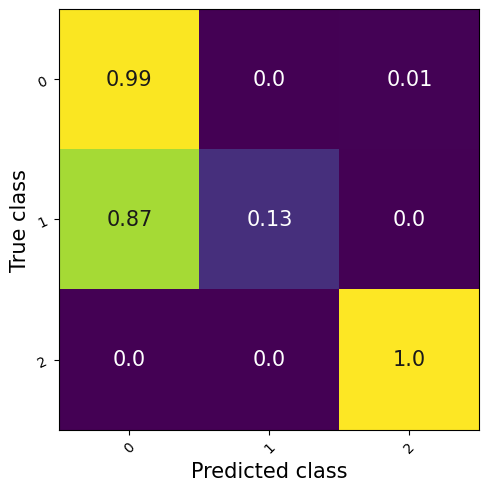

tensor([[2262,    0,   12],
        [  13,    2,    0],
        [   0,    0,   15]])
Macro F1-Score: 0.6480 ✨
perclass_f1scores: tensor([0.9945, 0.2353, 0.7143])
perclass_precision: tensor([0.9943, 1.0000, 0.5556])
perclass_recall: tensor([0.9947, 0.1333, 1.0000])
MAE overall: 0.6471 ✨
MAE per_class: {1: np.float64(1.5), 2: np.float64(0.5333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 110 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal

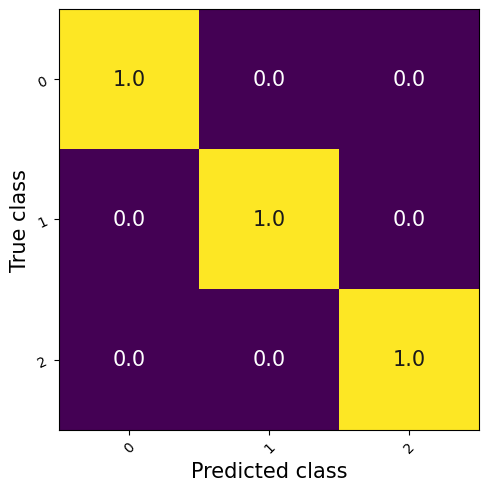

tensor([[2027,    0,    0],
        [   0,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.8095 ✨
MAE per_class: {1: np.float64(1.2), 2: np.float64(0.45454545454545453)} ✨
 === Currently Evaluating curr_test_idx: 111 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cro

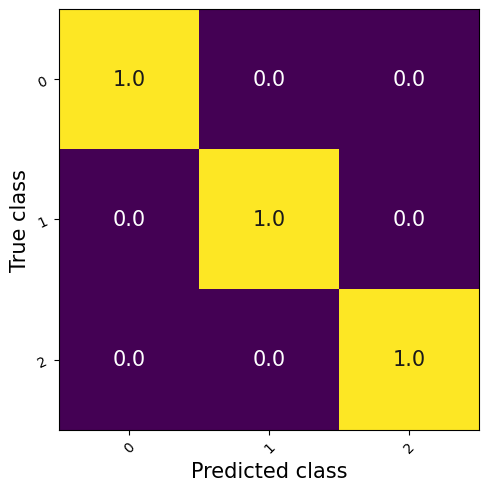

tensor([[1257,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6087 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.25)} ✨
 === Currently Evaluating curr_test_idx: 112 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shap

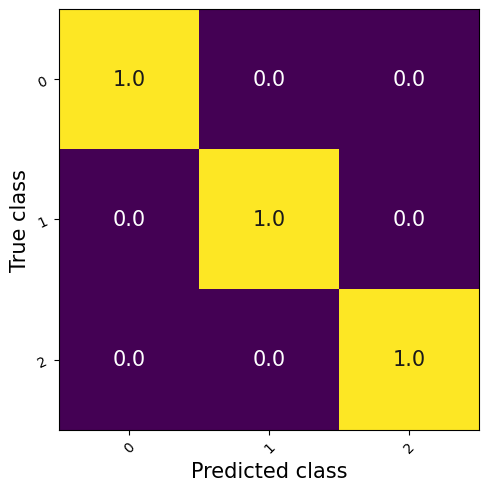

tensor([[1260,    0,    0],
        [   0,   11,    0],
        [   0,    0,    9]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4000 ✨
MAE per_class: {1: np.float64(0.7272727272727273), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 113 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
crop

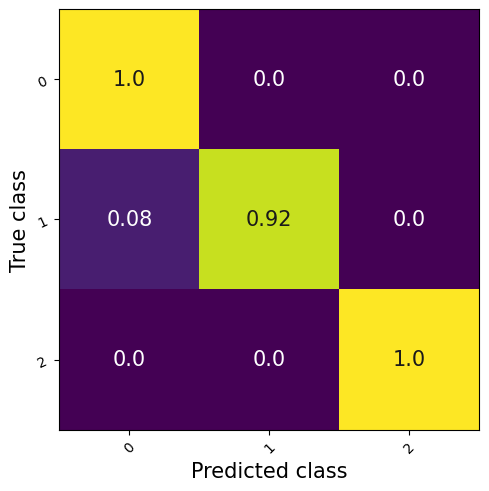

tensor([[1768,    1,    0],
        [   1,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9720 ✨
perclass_f1scores: tensor([0.9994, 0.9167, 1.0000])
perclass_precision: tensor([0.9994, 0.9167, 1.0000])
perclass_recall: tensor([0.9994, 0.9167, 1.0000])
MAE overall: 0.8261 ✨
MAE per_class: {1: np.float64(1.4166666666666667), 2: np.float64(0.18181818181818182)} ✨
 === Currently Evaluating curr_test_idx: 114 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelg

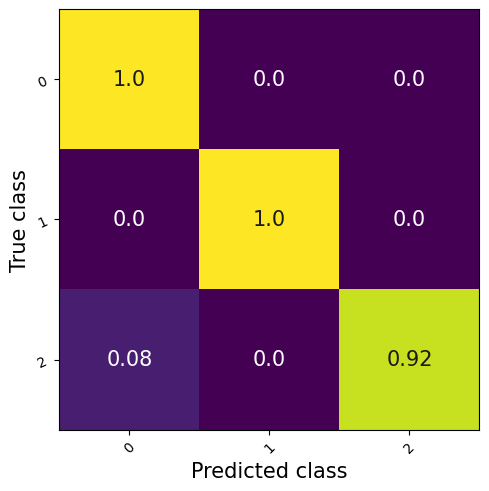

tensor([[2025,    1,    0],
        [   0,   10,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9695 ✨
perclass_f1scores: tensor([0.9995, 0.9524, 0.9565])
perclass_precision: tensor([0.9995, 0.9091, 1.0000])
perclass_recall: tensor([0.9995, 1.0000, 0.9167])
MAE overall: 0.6667 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.36363636363636365)} ✨
 === Currently Evaluating curr_test_idx: 115 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal

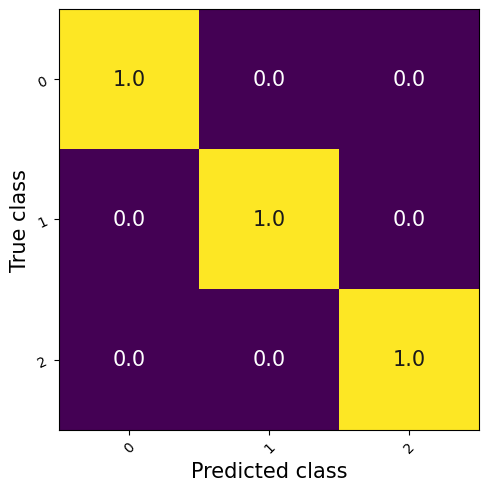

tensor([[1512,    0,    0],
        [   0,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5417 ✨
MAE per_class: {1: np.float64(0.75), 2: np.float64(0.3333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 116 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
crop

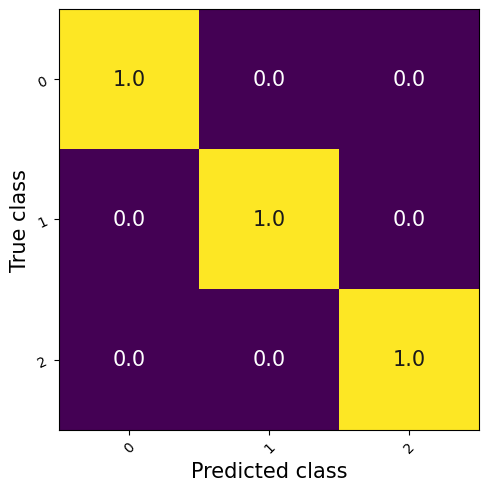

tensor([[1510,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5385 ✨
MAE per_class: {1: np.float64(0.6428571428571429), 2: np.float64(0.4166666666666667)} ✨
 === Currently Evaluating curr_test_idx: 117 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand

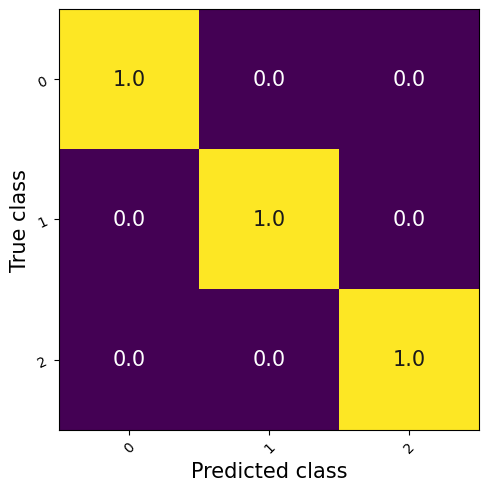

tensor([[1510,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5769 ✨
MAE per_class: {1: np.float64(0.7142857142857143), 2: np.float64(0.4166666666666667)} ✨
 === Currently Evaluating curr_test_idx: 118 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expan

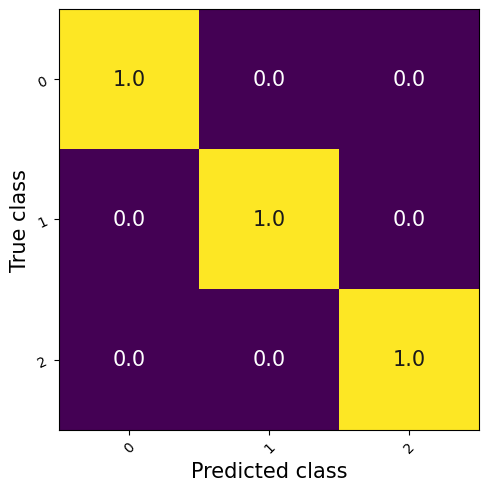

tensor([[1773,    0,    0],
        [   0,    9,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.2105 ✨
MAE per_class: {1: np.float64(2.111111111111111), 2: np.float64(0.4)} ✨
 === Currently Evaluating curr_test_idx: 119 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropp

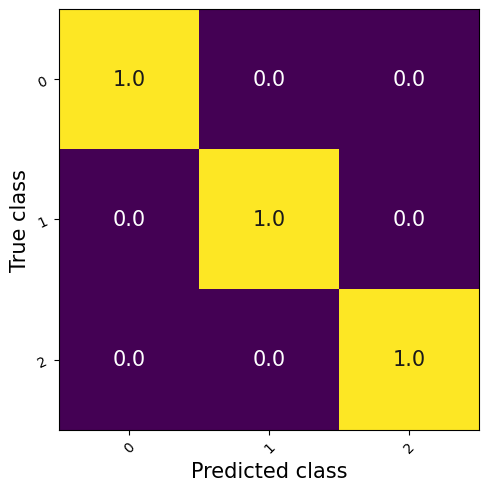

tensor([[1260,    0,    0],
        [   0,   10,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.0000 ✨
MAE per_class: {1: np.float64(2.0), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 120 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape

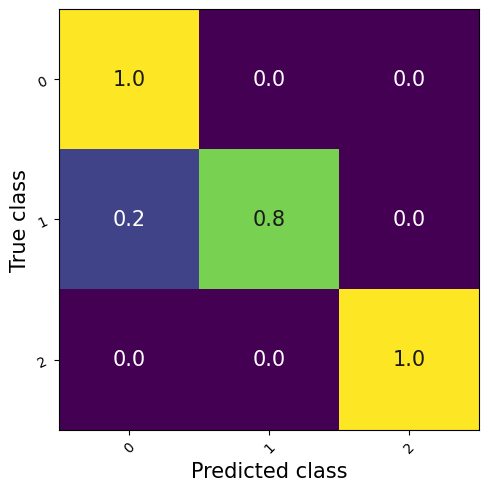

tensor([[1258,    1,    1],
        [   2,    8,    0],
        [   0,    0,   10]])
Macro F1-Score: 0.9310 ✨
perclass_f1scores: tensor([0.9984, 0.8421, 0.9524])
perclass_precision: tensor([0.9984, 0.8889, 0.9091])
perclass_recall: tensor([0.9984, 0.8000, 1.0000])
MAE overall: 1.0000 ✨
MAE per_class: {1: np.float64(1.7777777777777777), 2: np.float64(0.3)} ✨
 === Currently Evaluating curr_test_idx: 121 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal

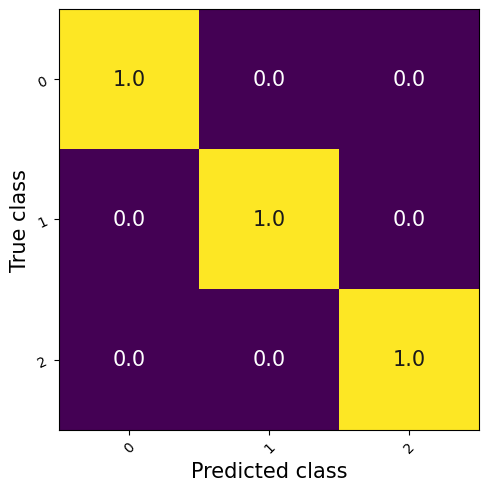

tensor([[1260,    0,    0],
        [   0,   10,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.0000 ✨
MAE per_class: {1: np.float64(1.9), 2: np.float64(0.1)} ✨
 === Currently Evaluating curr_test_idx: 122 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape

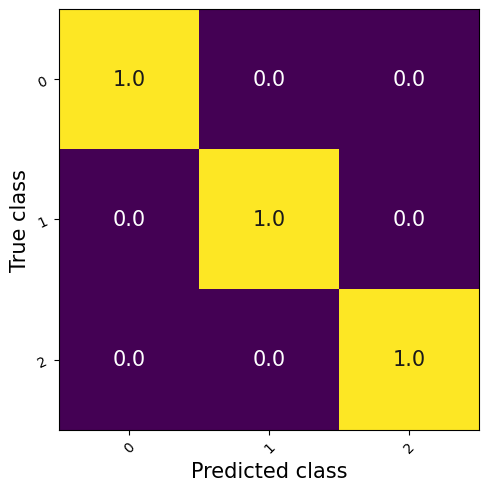

tensor([[1772,    0,    0],
        [   0,   10,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.1000 ✨
MAE per_class: {1: np.float64(2.2), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 123 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape:

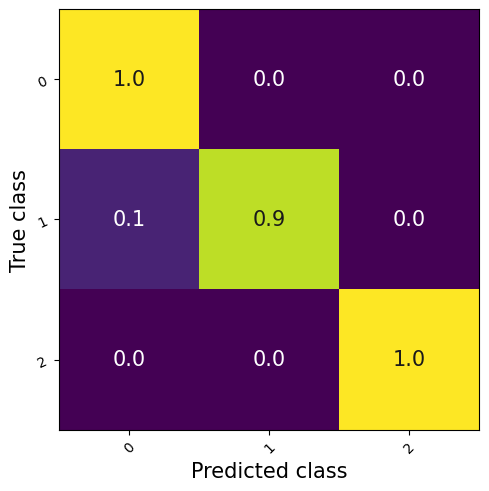

tensor([[2026,    0,    1],
        [   1,    9,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9678 ✨
perclass_f1scores: tensor([0.9995, 0.9474, 0.9565])
perclass_precision: tensor([0.9995, 1.0000, 0.9167])
perclass_recall: tensor([0.9995, 0.9000, 1.0000])
MAE overall: 0.9000 ✨
MAE per_class: {1: np.float64(1.4444444444444444), 2: np.float64(0.45454545454545453)} ✨
 === Currently Evaluating curr_test_idx: 124 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelg

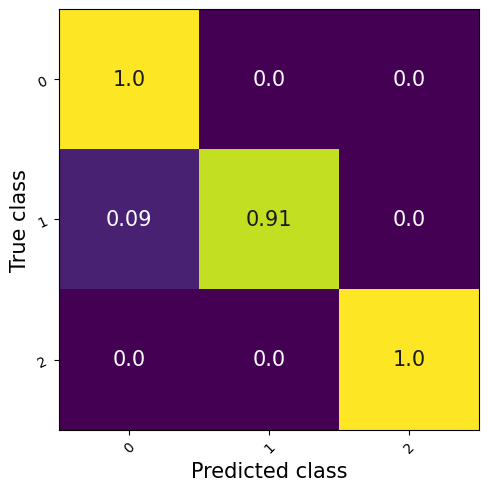

tensor([[1259,    0,    0],
        [   1,   10,    0],
        [   0,    0,   10]])
Macro F1-Score: 0.9840 ✨
perclass_f1scores: tensor([0.9996, 0.9524, 1.0000])
perclass_precision: tensor([0.9992, 1.0000, 1.0000])
perclass_recall: tensor([1.0000, 0.9091, 1.0000])
MAE overall: 0.9000 ✨
MAE per_class: {1: np.float64(1.5), 2: np.float64(0.3)} ✨
 === Currently Evaluating curr_test_idx: 125 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.

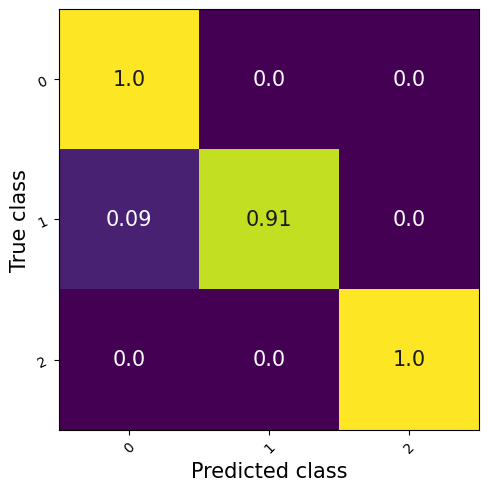

tensor([[1513,    0,    1],
        [   1,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9694 ✨
perclass_f1scores: tensor([0.9993, 0.9524, 0.9565])
perclass_precision: tensor([0.9993, 1.0000, 0.9167])
perclass_recall: tensor([0.9993, 0.9091, 1.0000])
MAE overall: 0.7619 ✨
MAE per_class: {1: np.float64(1.2), 2: np.float64(0.36363636363636365)} ✨
 === Currently Evaluating curr_test_idx: 126 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_cw_normal

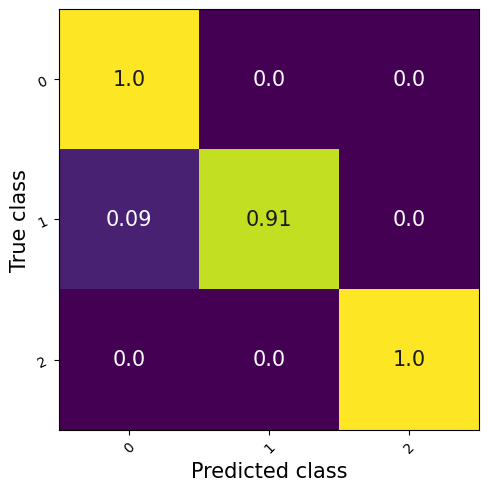

tensor([[1514,    0,    1],
        [   1,   10,    0],
        [   0,    0,   10]])
Macro F1-Score: 0.9680 ✨
perclass_f1scores: tensor([0.9993, 0.9524, 0.9524])
perclass_precision: tensor([0.9993, 1.0000, 0.9091])
perclass_recall: tensor([0.9993, 0.9091, 1.0000])
MAE overall: 0.8000 ✨
MAE per_class: {1: np.float64(1.2), 2: np.float64(0.4)} ✨
 === Currently Evaluating curr_test_idx: 127 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB18/11_14_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.

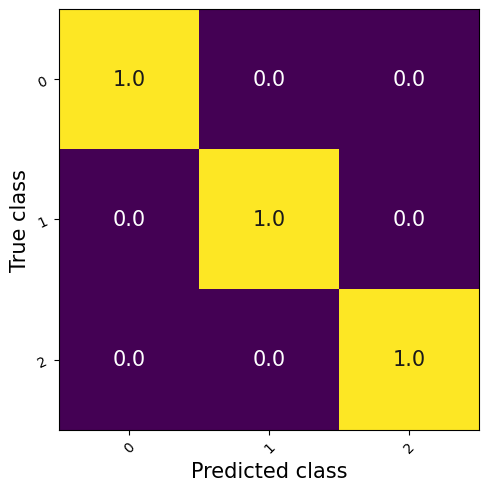

tensor([[2026,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.0455 ✨
MAE per_class: {1: np.float64(1.7272727272727273), 2: np.float64(0.36363636363636365)} ✨
 === Currently Evaluating curr_test_idx: 128 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expa

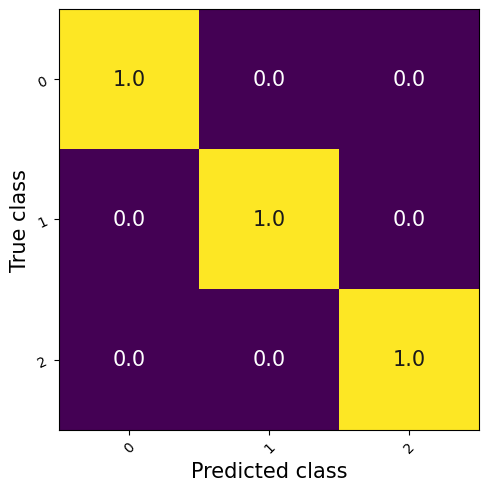

tensor([[2023,    0,    0],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1200 ✨
MAE per_class: {1: np.float64(0.25), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 129 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shap

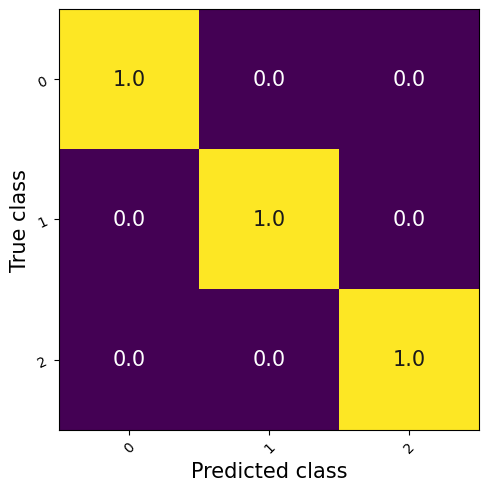

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0455 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 130 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cro

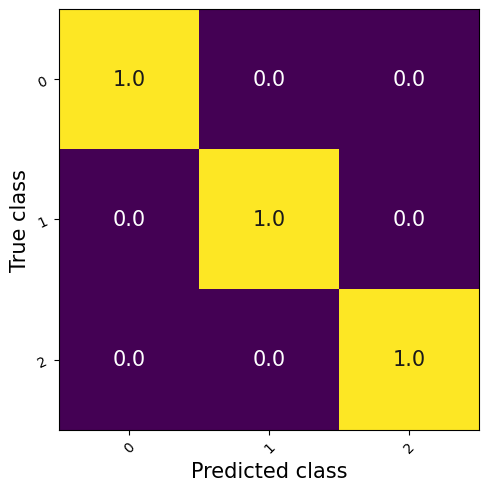

tensor([[1769,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.2609 ✨
MAE per_class: {1: np.float64(0.5454545454545454), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 131 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
crop

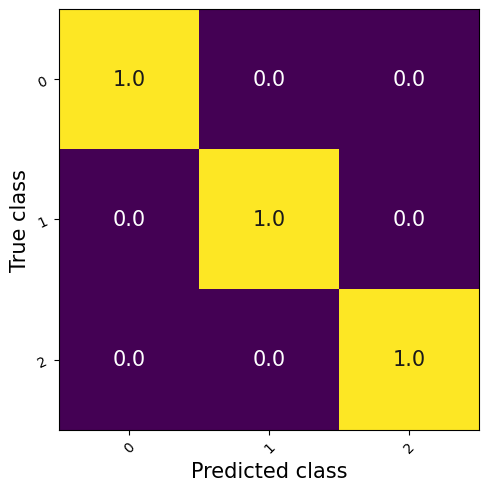

tensor([[1768,    0,    1],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9866 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9600])
perclass_precision: tensor([1.0000, 1.0000, 0.9231])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.1739 ✨
MAE per_class: {1: np.float64(0.36363636363636365), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 132 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_norma

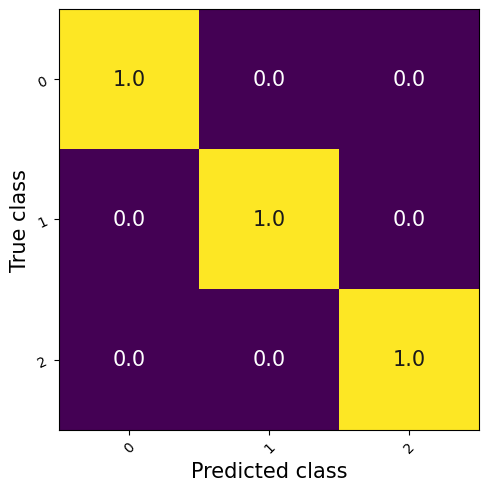

tensor([[2026,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1364 ✨
MAE per_class: {1: np.float64(0.2727272727272727), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 133 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropp

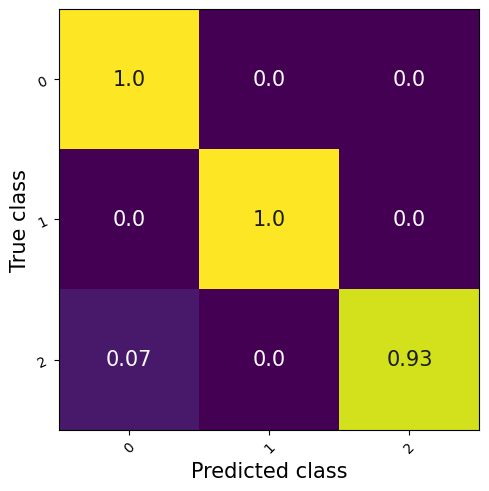

tensor([[2532,    0,    0],
        [   0,   13,    0],
        [   1,    0,   14]])
Macro F1-Score: 0.9884 ✨
perclass_f1scores: tensor([0.9998, 1.0000, 0.9655])
perclass_precision: tensor([0.9996, 1.0000, 1.0000])
perclass_recall: tensor([1.0000, 1.0000, 0.9333])
MAE overall: 0.3333 ✨
MAE per_class: {1: np.float64(0.46153846153846156), 2: np.float64(0.21428571428571427)} ✨
 === Currently Evaluating curr_test_idx: 134 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/level

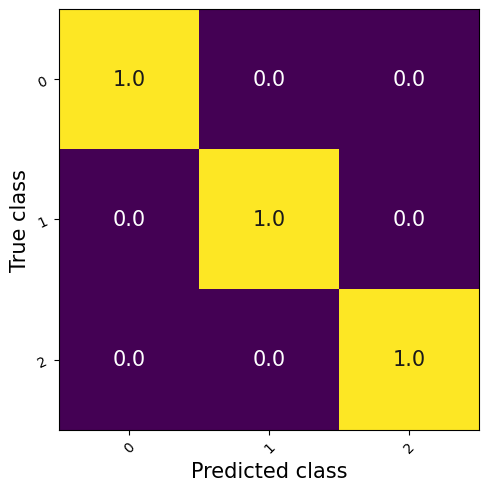

tensor([[2020,    0,    0],
        [   0,   14,    0],
        [   0,    0,   14]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4643 ✨
MAE per_class: {1: np.float64(0.7857142857142857), 2: np.float64(0.14285714285714285)} ✨
 === Currently Evaluating curr_test_idx: 135 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expan

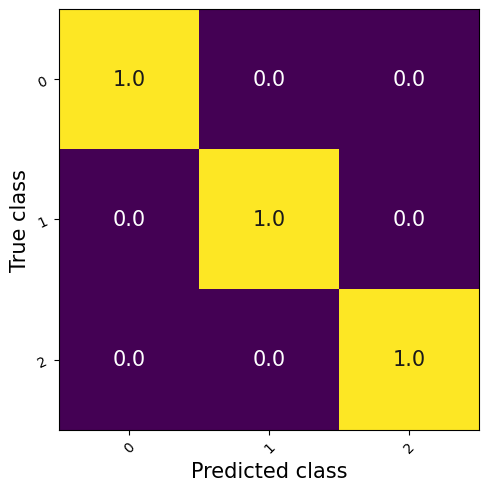

tensor([[1765,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3333 ✨
MAE per_class: {1: np.float64(0.5714285714285714), 2: np.float64(0.07692307692307693)} ✨
 === Currently Evaluating curr_test_idx: 136 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expan

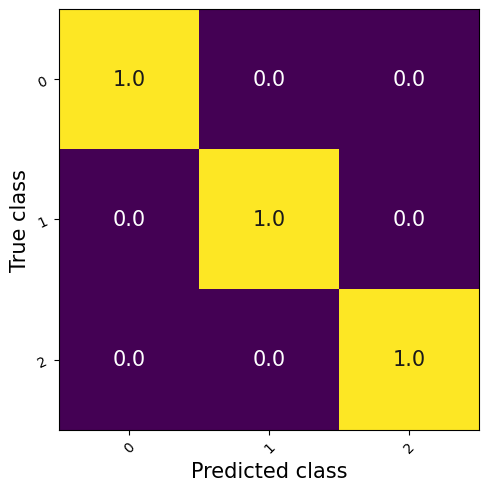

tensor([[1765,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3704 ✨
MAE per_class: {1: np.float64(0.5714285714285714), 2: np.float64(0.15384615384615385)} ✨
 === Currently Evaluating curr_test_idx: 137 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expan

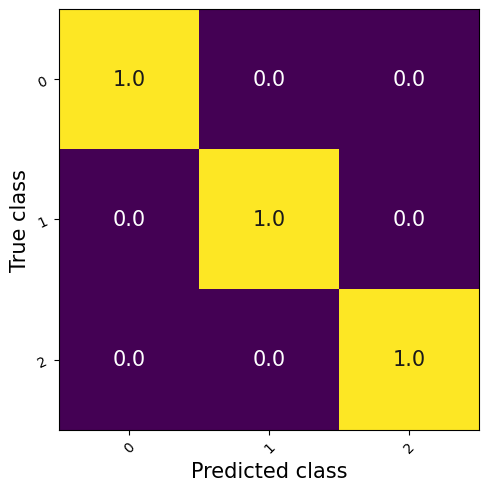

tensor([[2276,    0,    1],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9876 ✨
perclass_f1scores: tensor([0.9998, 1.0000, 0.9630])
perclass_precision: tensor([1.0000, 1.0000, 0.9286])
perclass_recall: tensor([0.9996, 1.0000, 1.0000])
MAE overall: 0.3704 ✨
MAE per_class: {1: np.float64(0.5), 2: np.float64(0.23076923076923078)} ✨
 === Currently Evaluating curr_test_idx: 138 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_ccw_norma

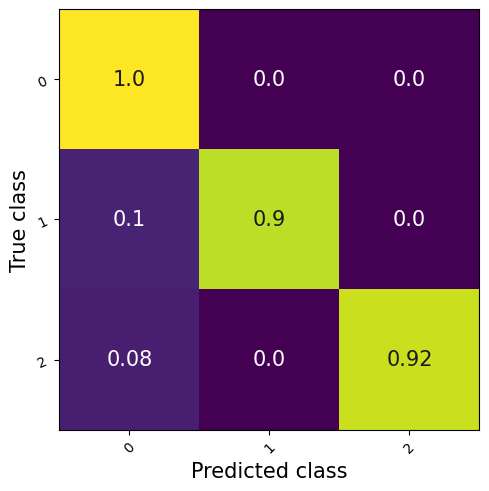

tensor([[1767,    1,    2],
        [   1,    9,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9262 ✨
perclass_f1scores: tensor([0.9986, 0.9000, 0.8800])
perclass_precision: tensor([0.9989, 0.9000, 0.8462])
perclass_recall: tensor([0.9983, 0.9000, 0.9167])
MAE overall: 0.8095 ✨
MAE per_class: {1: np.float64(1.3333333333333333), 2: np.float64(0.4166666666666667)} ✨
 === Currently Evaluating curr_test_idx: 139 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelgr

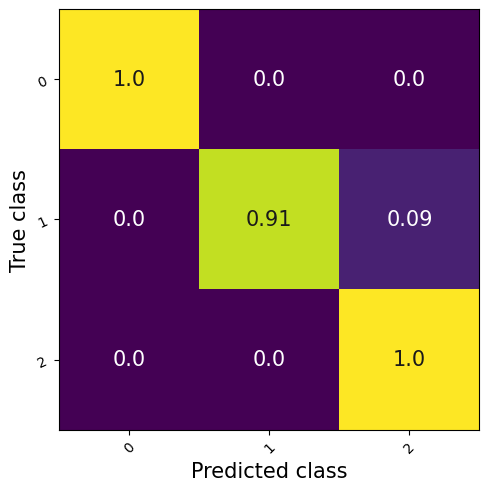

tensor([[1770,    0,    0],
        [   0,   10,    1],
        [   0,    0,   11]])
Macro F1-Score: 0.9696 ✨
perclass_f1scores: tensor([1.0000, 0.9524, 0.9565])
perclass_precision: tensor([1.0000, 1.0000, 0.9167])
perclass_recall: tensor([1.0000, 0.9091, 1.0000])
MAE overall: 0.7143 ✨
MAE per_class: {1: np.float64(1.2), 2: np.float64(0.2727272727272727)} ✨
 === Currently Evaluating curr_test_idx: 140 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_ccw_normal

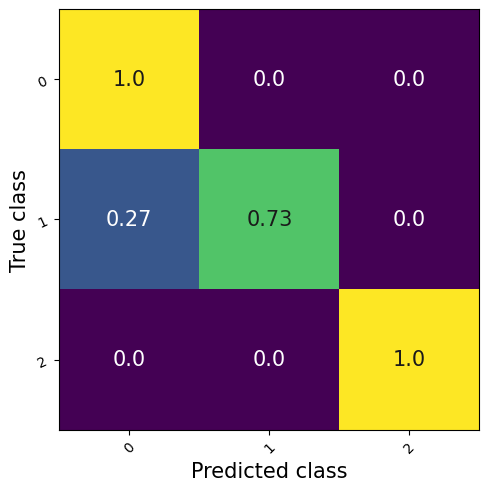

tensor([[1510,    1,    2],
        [   3,    8,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9070 ✨
perclass_f1scores: tensor([0.9980, 0.8000, 0.9231])
perclass_precision: tensor([0.9980, 0.8889, 0.8571])
perclass_recall: tensor([0.9980, 0.7273, 1.0000])
MAE overall: 0.8571 ✨
MAE per_class: {1: np.float64(1.7777777777777777), 2: np.float64(0.16666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 141 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelg

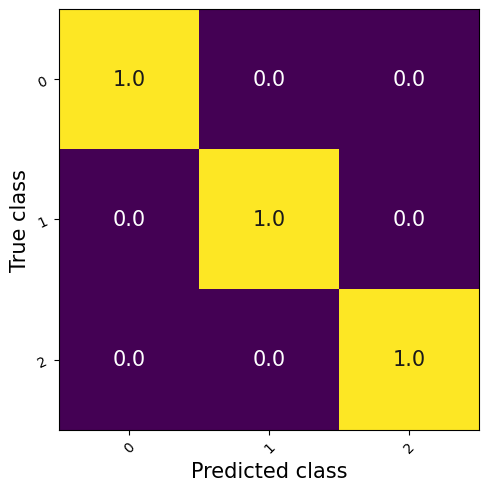

tensor([[1511,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.8000 ✨
MAE per_class: {1: np.float64(1.4615384615384615), 2: np.float64(0.08333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 142 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expan

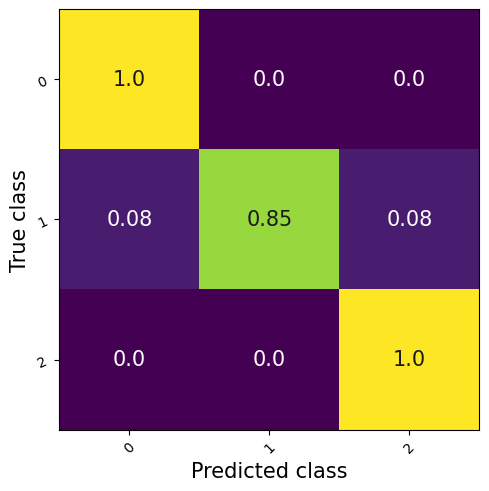

tensor([[2019,    1,    1],
        [   1,   11,    1],
        [   0,    0,   14]])
Macro F1-Score: 0.9375 ✨
perclass_f1scores: tensor([0.9993, 0.8800, 0.9333])
perclass_precision: tensor([0.9995, 0.9167, 0.8750])
perclass_recall: tensor([0.9990, 0.8462, 1.0000])
MAE overall: 0.6800 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.42857142857142855)} ✨
 === Currently Evaluating curr_test_idx: 143 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_cw_normal

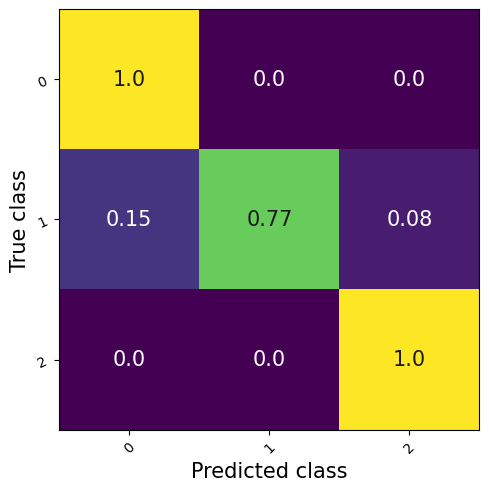

tensor([[1507,    0,    2],
        [   2,   10,    1],
        [   0,    0,   14]])
Macro F1-Score: 0.9238 ✨
perclass_f1scores: tensor([0.9987, 0.8696, 0.9032])
perclass_precision: tensor([0.9987, 1.0000, 0.8235])
perclass_recall: tensor([0.9987, 0.7692, 1.0000])
MAE overall: 0.6250 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.35714285714285715)} ✨
 === Currently Evaluating curr_test_idx: 144 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_cw_normal

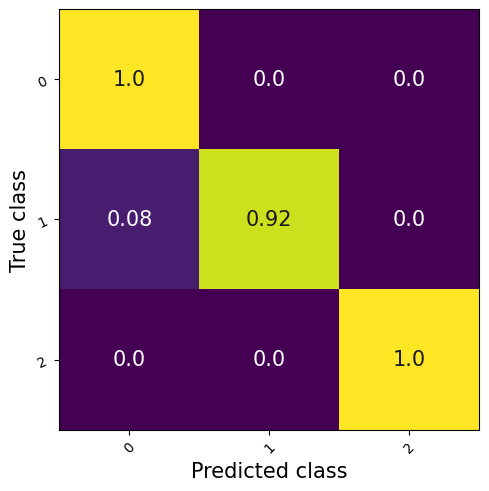

tensor([[1508,    0,    1],
        [   1,   12,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9750 ✨
perclass_f1scores: tensor([0.9993, 0.9600, 0.9655])
perclass_precision: tensor([0.9993, 1.0000, 0.9333])
perclass_recall: tensor([0.9993, 0.9231, 1.0000])
MAE overall: 0.6538 ✨
MAE per_class: {1: np.float64(1.1666666666666667), 2: np.float64(0.21428571428571427)} ✨
 === Currently Evaluating curr_test_idx: 145 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelg

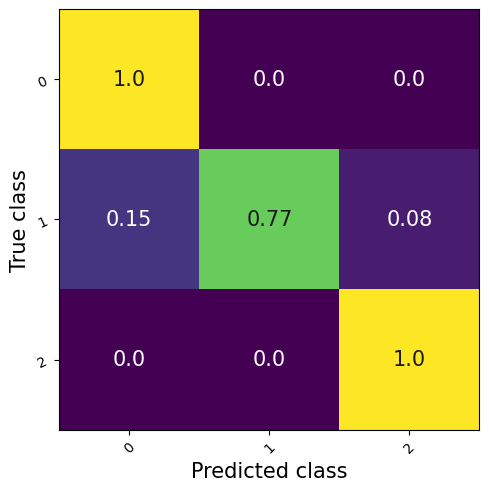

tensor([[1508,    0,    1],
        [   2,   10,    1],
        [   0,    0,   14]])
Macro F1-Score: 0.9340 ✨
perclass_f1scores: tensor([0.9990, 0.8696, 0.9333])
perclass_precision: tensor([0.9987, 1.0000, 0.8750])
perclass_recall: tensor([0.9993, 0.7692, 1.0000])
MAE overall: 0.4583 ✨
MAE per_class: {1: np.float64(0.8), 2: np.float64(0.21428571428571427)} ✨
 === Currently Evaluating curr_test_idx: 146 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB20/11_18_2018/levelground/imu/levelground_cw_normal

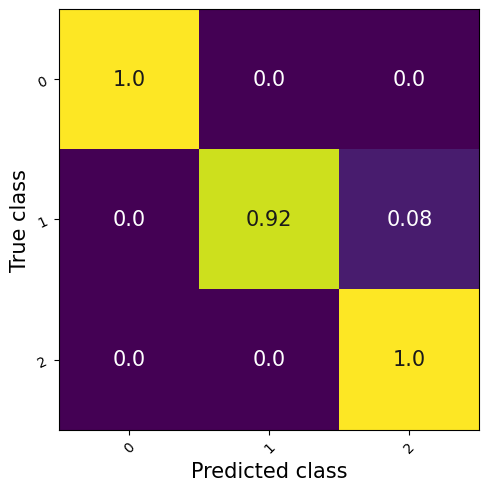

tensor([[1509,    0,    0],
        [   0,   12,    1],
        [   0,    0,   14]])
Macro F1-Score: 0.9752 ✨
perclass_f1scores: tensor([1.0000, 0.9600, 0.9655])
perclass_precision: tensor([1.0000, 1.0000, 0.9333])
perclass_recall: tensor([1.0000, 0.9231, 1.0000])
MAE overall: 0.6538 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.35714285714285715)} ✨
 === Currently Evaluating curr_test_idx: 147 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_norma

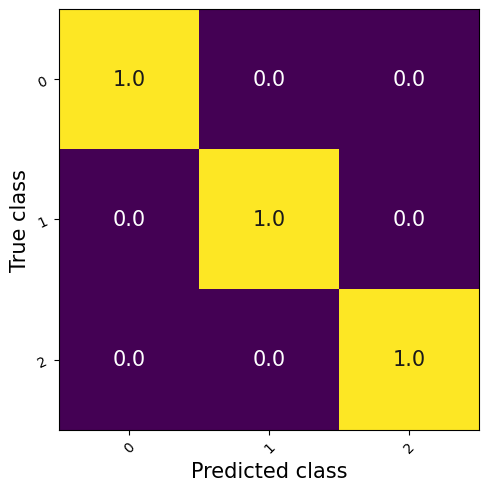

tensor([[1513,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.7391 ✨
MAE per_class: {1: np.float64(1.1818181818181819), 2: np.float64(0.3333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 148 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_02.npy
self.expan

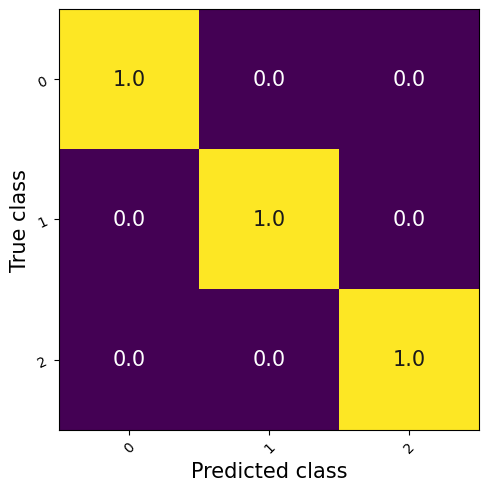

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.9565 ✨
MAE per_class: {1: np.float64(1.75), 2: np.float64(0.09090909090909091)} ✨
 === Currently Evaluating curr_test_idx: 149 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_02npy.npy
self.expand_labels 0

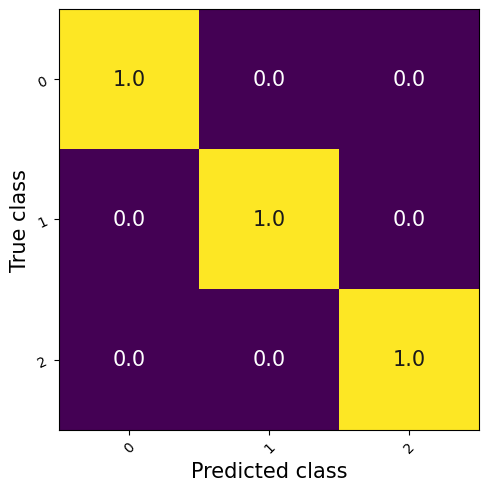

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.9565 ✨
MAE per_class: {1: np.float64(1.75), 2: np.float64(0.09090909090909091)} ✨
 === Currently Evaluating curr_test_idx: 150 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cr

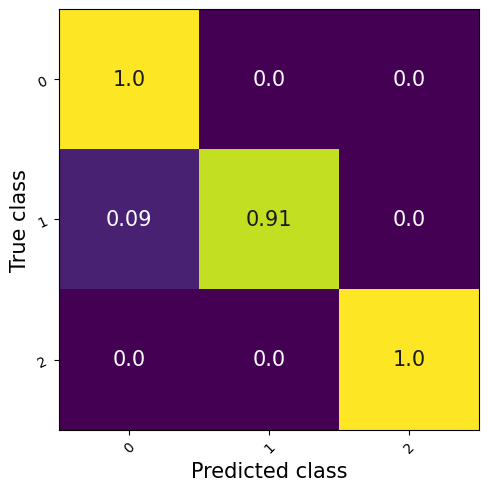

tensor([[1257,    1,    0],
        [   1,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9694 ✨
perclass_f1scores: tensor([0.9992, 0.9091, 1.0000])
perclass_precision: tensor([0.9992, 0.9091, 1.0000])
perclass_recall: tensor([0.9992, 0.9091, 1.0000])
MAE overall: 1.0000 ✨
MAE per_class: {1: np.float64(1.9090909090909092), 2: np.float64(0.09090909090909091)} ✨
 === Currently Evaluating curr_test_idx: 151 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelg

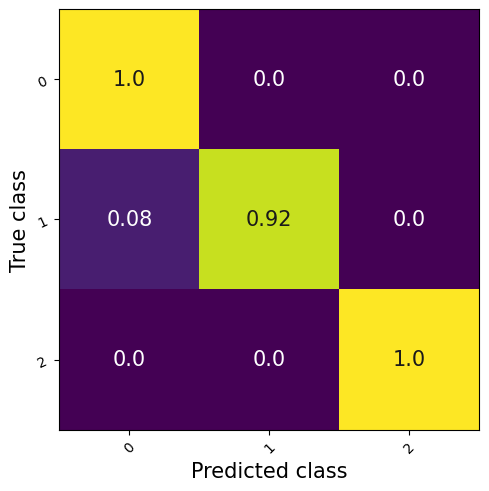

tensor([[1255,    1,    1],
        [   1,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9573 ✨
perclass_f1scores: tensor([0.9988, 0.9167, 0.9565])
perclass_precision: tensor([0.9992, 0.9167, 0.9167])
perclass_recall: tensor([0.9984, 0.9167, 1.0000])
MAE overall: 0.8696 ✨
MAE per_class: {1: np.float64(1.6666666666666667), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 152 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal

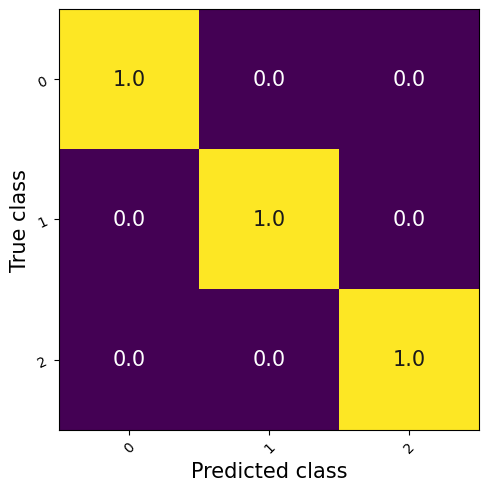

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6957 ✨
MAE per_class: {1: np.float64(1.3333333333333333), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 153 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropp

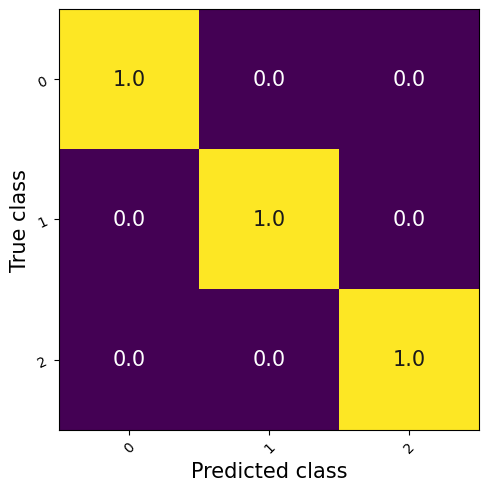

tensor([[1765,    0,    0],
        [   0,   13,    0],
        [   0,    0,   14]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6296 ✨
MAE per_class: {1: np.float64(0.9230769230769231), 2: np.float64(0.35714285714285715)} ✨
 === Currently Evaluating curr_test_idx: 154 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_02.npy
self.expan

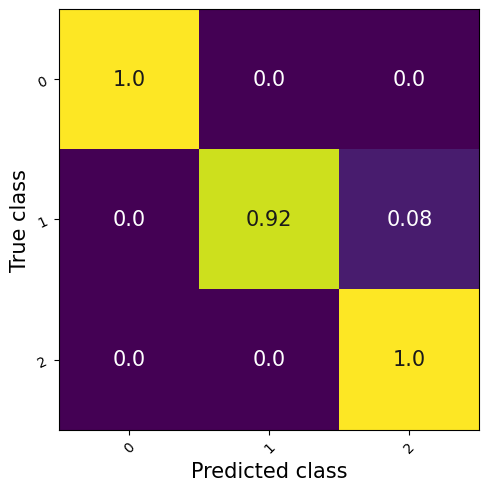

tensor([[1256,    0,    0],
        [   0,   12,    1],
        [   0,    0,   11]])
Macro F1-Score: 0.9722 ✨
perclass_f1scores: tensor([1.0000, 0.9600, 0.9565])
perclass_precision: tensor([1.0000, 1.0000, 0.9167])
perclass_recall: tensor([1.0000, 0.9231, 1.0000])
MAE overall: 0.7826 ✨
MAE per_class: {1: np.float64(1.25), 2: np.float64(0.2727272727272727)} ✨
 === Currently Evaluating curr_test_idx: 155 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal

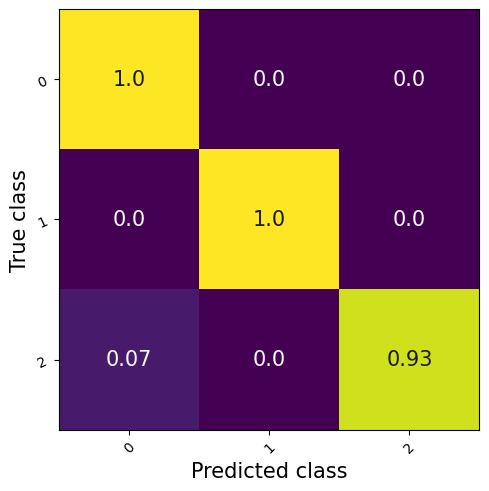

tensor([[1507,    0,    1],
        [   0,   14,    0],
        [   1,    0,   13]])
Macro F1-Score: 0.9760 ✨
perclass_f1scores: tensor([0.9993, 1.0000, 0.9286])
perclass_precision: tensor([0.9993, 1.0000, 0.9286])
perclass_recall: tensor([0.9993, 1.0000, 0.9286])
MAE overall: 0.9286 ✨
MAE per_class: {1: np.float64(1.1428571428571428), 2: np.float64(0.7142857142857143)} ✨
 === Currently Evaluating curr_test_idx: 156 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelgr

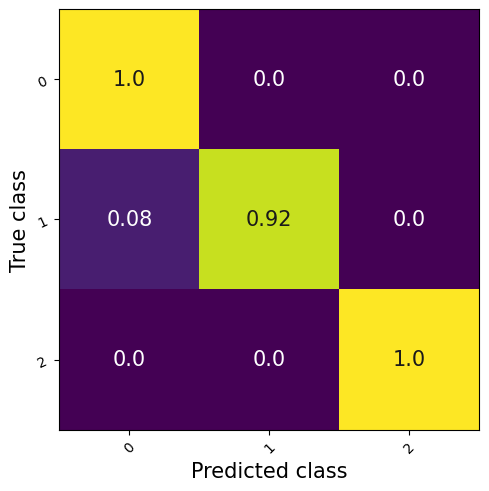

tensor([[1255,    0,    1],
        [   1,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9719 ✨
perclass_f1scores: tensor([0.9992, 0.9565, 0.9600])
perclass_precision: tensor([0.9992, 1.0000, 0.9231])
perclass_recall: tensor([0.9992, 0.9167, 1.0000])
MAE overall: 0.5652 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.16666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 157 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal

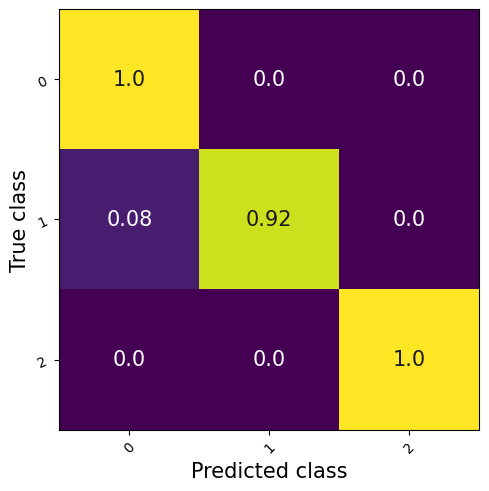

tensor([[1255,    0,    1],
        [   1,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9719 ✨
perclass_f1scores: tensor([0.9992, 0.9600, 0.9565])
perclass_precision: tensor([0.9992, 1.0000, 0.9167])
perclass_recall: tensor([0.9992, 0.9231, 1.0000])
MAE overall: 0.6957 ✨
MAE per_class: {1: np.float64(1.1666666666666667), 2: np.float64(0.18181818181818182)} ✨
 === Currently Evaluating curr_test_idx: 158 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelg

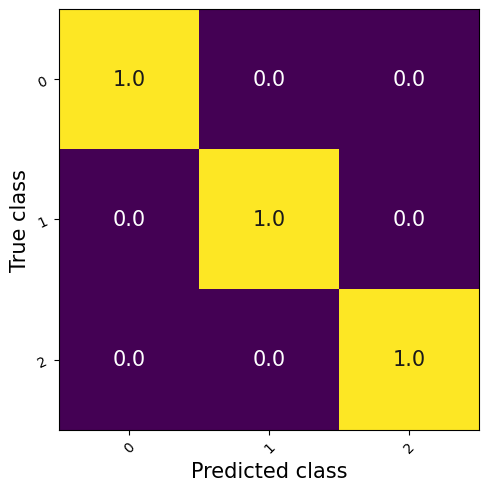

tensor([[1770,    1,    1],
        [   0,    9,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9678 ✨
perclass_f1scores: tensor([0.9994, 0.9474, 0.9565])
perclass_precision: tensor([1.0000, 0.9000, 0.9167])
perclass_recall: tensor([0.9989, 1.0000, 1.0000])
MAE overall: 0.5000 ✨
MAE per_class: {1: np.float64(0.7777777777777778), 2: np.float64(0.2727272727272727)} ✨
 === Currently Evaluating curr_test_idx: 159 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelgr

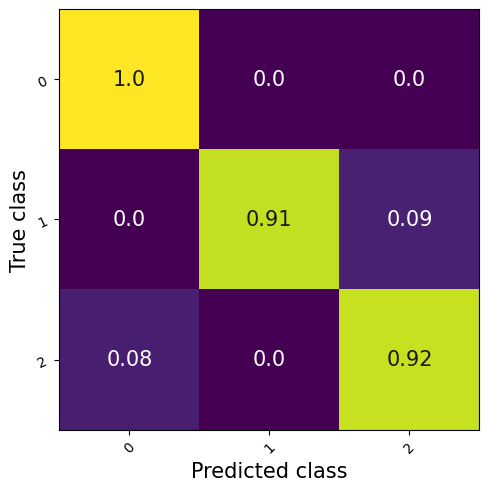

tensor([[1512,    0,    1],
        [   0,   10,    1],
        [   1,    0,   11]])
Macro F1-Score: 0.9439 ✨
perclass_f1scores: tensor([0.9993, 0.9524, 0.8800])
perclass_precision: tensor([0.9993, 1.0000, 0.8462])
perclass_recall: tensor([0.9993, 0.9091, 0.9167])
MAE overall: 0.5909 ✨
MAE per_class: {1: np.float64(0.8), 2: np.float64(0.4166666666666667)} ✨
 === Currently Evaluating curr_test_idx: 160 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal

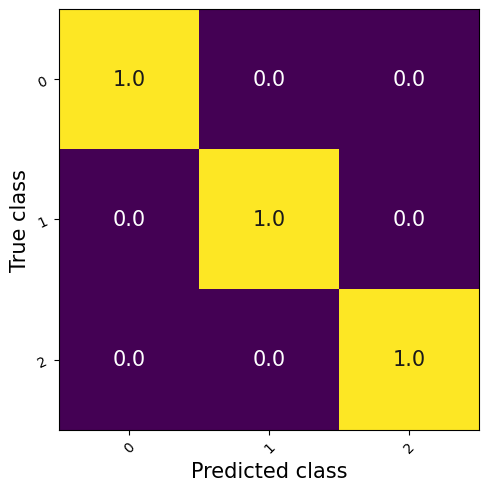

tensor([[1515,    0,    0],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.2381 ✨
MAE per_class: {1: np.float64(0.45454545454545453), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 161 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cro

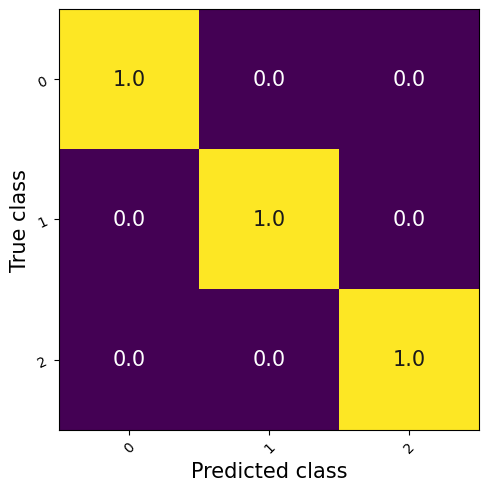

tensor([[1516,    0,    0],
        [   0,   10,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4500 ✨
MAE per_class: {1: np.float64(0.8), 2: np.float64(0.1)} ✨
 === Currently Evaluating curr_test_idx: 162 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape

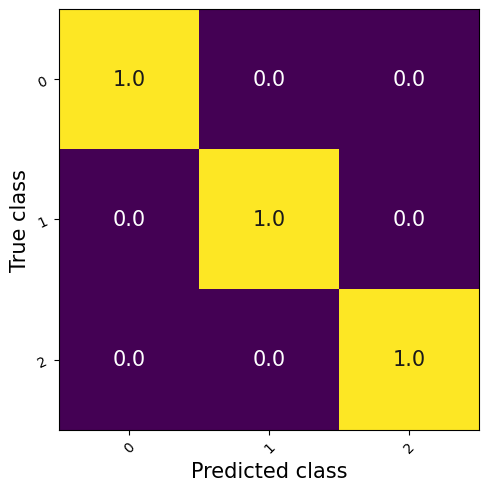

tensor([[1516,    0,    0],
        [   0,   10,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4500 ✨
MAE per_class: {1: np.float64(0.9), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 163 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape:

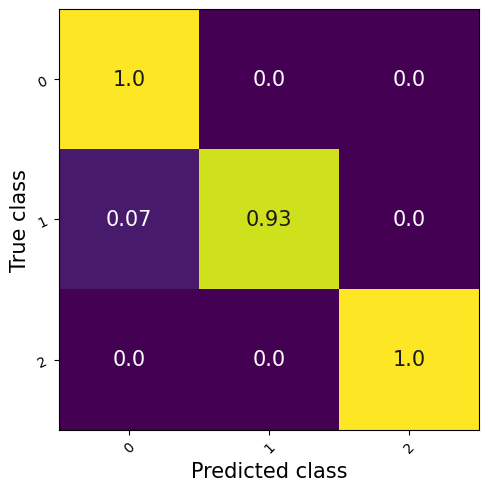

tensor([[2785,    1,    1],
        [   1,   13,    0],
        [   0,    0,   15]])
Macro F1-Score: 0.9653 ✨
perclass_f1scores: tensor([0.9995, 0.9286, 0.9677])
perclass_precision: tensor([0.9996, 0.9286, 0.9375])
perclass_recall: tensor([0.9993, 0.9286, 1.0000])
MAE overall: 1.1071 ✨
MAE per_class: {1: np.float64(1.9230769230769231), 2: np.float64(0.4)} ✨
 === Currently Evaluating curr_test_idx: 164 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_

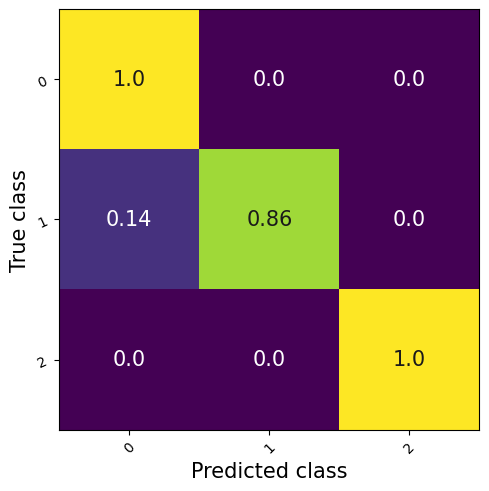

tensor([[1507,    2,    0],
        [   2,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9519 ✨
perclass_f1scores: tensor([0.9987, 0.8571, 1.0000])
perclass_precision: tensor([0.9987, 0.8571, 1.0000])
perclass_recall: tensor([0.9987, 0.8571, 1.0000])
MAE overall: 1.2593 ✨
MAE per_class: {1: np.float64(2.142857142857143), 2: np.float64(0.3076923076923077)} ✨
 === Currently Evaluating curr_test_idx: 165 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelgro

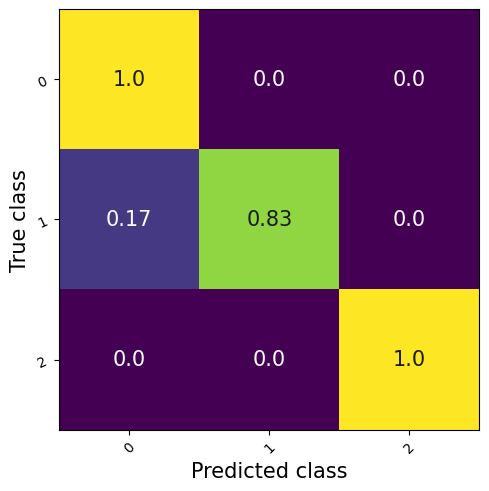

tensor([[1511,    0,    1],
        [   2,   10,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9560 ✨
perclass_f1scores: tensor([0.9990, 0.9091, 0.9600])
perclass_precision: tensor([0.9987, 1.0000, 0.9231])
perclass_recall: tensor([0.9993, 0.8333, 1.0000])
MAE overall: 0.9545 ✨
MAE per_class: {1: np.float64(1.8), 2: np.float64(0.25)} ✨
 === Currently Evaluating curr_test_idx: 166 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_04.npy
self

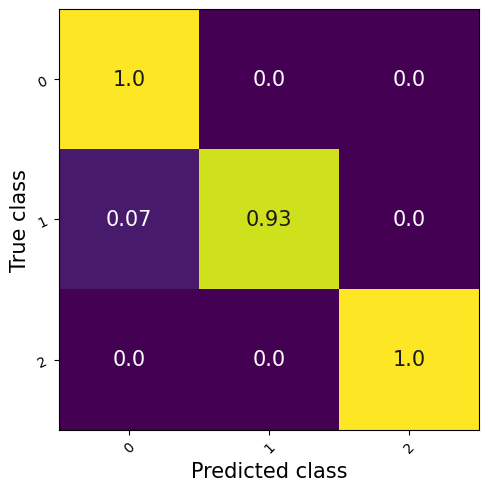

tensor([[1508,    1,    1],
        [   1,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9625 ✨
perclass_f1scores: tensor([0.9990, 0.9286, 0.9600])
perclass_precision: tensor([0.9993, 0.9286, 0.9231])
perclass_recall: tensor([0.9987, 0.9286, 1.0000])
MAE overall: 0.8000 ✨
MAE per_class: {1: np.float64(1.4615384615384615), 2: np.float64(0.08333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 167 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelg

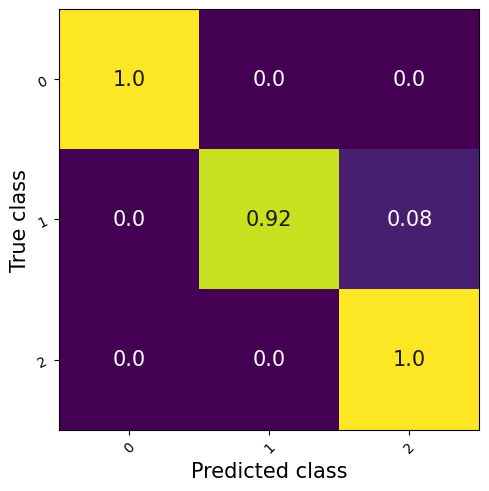

tensor([[2277,    2,    0],
        [   0,   11,    1],
        [   0,    0,   13]])
Macro F1-Score: 0.9475 ✨
perclass_f1scores: tensor([0.9996, 0.8800, 0.9630])
perclass_precision: tensor([1.0000, 0.8462, 0.9286])
perclass_recall: tensor([0.9991, 0.9167, 1.0000])
MAE overall: 1.1600 ✨
MAE per_class: {1: np.float64(2.0833333333333335), 2: np.float64(0.3076923076923077)} ✨
 === Currently Evaluating curr_test_idx: 168 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelgr

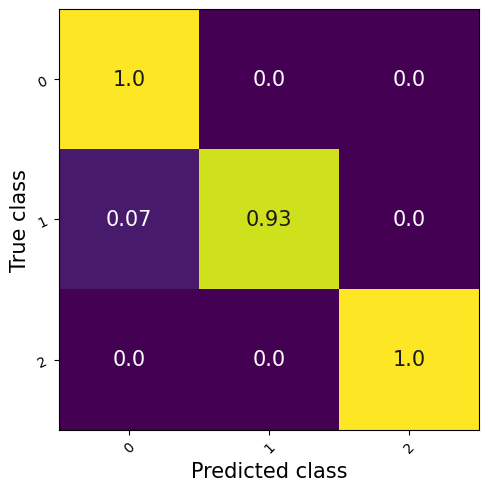

tensor([[1509,    0,    1],
        [   1,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9741 ✨
perclass_f1scores: tensor([0.9993, 0.9630, 0.9600])
perclass_precision: tensor([0.9993, 1.0000, 0.9231])
perclass_recall: tensor([0.9993, 0.9286, 1.0000])
MAE overall: 0.8400 ✨
MAE per_class: {1: np.float64(1.4615384615384615), 2: np.float64(0.16666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 169 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelg

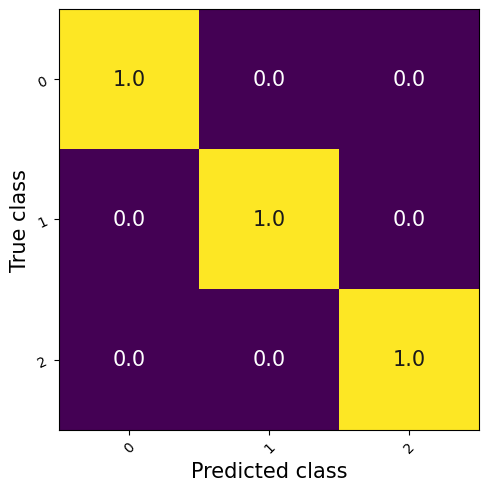

tensor([[2029,    0,    0],
        [   0,    9,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.7895 ✨
MAE per_class: {1: np.float64(0.7777777777777778), 2: np.float64(0.8)} ✨
 === Currently Evaluating curr_test_idx: 170 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
crop

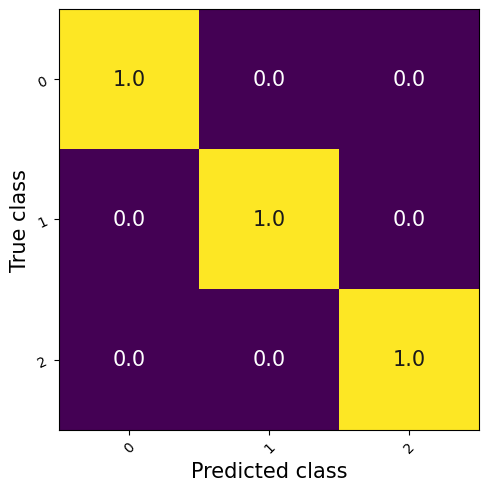

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6818 ✨
MAE per_class: {1: np.float64(0.9090909090909091), 2: np.float64(0.45454545454545453)} ✨
 === Currently Evaluating curr_test_idx: 171 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expa

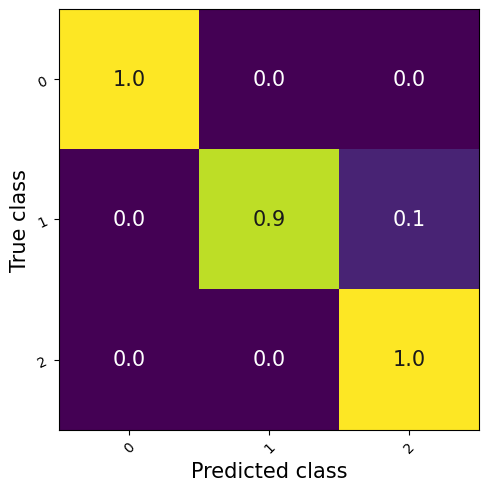

tensor([[1517,    0,    0],
        [   0,    9,    1],
        [   0,    0,    9]])
Macro F1-Score: 0.9649 ✨
perclass_f1scores: tensor([1.0000, 0.9474, 0.9474])
perclass_precision: tensor([1.0000, 1.0000, 0.9000])
perclass_recall: tensor([1.0000, 0.9000, 1.0000])
MAE overall: 0.7222 ✨
MAE per_class: {1: np.float64(0.8888888888888888), 2: np.float64(0.5555555555555556)} ✨
 === Currently Evaluating curr_test_idx: 172 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelgr

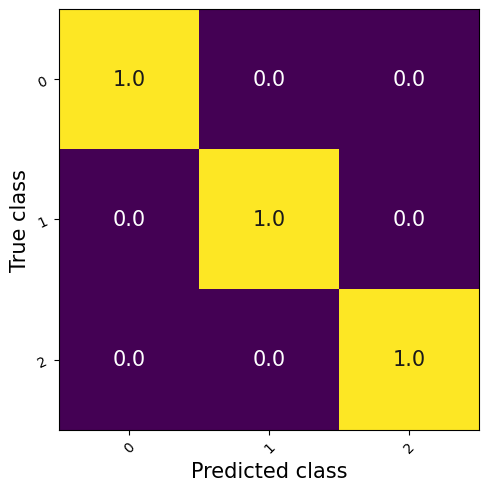

tensor([[1770,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6818 ✨
MAE per_class: {1: np.float64(0.7272727272727273), 2: np.float64(0.6363636363636364)} ✨
 === Currently Evaluating curr_test_idx: 173 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expan

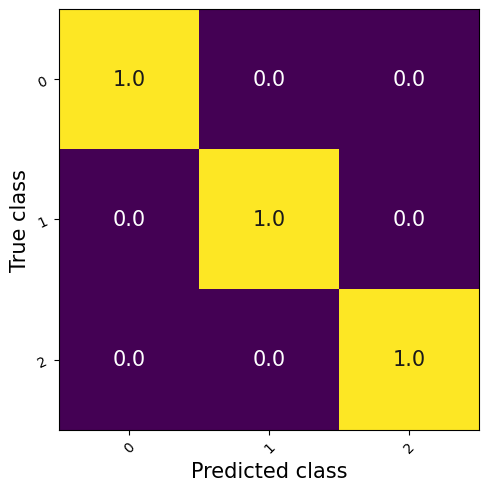

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.9091 ✨
MAE per_class: {1: np.float64(1.0909090909090908), 2: np.float64(0.7272727272727273)} ✨
 === Currently Evaluating curr_test_idx: 174 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_06.npy
self.expan

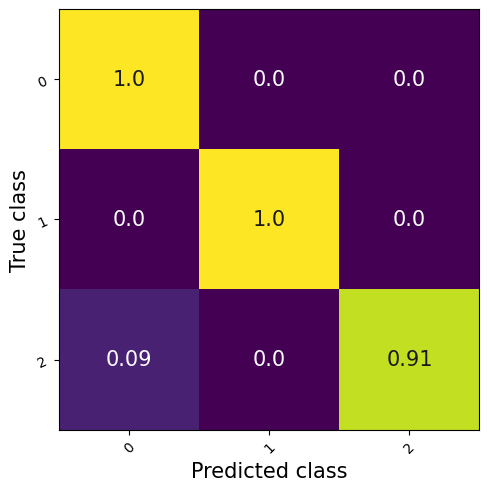

tensor([[1513,    0,    1],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9695 ✨
perclass_f1scores: tensor([0.9993, 1.0000, 0.9091])
perclass_precision: tensor([0.9993, 1.0000, 0.9091])
perclass_recall: tensor([0.9993, 1.0000, 0.9091])
MAE overall: 1.0000 ✨
MAE per_class: {1: np.float64(1.0909090909090908), 2: np.float64(0.9090909090909091)} ✨
 === Currently Evaluating curr_test_idx: 175 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelgr

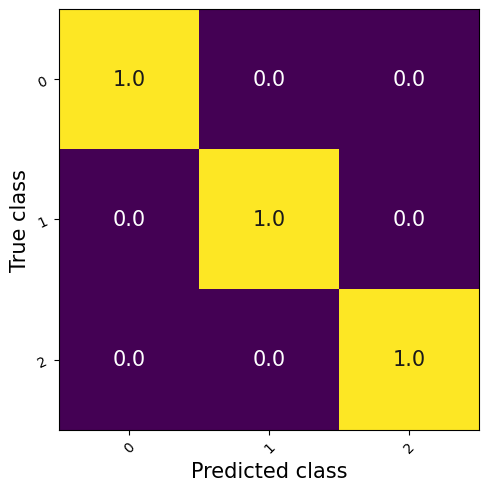

tensor([[2025,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.9130 ✨
MAE per_class: {1: np.float64(0.9090909090909091), 2: np.float64(0.9166666666666666)} ✨
 === Currently Evaluating curr_test_idx: 176 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand

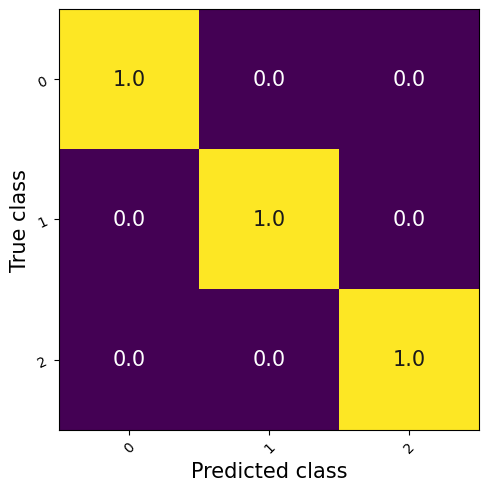

tensor([[2024,    0,    0],
        [   0,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.0417 ✨
MAE per_class: {1: np.float64(1.1666666666666667), 2: np.float64(0.9166666666666666)} ✨
 === Currently Evaluating curr_test_idx: 177 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand

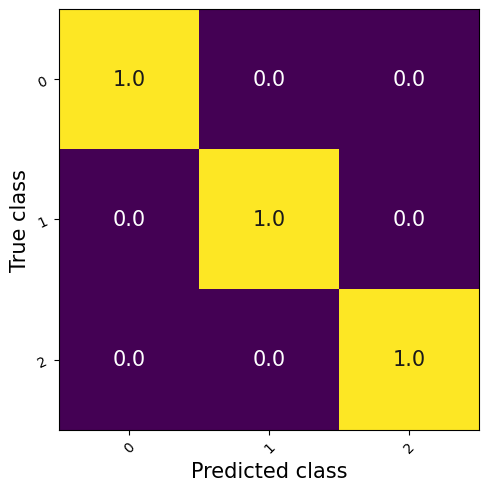

tensor([[2025,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 1.0870 ✨
MAE per_class: {1: np.float64(1.0909090909090908), 2: np.float64(1.0833333333333333)} ✨
 === Currently Evaluating curr_test_idx: 178 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_02.npy
self.expand

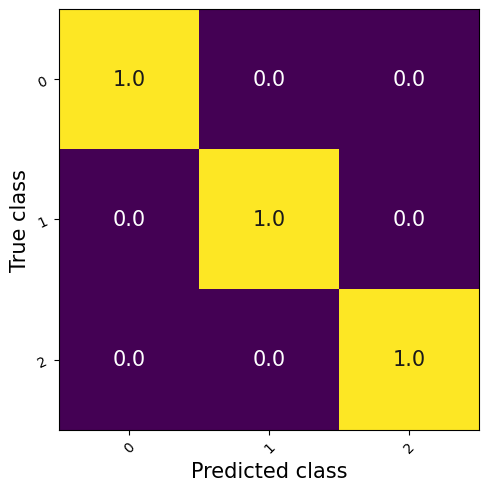

tensor([[1766,    0,    1],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9876 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9630])
perclass_precision: tensor([1.0000, 1.0000, 0.9286])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 1.0400 ✨
MAE per_class: {1: np.float64(1.0833333333333333), 2: np.float64(1.0)} ✨
 === Currently Evaluating curr_test_idx: 179 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_

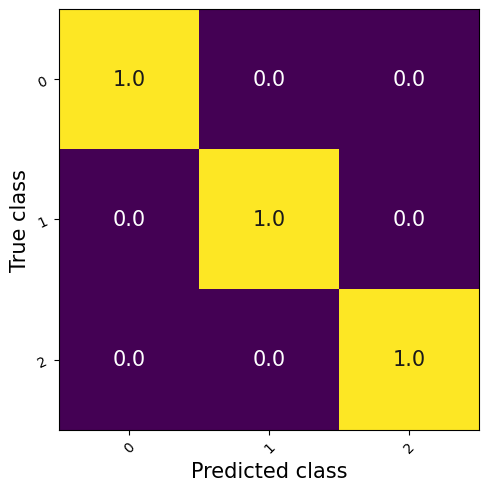

tensor([[1767,    0,    0],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.9600 ✨
MAE per_class: {1: np.float64(1.0833333333333333), 2: np.float64(0.8461538461538461)} ✨
 === Currently Evaluating curr_test_idx: 180 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_01.npy
self.expand

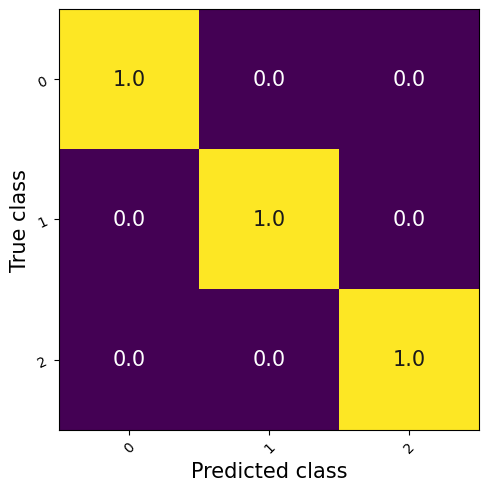

tensor([[2787,    0,    0],
        [   0,   14,    0],
        [   0,    0,   15]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6552 ✨
MAE per_class: {1: np.float64(0.8571428571428571), 2: np.float64(0.4666666666666667)} ✨
 === Currently Evaluating curr_test_idx: 181 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_02.npy
self.expand

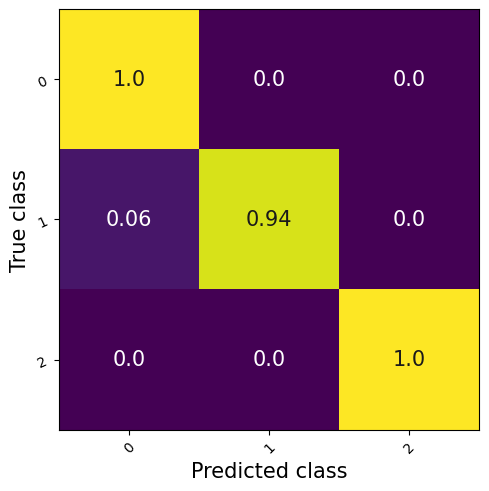

tensor([[2781,    0,    2],
        [   1,   16,    0],
        [   0,    0,   16]])
Macro F1-Score: 0.9701 ✨
perclass_f1scores: tensor([0.9995, 0.9697, 0.9412])
perclass_precision: tensor([0.9996, 1.0000, 0.8889])
perclass_recall: tensor([0.9993, 0.9412, 1.0000])
MAE overall: 0.6562 ✨
MAE per_class: {1: np.float64(0.875), 2: np.float64(0.4375)} ✨
 === Currently Evaluating curr_test_idx: 182 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_03.npy


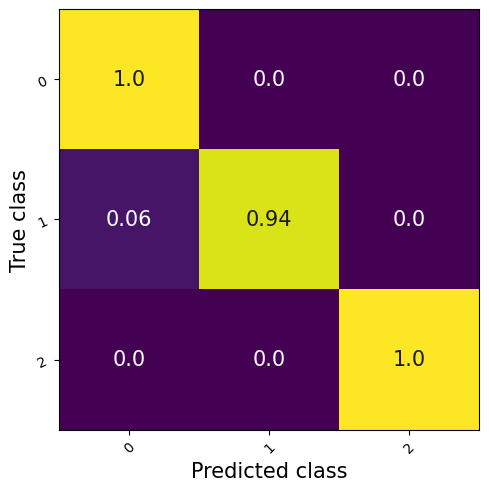

tensor([[2269,    0,    1],
        [   1,   17,    0],
        [   0,    0,   16]])
Macro F1-Score: 0.9802 ✨
perclass_f1scores: tensor([0.9996, 0.9714, 0.9697])
perclass_precision: tensor([0.9996, 1.0000, 0.9412])
perclass_recall: tensor([0.9996, 0.9444, 1.0000])
MAE overall: 0.5758 ✨
MAE per_class: {1: np.float64(0.8823529411764706), 2: np.float64(0.25)} ✨
 === Currently Evaluating curr_test_idx: 183 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal

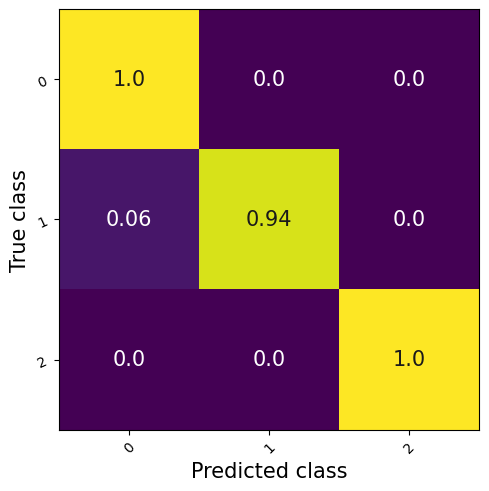

tensor([[2271,    0,    1],
        [   1,   16,    0],
        [   0,    0,   15]])
Macro F1-Score: 0.9790 ✨
perclass_f1scores: tensor([0.9996, 0.9697, 0.9677])
perclass_precision: tensor([0.9996, 1.0000, 0.9375])
perclass_recall: tensor([0.9996, 0.9412, 1.0000])
MAE overall: 0.8387 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.6666666666666666)} ✨
 === Currently Evaluating curr_test_idx: 184 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_

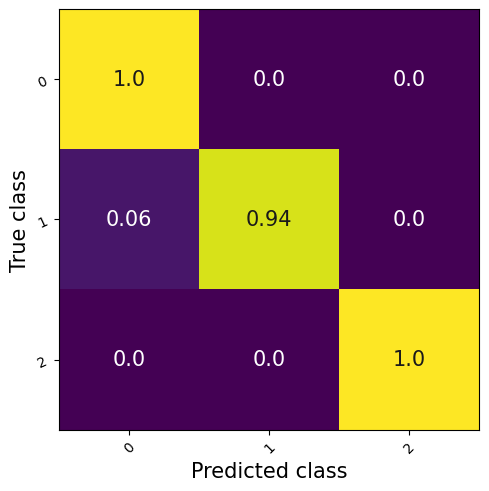

tensor([[2270,    0,    1],
        [   1,   16,    0],
        [   0,    0,   16]])
Macro F1-Score: 0.9797 ✨
perclass_f1scores: tensor([0.9996, 0.9697, 0.9697])
perclass_precision: tensor([0.9996, 1.0000, 0.9412])
perclass_recall: tensor([0.9996, 0.9412, 1.0000])
MAE overall: 0.6562 ✨
MAE per_class: {1: np.float64(0.9375), 2: np.float64(0.375)} ✨
 === Currently Evaluating curr_test_idx: 185 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_06.npy


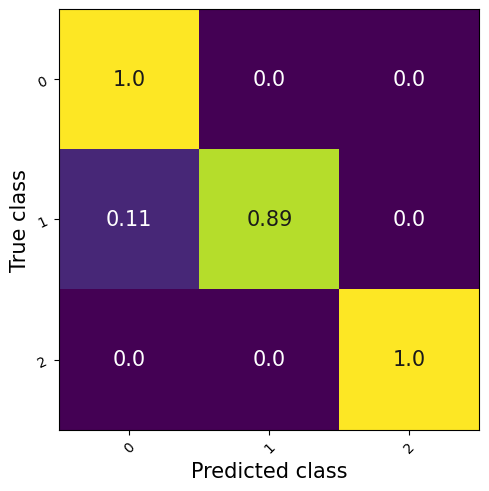

tensor([[2524,    0,    2],
        [   2,   16,    0],
        [   0,    0,   16]])
Macro F1-Score: 0.9605 ✨
perclass_f1scores: tensor([0.9992, 0.9412, 0.9412])
perclass_precision: tensor([0.9992, 1.0000, 0.8889])
perclass_recall: tensor([0.9992, 0.8889, 1.0000])
MAE overall: 0.7500 ✨
MAE per_class: {1: np.float64(0.9375), 2: np.float64(0.5625)} ✨
 === Currently Evaluating curr_test_idx: 186 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_normal_01_01.np

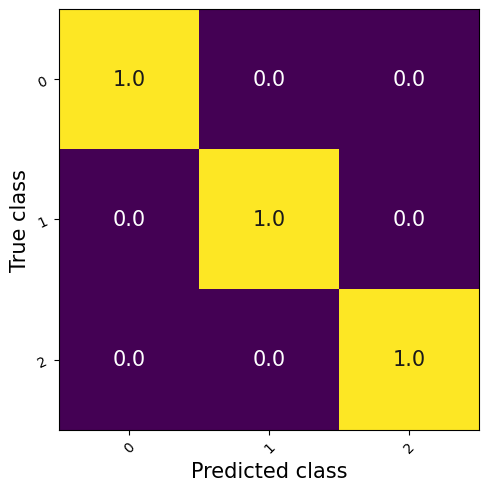

tensor([[3048,    1,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9855 ✨
perclass_f1scores: tensor([0.9998, 0.9565, 1.0000])
perclass_precision: tensor([1.0000, 0.9167, 1.0000])
perclass_recall: tensor([0.9997, 1.0000, 1.0000])
MAE overall: 0.5652 ✨
MAE per_class: {1: np.float64(0.9090909090909091), 2: np.float64(0.25)} ✨
 === Currently Evaluating curr_test_idx: 187 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_norma

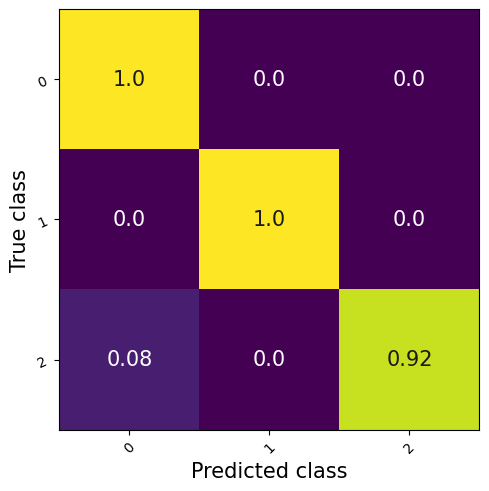

tensor([[1768,    0,    0],
        [   0,   12,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9565])
perclass_precision: tensor([0.9994, 1.0000, 1.0000])
perclass_recall: tensor([1.0000, 1.0000, 0.9167])
MAE overall: 0.3913 ✨
MAE per_class: {1: np.float64(0.75), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 188 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_normal_01_03.npy
sel

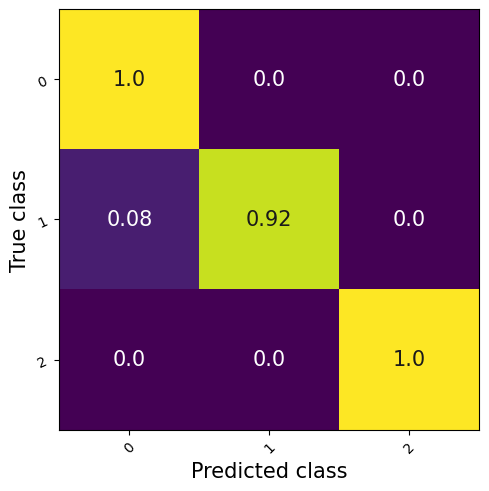

tensor([[1768,    0,    1],
        [   1,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9708 ✨
perclass_f1scores: tensor([0.9994, 0.9565, 0.9565])
perclass_precision: tensor([0.9994, 1.0000, 0.9167])
perclass_recall: tensor([0.9994, 0.9167, 1.0000])
MAE overall: 0.4091 ✨
MAE per_class: {1: np.float64(0.8181818181818182), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 189 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_normal

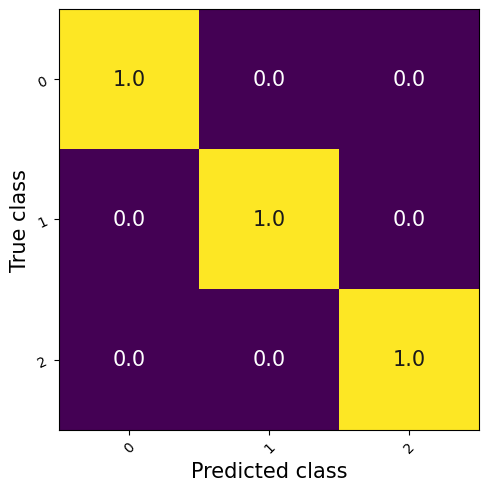

tensor([[1767,    0,    1],
        [   0,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9866 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9600])
perclass_precision: tensor([1.0000, 1.0000, 0.9231])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.4167 ✨
MAE per_class: {1: np.float64(0.75), 2: np.float64(0.08333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 190 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB27/02_24_2019/levelground/imu/levelground_ccw_norm

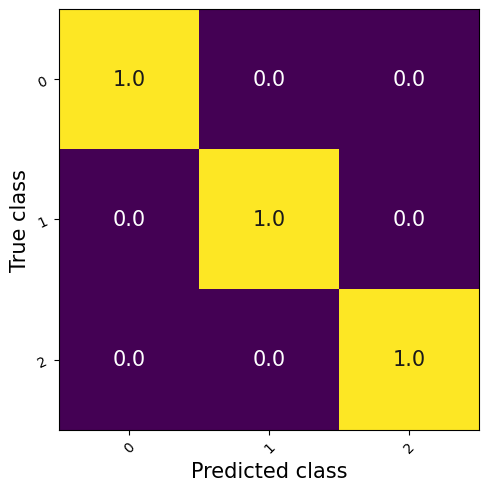

tensor([[2024,    0,    0],
        [   0,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3750 ✨
MAE per_class: {1: np.float64(0.6666666666666666), 2: np.float64(0.08333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 191 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal_01_01.npy
self.expa

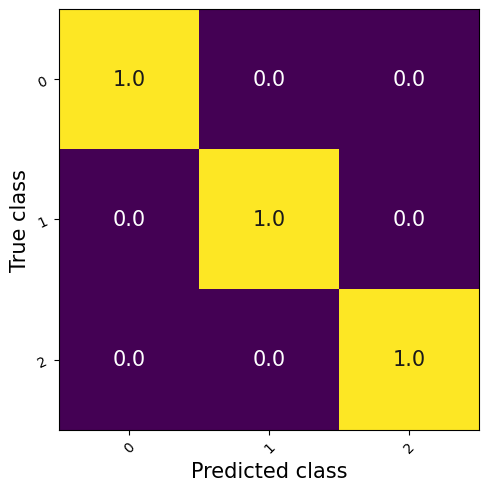

tensor([[2284,    1,    0],
        [   0,    9,    0],
        [   0,    0,   10]])
Macro F1-Score: 0.9824 ✨
perclass_f1scores: tensor([0.9998, 0.9474, 1.0000])
perclass_precision: tensor([1.0000, 0.9000, 1.0000])
perclass_recall: tensor([0.9996, 1.0000, 1.0000])
MAE overall: 0.4737 ✨
MAE per_class: {1: np.float64(0.5555555555555556), 2: np.float64(0.4)} ✨
 === Currently Evaluating curr_test_idx: 192 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal

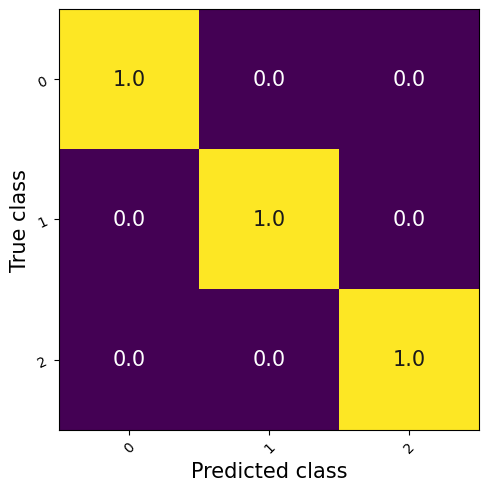

tensor([[1517,    0,    0],
        [   0,   10,    0],
        [   0,    0,    9]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5263 ✨
MAE per_class: {1: np.float64(0.7), 2: np.float64(0.3333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 193 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
crop

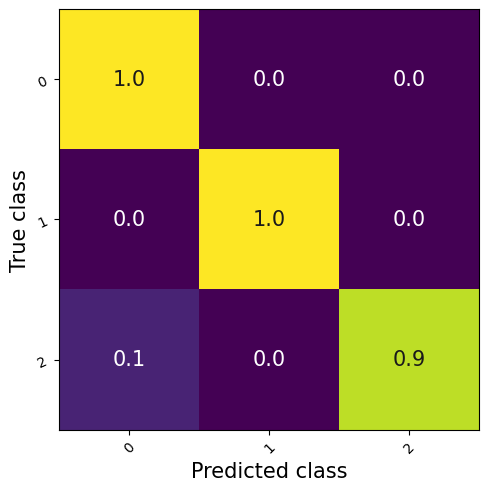

tensor([[1515,    1,    0],
        [   0,   10,    0],
        [   1,    0,    9]])
Macro F1-Score: 0.9664 ✨
perclass_f1scores: tensor([0.9993, 0.9524, 0.9474])
perclass_precision: tensor([0.9993, 0.9091, 1.0000])
perclass_recall: tensor([0.9993, 1.0000, 0.9000])
MAE overall: 0.6842 ✨
MAE per_class: {1: np.float64(1.3), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 194 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal_01_04.npy
self

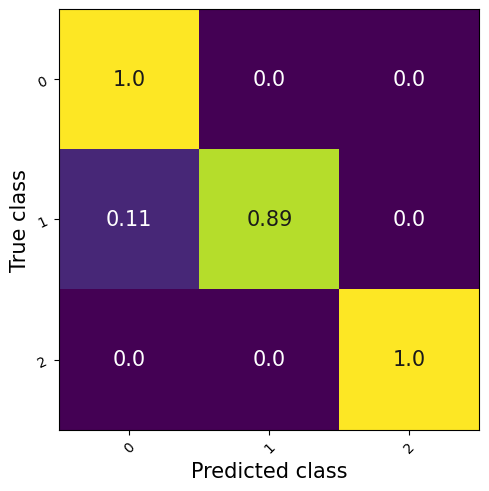

tensor([[1258,    2,    1],
        [   1,    8,    0],
        [   0,    0,   10]])
Macro F1-Score: 0.9310 ✨
perclass_f1scores: tensor([0.9984, 0.8421, 0.9524])
perclass_precision: tensor([0.9992, 0.8000, 0.9091])
perclass_recall: tensor([0.9976, 0.8889, 1.0000])
MAE overall: 1.0526 ✨
MAE per_class: {1: np.float64(1.5555555555555556), 2: np.float64(0.6)} ✨
 === Currently Evaluating curr_test_idx: 195 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal

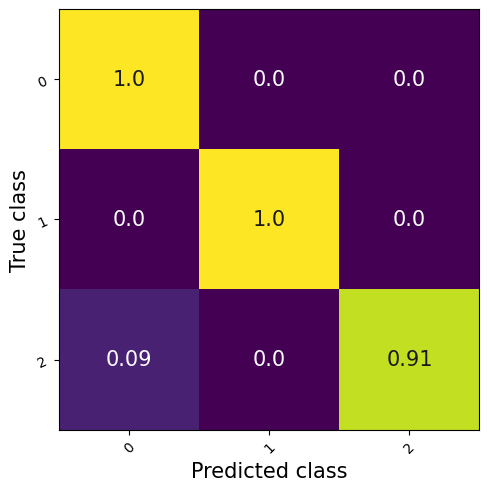

tensor([[1513,    1,    0],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9694 ✨
perclass_f1scores: tensor([0.9993, 0.9565, 0.9524])
perclass_precision: tensor([0.9993, 0.9167, 1.0000])
perclass_recall: tensor([0.9993, 1.0000, 0.9091])
MAE overall: 0.3333 ✨
MAE per_class: {1: np.float64(0.6363636363636364), 2: np.float64(0.0)} ✨
 === Currently Evaluating curr_test_idx: 196 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_ccw_normal

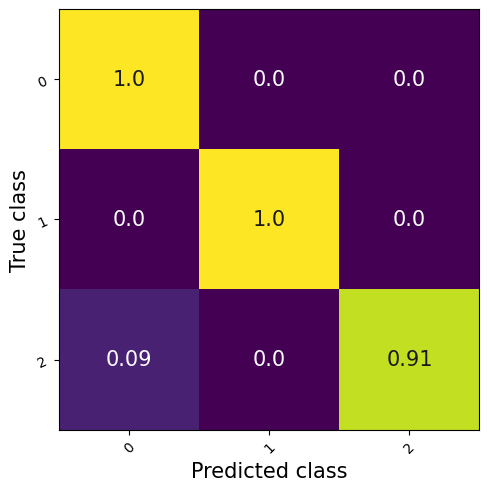

tensor([[1514,    0,    1],
        [   0,   10,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9695 ✨
perclass_f1scores: tensor([0.9993, 1.0000, 0.9091])
perclass_precision: tensor([0.9993, 1.0000, 0.9091])
perclass_recall: tensor([0.9993, 1.0000, 0.9091])
MAE overall: 0.6190 ✨
MAE per_class: {1: np.float64(0.8), 2: np.float64(0.45454545454545453)} ✨
 === Currently Evaluating curr_test_idx: 197 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal

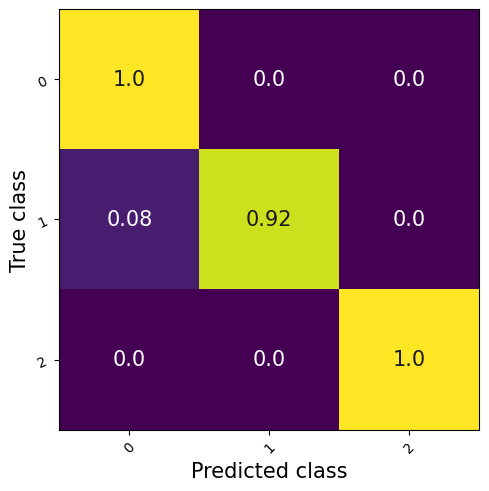

tensor([[1766,    0,    1],
        [   1,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9731 ✨
perclass_f1scores: tensor([0.9994, 0.9600, 0.9600])
perclass_precision: tensor([0.9994, 1.0000, 0.9231])
perclass_recall: tensor([0.9994, 0.9231, 1.0000])
MAE overall: 0.4167 ✨
MAE per_class: {1: np.float64(0.5833333333333334), 2: np.float64(0.25)} ✨
 === Currently Evaluating curr_test_idx: 198 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal

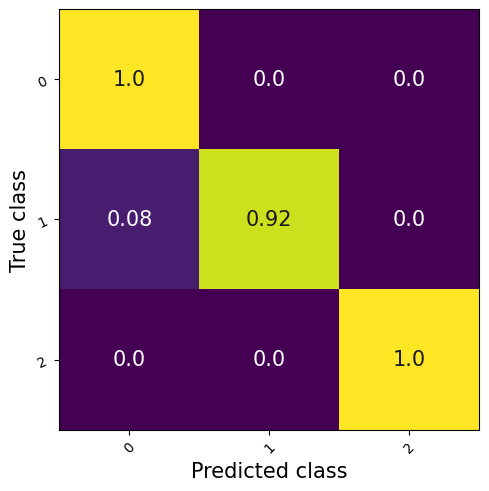

tensor([[1766,    0,    1],
        [   1,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9731 ✨
perclass_f1scores: tensor([0.9994, 0.9600, 0.9600])
perclass_precision: tensor([0.9994, 1.0000, 0.9231])
perclass_recall: tensor([0.9994, 0.9231, 1.0000])
MAE overall: 0.3333 ✨
MAE per_class: {1: np.float64(0.4166666666666667), 2: np.float64(0.25)} ✨
 === Currently Evaluating curr_test_idx: 199 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal

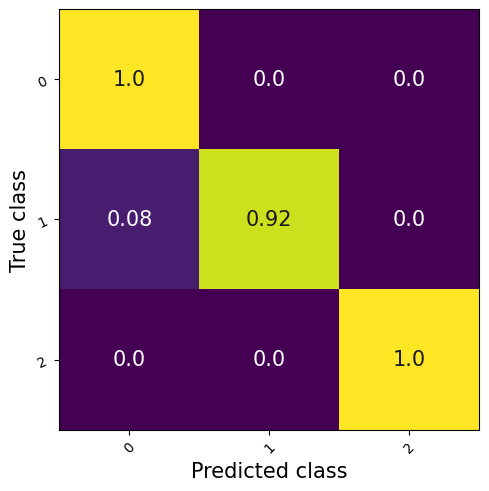

tensor([[2023,    0,    0],
        [   1,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9866 ✨
perclass_f1scores: tensor([0.9998, 0.9600, 1.0000])
perclass_precision: tensor([0.9995, 1.0000, 1.0000])
perclass_recall: tensor([1.0000, 0.9231, 1.0000])
MAE overall: 0.3750 ✨
MAE per_class: {1: np.float64(0.4166666666666667), 2: np.float64(0.3333333333333333)} ✨
 === Currently Evaluating curr_test_idx: 200 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelgr

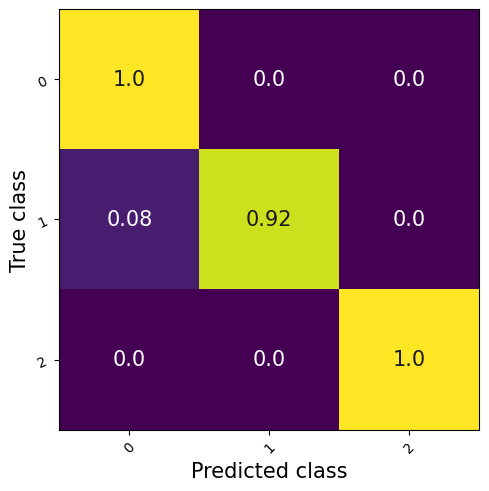

tensor([[2277,    0,    1],
        [   1,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9742 ✨
perclass_f1scores: tensor([0.9996, 0.9600, 0.9630])
perclass_precision: tensor([0.9996, 1.0000, 0.9286])
perclass_recall: tensor([0.9996, 0.9231, 1.0000])
MAE overall: 0.3600 ✨
MAE per_class: {1: np.float64(0.4166666666666667), 2: np.float64(0.3076923076923077)} ✨
 === Currently Evaluating curr_test_idx: 201 === 
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
train_stats: {'mean': array([-1.0756751 ,  0.33512822, -0.01121396,  0.01953449, -0.24521227,
        0.04542997]), 'std': array([0.29175586, 0.71446891, 2.33374116, 0.05091061, 0.31334949,
       0.1453549 ])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB30/03_09_2019/levelground/imu/levelgr

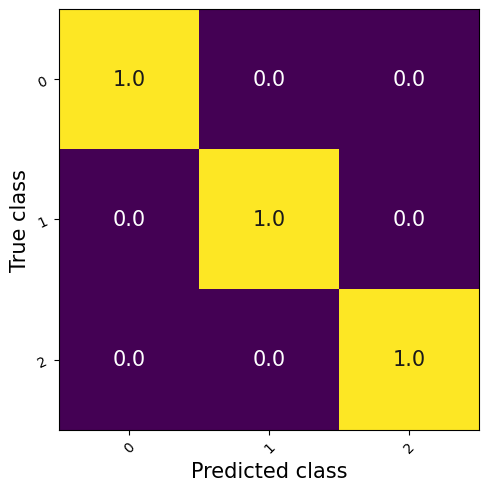

tensor([[2021,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5185 ✨
MAE per_class: {1: np.float64(0.6428571428571429), 2: np.float64(0.38461538461538464)} ✨


In [29]:
testset_f1_scores = []
testset_pc_f1_scores = []
testset_pc_precision = []
testset_pc_recall = []
testset_mae = []
testset_pc_mae = []
testset_cm = []
group_assigment = []

use_internal_train_stats = False
for curr_test_idx in cur_set_to_test.tolist():
    print(f" === Currently Evaluating curr_test_idx: {curr_test_idx} === ")
    if use_internal_train_stats:
        train_stat = {'mean': np.array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781, 0.86179046]), 
                      'std': np.array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,5.12151813]),}
        # global_mean = train_stat["mean"]
        # global_var = train_stat["std"]
    else:
        # global_mean = np.zeros(6)
        # global_var = np.ones(6)
        train_stat=None
        
    curr_datamodule = ExternalGaitDataModule(all_files, train_idx=[cur_set_to_test[-1]], val_idx=[cur_set_to_test[-2]], test_idx=[curr_test_idx], 
                                             batch_size=1024,
                                             window_size=256,
                                             step_size=256,
                                             expand_labels=0,
                                             zscale=True,
                                             zscale_stats=train_stat
                                            )
    curr_datamodule.setup("test")
    test_dataloader = curr_datamodule.test_dataloader()
    best_model.eval()
    pred=[]
    target=[]
    for sample_input, sample_target in test_dataloader:
        # data_sf = [pd.DataFrame(sample_input[i].numpy(), columns=['gyr_x', 'gyr_y', 'gyr_z', 'acc_x', 'acc_y', 'acc_z']) for i in range(sample_input.shape[0])]
        # data_sf = [rotate_dataset(i, R) for i in data_sf]
        # # data_sf = [sensor_alignment.align_dataset_to_gravity(i, 100) for i in data_sf]
        # sample_input = torch.tensor(np.stack(([i.values for i in data_sf]))).to(torch.float32)
        # print("old mean:", sample_input.mean([0, 1]))
        # sample_input = (sample_input-global_mean)/global_var
        # print("normalized mean:", sample_input.mean([0, 1]))
        sample_input = sample_input.to(device_)
        sample_target = sample_target.to(device_)
        print(sample_input.shape)
        with torch.no_grad():
            predicted_output = best_model(sample_input, sample_target, teacher_forcing_ratio=0.0)
        pred.append(predicted_output)
        target.append(sample_target)
    
    cur_pred = torch.concat(pred).reshape(-1, 3)
    cur_pred = torch.nn.functional.softmax(cur_pred, dim=-1).argmax(1)
    cur_target = torch.concat(target).reshape(-1)
    reshaped_input = sample_input.reshape(-1, sample_input.shape[-1]).cpu().numpy()
    print("Pred", cur_pred.shape, "Target", cur_target.shape)
    
    ALIGN_TOLERANCE = 3
    merged_preds = evaluate.merge_clustered_events(cur_pred.cpu().numpy())
    merged_targets = evaluate.merge_clustered_events(cur_target.cpu().numpy())
    aligned_preds = evaluate.align_events(merged_targets, merged_preds, ALIGN_TOLERANCE)
    
    
    cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
    cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    fig_, ax_ = cm.plot()
    plt.show()
    unnormalized_cm = MulticlassConfusionMatrix(num_classes=3, normalize=None)
    unnormalized_cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    ucm_tensor = unnormalized_cm.compute()
    testset_cm.append(ucm_tensor)
    print(ucm_tensor)
    
    num_classes = 3
    f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro')
    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    print(f"Macro F1-Score: {f1_macro_score.item():.4f} ✨")

    pc_f1score = MulticlassF1Score(num_classes=num_classes, average='none')
    perclass_f1scores = pc_f1score(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_f1_scores.append(perclass_f1scores)
    print(f"perclass_f1scores:", perclass_f1scores)

    pc_precision = MulticlassPrecision(num_classes=num_classes, average='none')
    perclass_precision = pc_precision(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_precision.append(perclass_precision)
    print(f"perclass_precision:", perclass_precision)

    pc_recall = MulticlassRecall(num_classes=num_classes, average='none')
    perclass_recall = pc_recall(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_recall.append(perclass_recall)
    print(f"perclass_recall:", perclass_recall)

    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    
    overall, per_class = calculate_gait_mae(merged_targets, merged_preds)
    overall = overall.item() if not np.isnan(overall) else np.nan
    print(f"MAE overall: {overall:.4f} ✨")
    print(f"MAE per_class: {per_class} ✨")
    testset_f1_scores.append(f1_macro_score)
    testset_mae.append(overall)
    testset_pc_mae.append(per_class)
    # group_assigment.append(grouping[curr_test_idx])
    # break

### 1.3 Plot results

In [79]:
from typing import Optional


def plot_journal_boxplot(
    df: pd.DataFrame, 
    x_col: str, 
    y_col: str, 
    title: str, 
    x_label: str, 
    y_label: str, 
    filename: Optional[str] = None
):
    """
    Generates a publication-ready Box Plot with an overlayed Strip Plot 
    following typical scientific journal standards (e.g., black and white, high resolution).

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        x_col (str): The name of the categorical column for the x-axis (e.g., 'variable').
        y_col (str): The name of the numerical column for the y-axis (e.g., 'value').
        title (str): The title of the plot.
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        filename (str, optional): The name of the file to save the plot. If None, the plot is shown.
    """
    # Set the overall aesthetic theme for scientific plots
    sns.set_theme(style="ticks", font_scale=1.8) 

    # Optimal figure size for single-column journal placement
    plt.figure(figsize=(8, 6))

    # --- Define Print-Friendly Black & White Style Properties ---
    # Properties for the box itself
    box_properties = {
        'facecolor': 'white',      # White fill 
        'edgecolor': 'black',      # Black outline for print clarity
        'linewidth': 1.5           # Thicker line
    }
    # Properties for the median, whiskers, and caps
    line_properties = {
        'color': 'black',          # All internal lines are black
        'linewidth': 1.5
    }

    # 1. Plot the Box Plot (The statistical summary layer)
    sns.boxplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        showfliers=False, # Outliers will be covered by the strip plot
        boxprops=box_properties,
        medianprops=line_properties,
        whiskerprops=line_properties,
        capprops=line_properties 
    )

    # 2. Overlay the Strip Plot (The individual data points layer)
    sns.stripplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        color='k',                 # Pure black points
        jitter=0.2,                # Controlled jitter to spread points
        size=5,                    # Clear visibility
        alpha=0.7
    )

    # --- Final Polish and Labeling ---
    # Removes the top and right spines
    sns.despine() 

    plt.title(title, fontsize=30) 
    plt.xlabel(x_label, fontsize=30)
    plt.ylabel(y_label, fontsize=28) 

    plt.tight_layout() # Prevents labels from being cut off

    # --- Save or Show Plot ---
    if filename:
        # Save with high DPI for publication quality (300 DPI is standard minimum)
        plt.savefig(filename, dpi=300)
        plt.close() # Close the figure to free memory
        print(f"Plot saved as '{filename}' with 300 DPI.")
    else:
        plt.show()

In [33]:
pc_mae_df = pd.DataFrame(testset_pc_mae) * 10.0
pc_mae_df.columns = ["IC", "FO"]
pc_mae_df = pc_mae_df.melt()
pc_mae_df.head() 

,variable,value
0,IC,35.000000
1,IC,14.166667
2,IC,18.181818
3,IC,11.818182
4,IC,20.909091


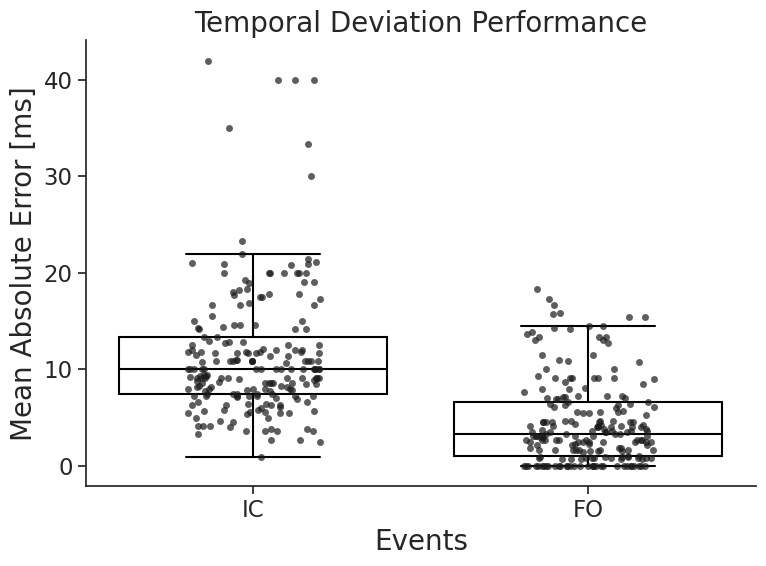

In [34]:
plot_journal_boxplot(pc_mae_df, x_col="variable", y_col="value", title="Temporal Deviation Performance", x_label="Events", y_label="Mean Absolute Error [ms]")

In [37]:
pc_f1_df = pd.DataFrame(torch.stack(testset_pc_f1_scores).numpy())
pc_f1_df.columns = ["NE", "IC", "TO"]
pc_f1_df = pc_f1_df.melt()
pc_f1_df = pc_f1_df[pc_f1_df.variable != "NE"]

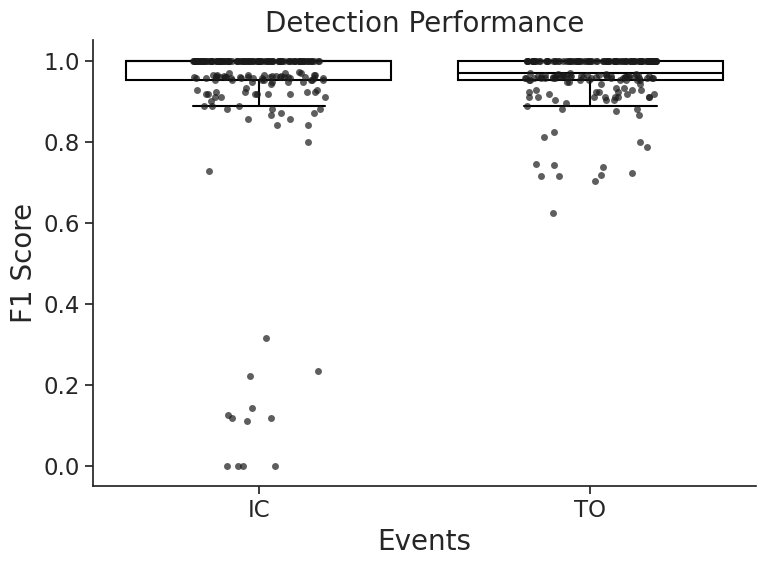

In [38]:
plot_journal_boxplot(pc_f1_df, x_col="variable", y_col="value", title="Detection Performance", x_label="Events", y_label="F1 Score")

### 2. Fine-tuning

### 2.1 Exp1: Fine tune last layer only

In [107]:
from sklearn.model_selection import KFold, train_test_split

In [109]:
subject_fpath = glob("/home/qivy00li/projects/gait_ml/data/processed/external_data1/*")
use_internal_train_stats = False
expand_labels = 2
unfreeze_all = False

In [110]:
model_fpath = "/home/qivy00li/projects/gait_ml/backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-10_15-13-18/checkpoints/model-epoch=97-val_f1score=0.88.ckpt"
device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
best_model = LitSeq2Seq.load_from_checkpoint(model_fpath).to(device_)
model = best_model.model

if unfreeze_all:
    # 1. Freeze all parameters in the model by default
    print("Un-freezing all model parameters for fine-tuning...")
    for param in model.parameters():
        param.requires_grad = True

else:
    # 1. Freeze all parameters in the model by default
    print("Freezing all model parameters for fine-tuning...")
    for param in model.parameters():
        param.requires_grad = False
    # 2. Unfreeze only the 'fc_out' layer
    # This assumes 'fc_out' is a direct attribute of your LitSeq2Seq model
    # (e.g., self.fc_out = nn.Linear(...))
    try:
        print("Unfreezing 'fc_out' layer parameters...")
        for param in model.fc_out.parameters():
            param.requires_grad = True
    except AttributeError:
        print("\n[Warning] Could not find 'model.fc_out'.")
        print("Please ensure your LitSeq2Seq class has an attribute 'fc_out'.")
        print("If your final layer is named differently, update this code.\n")
        # You might want to raise an error here if it's critical
        # raise
best_model.model = model

Freezing all model parameters for fine-tuning...
Unfreezing 'fc_out' layer parameters...


In [111]:
kf = KFold(
        n_splits=2,
        shuffle=True,
        random_state=config.general.random_state,
    )

for fold, (train_val_index, test_index) in enumerate(kf.split(np.arange(len(subject_fpath)))
    ):
    print(f"=============== FOLD {fold + 1}/{config.general.n_splits} ================")

    train_index, val_index, _, _ = train_test_split(
        train_val_index,
        train_val_index,
        test_size=0.25,
        random_state=1,
    )
    print("current train_index:", train_index)
    print("current val_index:", val_index)
    print("current test_index:", test_index)

    train_set_fpaths = []
    for i in np.array(subject_fpath)[train_index]:
        curr_files = glob(os.path.join(i, "**/levelground/imu/levelground_*_normal_*.npy"), recursive=True)
        train_set_fpaths += curr_files

    val_set_fpaths = []
    for i in np.array(subject_fpath)[val_index]:
        curr_var_files = glob(os.path.join(i, "**/levelground/imu/levelground_*_normal_*.npy"), recursive=True)
        val_set_fpaths += curr_var_files
    
    curr_train_val_fpaths = np.array(train_set_fpaths + val_set_fpaths)

    _idx = np.arange(len(curr_train_val_fpaths))
    train_fpath_idx = _idx[:len(train_set_fpaths)]
    val_fpath_idx = _idx[len(train_set_fpaths) + 1:]

    if use_internal_train_stats:
        train_stat = {'mean': np.array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781, 0.86179046]), 
                      'std': np.array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,5.12151813]),}
        # global_mean = train_stat["mean"]
        # global_var = train_stat["std"]
    else:
        # global_mean = np.zeros(6)
        # global_var = np.ones(6)
        train_stat=None
        
    curr_datamodule = ExternalGaitDataModule(curr_train_val_fpaths, 
                                             train_idx=train_fpath_idx, 
                                             val_idx=val_fpath_idx, 
                                             batch_size=1024,
                                             window_size=256,
                                             step_size=256,
                                             expand_labels=expand_labels,
                                             zscale=True,
                                             zscale_stats=train_stat
                                            )
    
    current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    run_name = f"ExternalDataset1FinetuneExp6-Fold{fold + 1}-GRU-expandlabel{expand_labels}_{current_time}"
    # wandb_logger = WandbLogger(
    #     project=config.general.project_name,
    #     name=run_name,
    #     log_model="all",
    # )
    checkpoint_callback = ModelCheckpoint(
            monitor=config.training.monitor_metric,
            mode=config.training.monitor_mode,
            save_top_k=config.training.save_top_k,
            dirpath=f"{config.general.project_name}/{run_name}/checkpoints/",
            filename="model-{epoch:02d}-{val_f1score:.2f}",
        )
    lr_monitor = LearningRateMonitor(logging_interval="step")

    trainer = pl.Trainer(
        max_epochs=config.training.num_epochs,
        accelerator=config.training.accelerator,
        devices=config.training.devices,
        log_every_n_steps=config.training.log_every_n_steps,
        check_val_every_n_epoch=config.training.check_val_every_n_epoch,
        enable_progress_bar=True,
        # logger=wandb_logger,
        callbacks=[checkpoint_callback, lr_monitor],
    )

    print("Starting training...")
    # Train the model
    curr_datamodule.setup("train")
    trainer.fit(
        best_model,
        train_dataloaders=curr_datamodule.train_dataloader(),
        val_dataloaders=curr_datamodule.val_dataloader(),
    )
    print("\nTraining complete!")
    wandb.finish()
    break

=============== FOLD 1/5 ================
current train_index: [ 9  2  7  4 14 19 10]
current val_index: [ 6 20 12]
current test_index: [ 0  1  3  5  8 11 13 15 16 17 18]


/beegfs1/home/qivy00li/projects/gait_ml/.venv/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /beegfs1/home/qivy00li/projects/gait_ml/.venv/lib/py ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting training...
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 2
=== Updating labels with expansion...
cropped_array shape: (8, 256, 7)
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 2
=== Updating labels with expansion...
cropped_array shape: (6, 256, 7)
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 2
=== Updating labels with expansion...
cropped_array shape: (6, 256, 7)
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 2
=== Updating labels with expansion...
cropped_array shape: (6, 256, 7)
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB15/11_07_2018/levelground/imu/levelgrou

/beegfs1/home/qivy00li/projects/gait_ml/.venv/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /beegfs1/home/qivy00li/projects/gait_ml/.venv/lib/py ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/beegfs1/home/qivy00li/projects/gait_ml/.venv/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:378: Found unsupported keys in the optimizer configuration: {'interval', 'frequency', 'strict'}

  | Name          | Type                      | Params | Mode 
--------------------------------------------------------------------
0 | model         | Seq2Seq                   | 39.0 K | train
1 | criterion     | CrossEntropyLoss          | 0      | train
2 | val_precision | MulticlassPrecision       | 0      | train
3 | val_recall    | MulticlassRecall          | 0      | train
4 |

Sanity Checking DataLoader 0:   0%|                    | 0/1 [00:00<?, ?it/s]
 tensor([[45048,  1856,  2073],
        [ 2529,     1,     1],
        [ 2508,     0,     0]], device='cuda:0') 

Epoch 0: 100%|█| 1/1 [00:00<00:00, 27.08it/s, v_num=12, train_loss_step=1.180
Validation: |                                          | 0/? [00:00<?, ?it/s]
Validation: |                                          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|                         | 0/1 [00:00<?, ?it/s]
 tensor([[45029,  1868,  2080],
        [ 2529,     1,     1],
        [ 2508,     0,     0]], device='cuda:0') 


Validation DataLoader 0: 100%|█████████████████| 1/1 [00:00<00:00, 53.97it/s]
Epoch 1: 100%|█| 1/1 [00:00<00:00,  8.20it/s, v_num=12, train_loss_step=1.170
Validation: |                                          | 0/? [00:00<?, ?it/s]
Validation: |                                          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|                         | 0/1 [00:00<?

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 249: 100%|█| 1/1 [00:00<00:00,  2.66it/s, v_num=12, train_loss_step=0.3

Training complete!


### 2.2 Evalaute the model

In [112]:
test_set_fpaths = []
for i in np.array(subject_fpath)[test_index]:
    curr_test_files = glob(os.path.join(i, "**/levelground/imu/levelground_*_normal_*.npy"), recursive=True)
    test_set_fpaths += curr_test_files
test_set_fpaths

['/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_01_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_02_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_03_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_04_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_05_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_01_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_02_01.npy',
 '/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/level

In [113]:
# curr_train_val_fpaths = np.array(train_set_fpaths + val_set_fpaths)
# _idx = np.arange(len(curr_train_val_fpaths))
# train_fpath_idx = _idx[:len(train_set_fpaths)]
# val_fpath_idx = _idx[len(train_set_fpaths) + 1:]

In [218]:
# # Zero shot
# model_fpath = "../backpain/ZscaledRerunExp4-Fold1-GRU-expandlabel2_2025-11-10_15-13-18/checkpoints/model-epoch=97-val_f1score=0.88.ckpt"

# # Fintune last layer
# model_fpath = "../notebooks/backpain/ExternalDataset1FinetuneExp6-Fold1-GRU-expandlabel2_2025-11-17_14-28-39/checkpoints/model-epoch=249-val_f1score=0.32.ckpt"

# Fintune all layers
model_fpath = "../notebooks/backpain/ExternalDataset1FinetuneExp5-Fold1-GRU-expandlabel2_2025-11-17_13-26-17/checkpoints/model-epoch=247-val_f1score=0.98.ckpt"

print("Evaluating model:", model_fpath)
device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
best_model = LitSeq2Seq.load_from_checkpoint(model_fpath).to(device_)

Evaluating model: ../notebooks/backpain/ExternalDataset1FinetuneExp5-Fold1-GRU-expandlabel2_2025-11-17_13-26-17/checkpoints/model-epoch=247-val_f1score=0.98.ckpt


train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


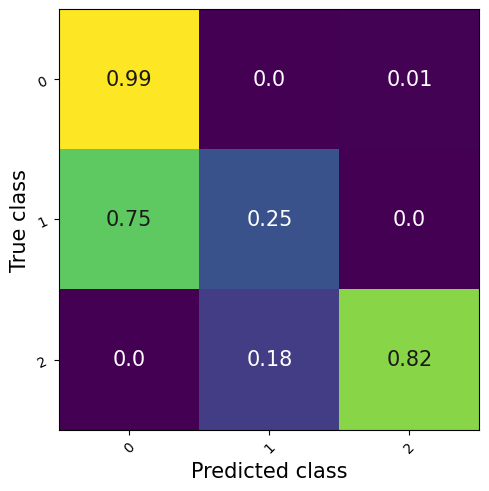

tensor([[1760,    0,    9],
        [   9,    3,    0],
        [   0,    2,    9]])
Macro F1-Score: 0.6562 ✨
perclass_f1scores: tensor([0.9949, 0.3529, 0.6207])
perclass_precision: tensor([0.9949, 0.6000, 0.5000])
perclass_recall: tensor([0.9949, 0.2500, 0.8182])
MAE overall: 0.5000 ✨
MAE per_class: {1: np.float64(1.6666666666666667), 2: np.float64(0.1111111111111111)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


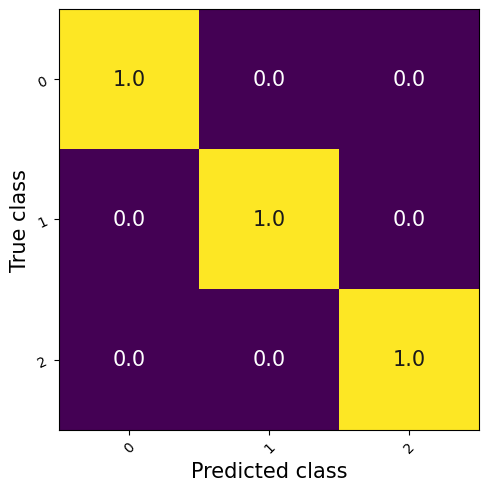

tensor([[1769,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3913 ✨
MAE per_class: {1: np.float64(0.6666666666666666), 2: np.float64(0.09090909090909091)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_03_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


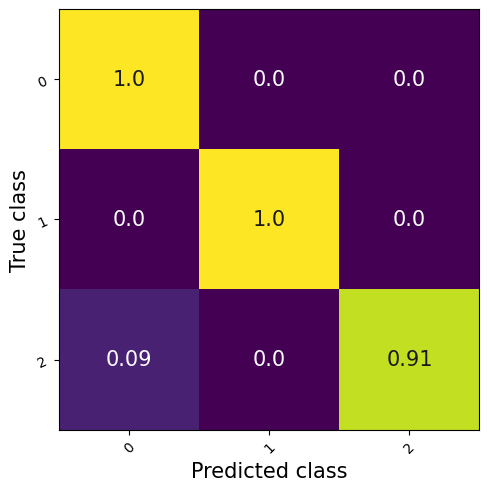

tensor([[1768,    0,    2],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9562 ✨
perclass_f1scores: tensor([0.9992, 1.0000, 0.8696])
perclass_precision: tensor([0.9994, 1.0000, 0.8333])
perclass_recall: tensor([0.9989, 1.0000, 0.9091])
MAE overall: 0.2381 ✨
MAE per_class: {1: np.float64(0.36363636363636365), 2: np.float64(0.1)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_04_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


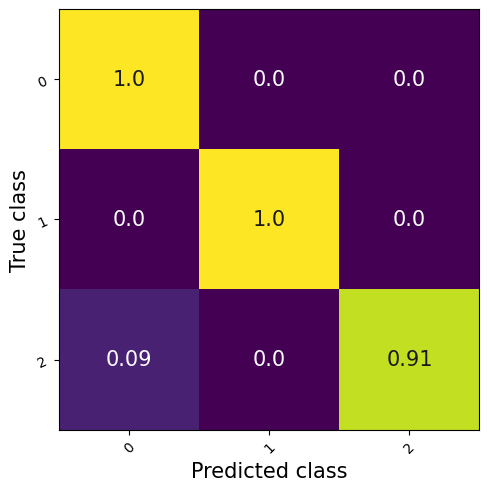

tensor([[1513,    1,    0],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9694 ✨
perclass_f1scores: tensor([0.9993, 0.9565, 0.9524])
perclass_precision: tensor([0.9993, 0.9167, 1.0000])
perclass_recall: tensor([0.9993, 1.0000, 0.9091])
MAE overall: 0.0952 ✨
MAE per_class: {1: np.float64(0.18181818181818182), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_ccw_normal_05_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


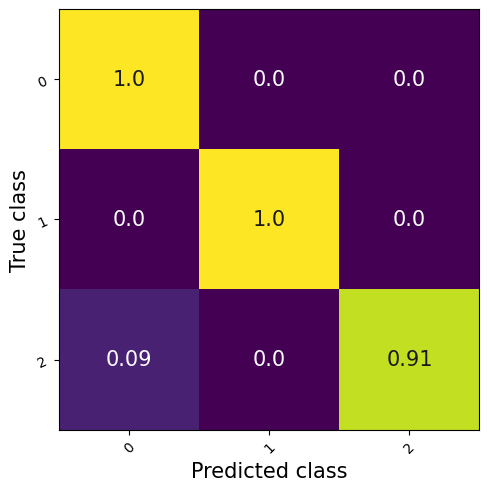

tensor([[1512,    0,    2],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9562 ✨
perclass_f1scores: tensor([0.9990, 1.0000, 0.8696])
perclass_precision: tensor([0.9993, 1.0000, 0.8333])
perclass_recall: tensor([0.9987, 1.0000, 0.9091])
MAE overall: 0.2381 ✨
MAE per_class: {1: np.float64(0.36363636363636365), 2: np.float64(0.1)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


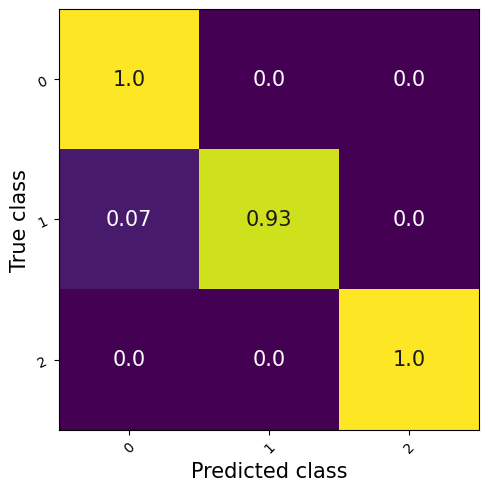

tensor([[1764,    0,    1],
        [   1,   13,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9751 ✨
perclass_f1scores: tensor([0.9994, 0.9630, 0.9630])
perclass_precision: tensor([0.9994, 1.0000, 0.9286])
perclass_recall: tensor([0.9994, 0.9286, 1.0000])
MAE overall: 0.3846 ✨
MAE per_class: {1: np.float64(0.15384615384615385), 2: np.float64(0.6153846153846154)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


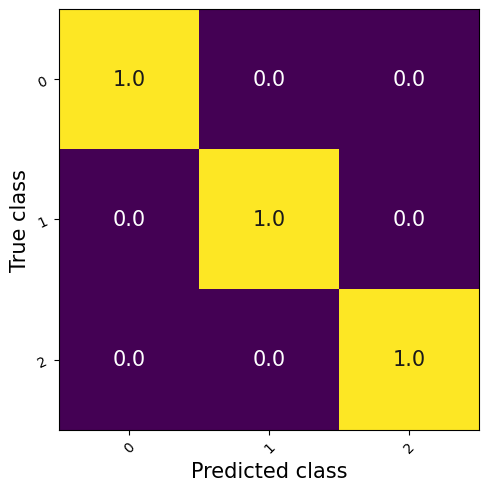

tensor([[1766,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3077 ✨
MAE per_class: {1: np.float64(0.14285714285714285), 2: np.float64(0.5)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_03_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


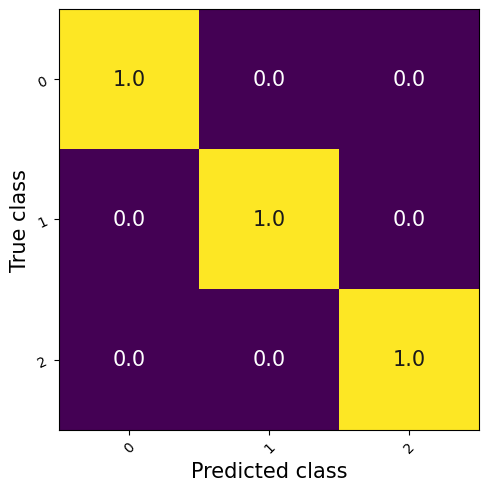

tensor([[1765,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.2222 ✨
MAE per_class: {1: np.float64(0.14285714285714285), 2: np.float64(0.3076923076923077)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_04_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


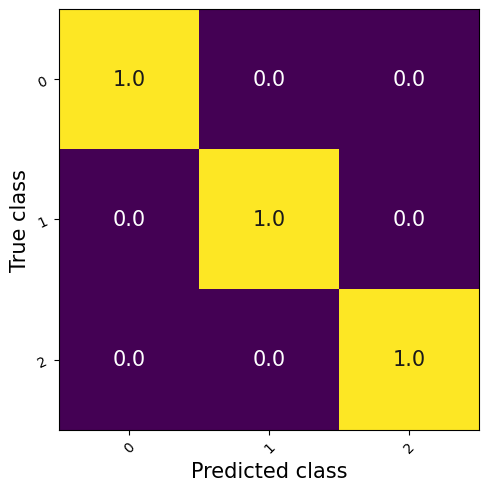

tensor([[1763,    1,    0],
        [   0,   15,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9892 ✨
perclass_f1scores: tensor([0.9997, 0.9677, 1.0000])
perclass_precision: tensor([1.0000, 0.9375, 1.0000])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.3571 ✨
MAE per_class: {1: np.float64(0.4), 2: np.float64(0.3076923076923077)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB06/10_09_18/levelground/imu/levelground_cw_normal_05_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


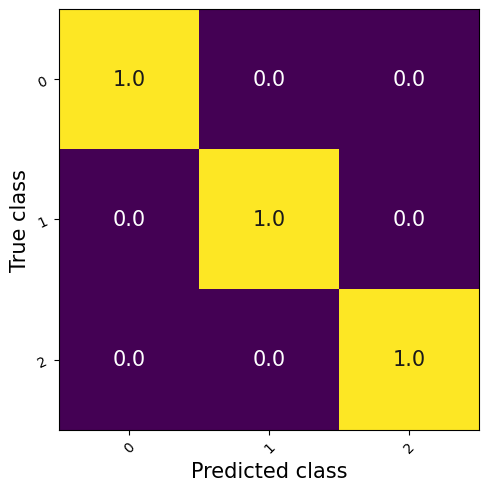

tensor([[1765,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4444 ✨
MAE per_class: {1: np.float64(0.21428571428571427), 2: np.float64(0.6923076923076923)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


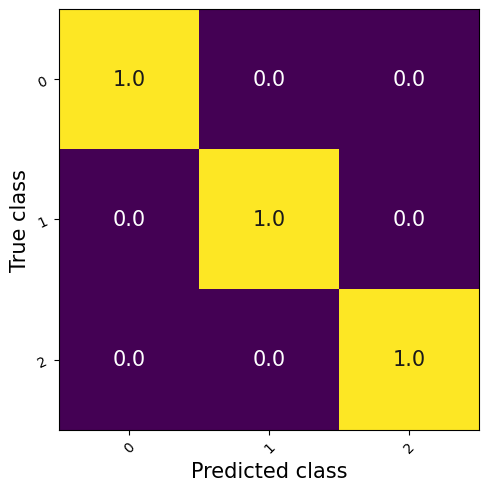

tensor([[2282,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0000 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


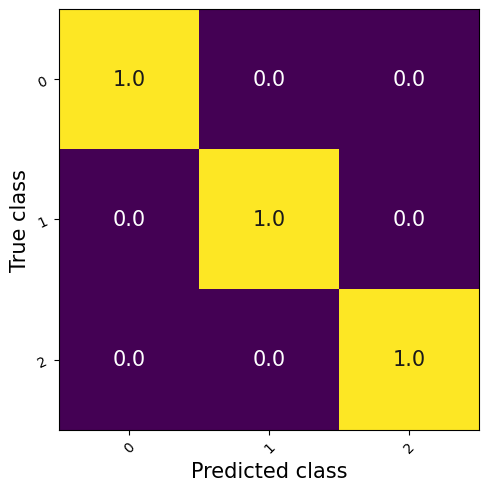

tensor([[2026,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0455 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


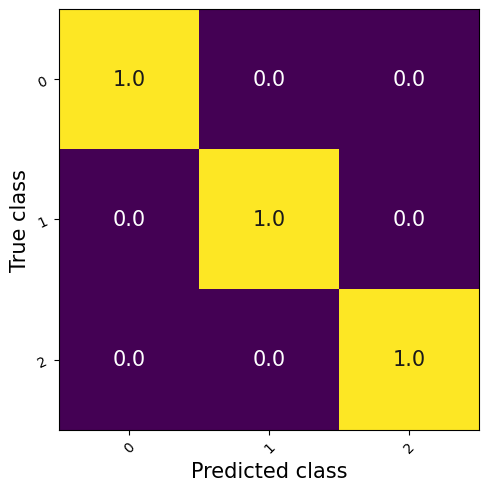

tensor([[2025,    1,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9998, 0.9565, 1.0000])
perclass_precision: tensor([1.0000, 0.9167, 1.0000])
perclass_recall: tensor([0.9995, 1.0000, 1.0000])
MAE overall: 0.3182 ✨
MAE per_class: {1: np.float64(0.2727272727272727), 2: np.float64(0.36363636363636365)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


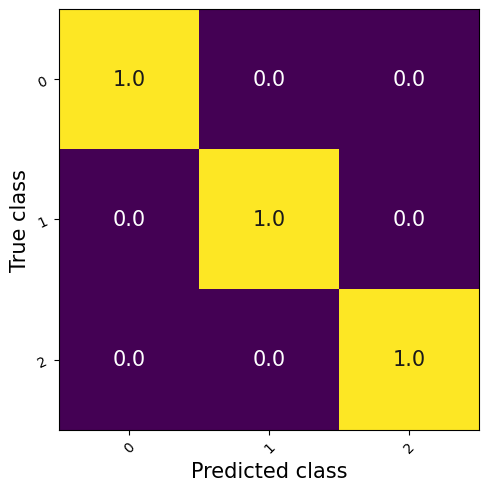

tensor([[2795,    0,    0],
        [   0,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3333 ✨
MAE per_class: {1: np.float64(0.2), 2: np.float64(0.45454545454545453)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_ccw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


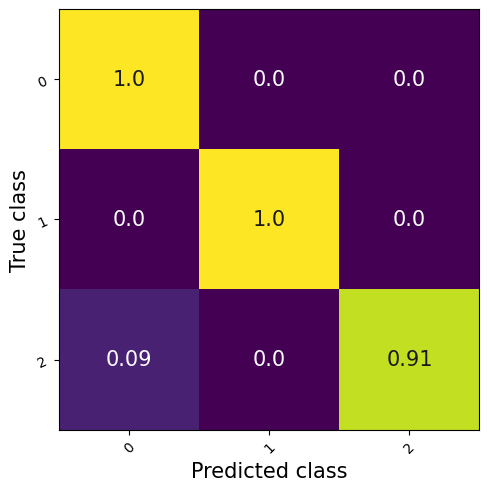

tensor([[2025,    0,    1],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9695 ✨
perclass_f1scores: tensor([0.9995, 1.0000, 0.9091])
perclass_precision: tensor([0.9995, 1.0000, 0.9091])
perclass_recall: tensor([0.9995, 1.0000, 0.9091])
MAE overall: 0.0476 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


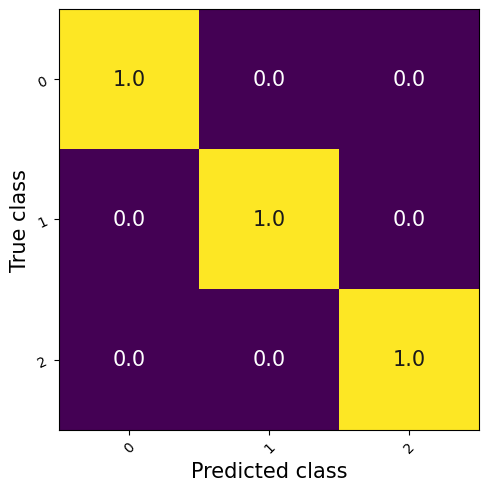

tensor([[2533,    0,    0],
        [   0,   13,    0],
        [   0,    0,   14]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1111 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.21428571428571427)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


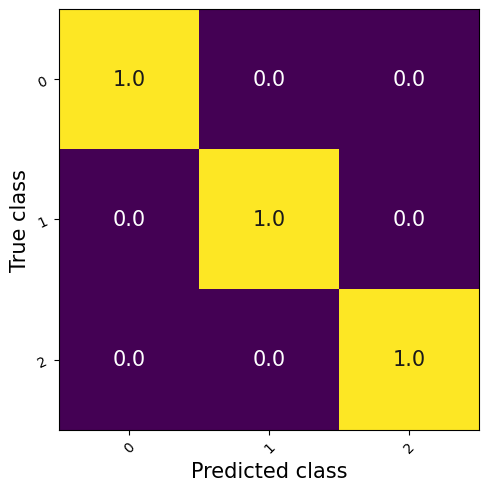

tensor([[2275,    0,    0],
        [   0,   15,    0],
        [   0,    0,   14]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0345 ✨
MAE per_class: {1: np.float64(0.06666666666666667), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


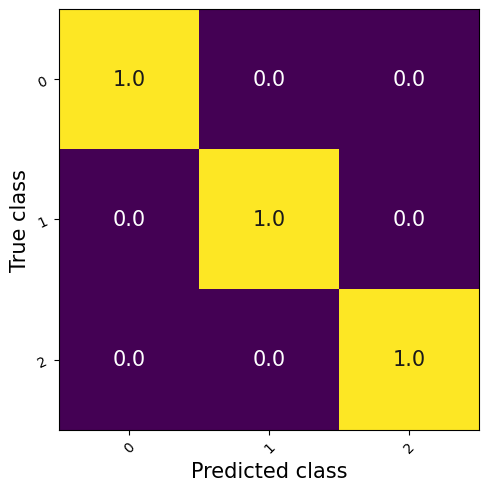

tensor([[2530,    0,    0],
        [   0,   15,    0],
        [   0,    0,   15]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0333 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.06666666666666667)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


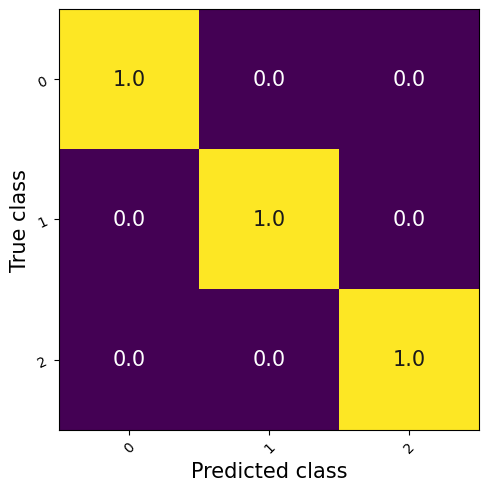

tensor([[2276,    0,    0],
        [   0,   15,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1071 ✨
MAE per_class: {1: np.float64(0.2), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB07/10_14_18/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


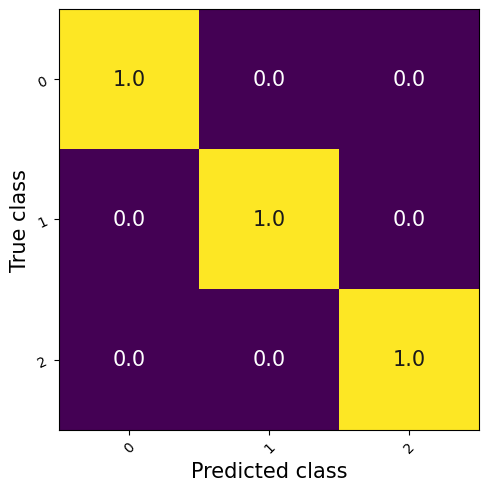

tensor([[2276,    0,    0],
        [   0,   15,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1071 ✨
MAE per_class: {1: np.float64(0.2), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


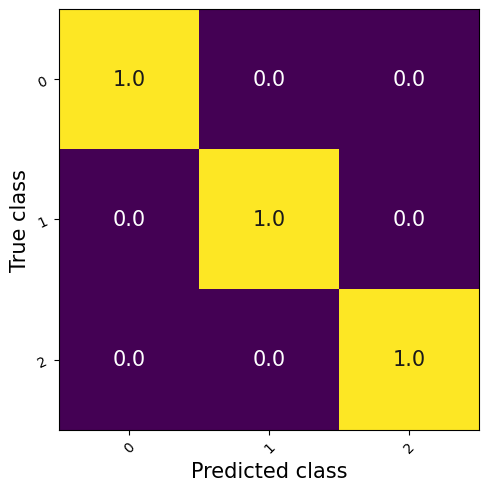

tensor([[2279,    0,    0],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6000 ✨
MAE per_class: {1: np.float64(0.8333333333333334), 2: np.float64(0.38461538461538464)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


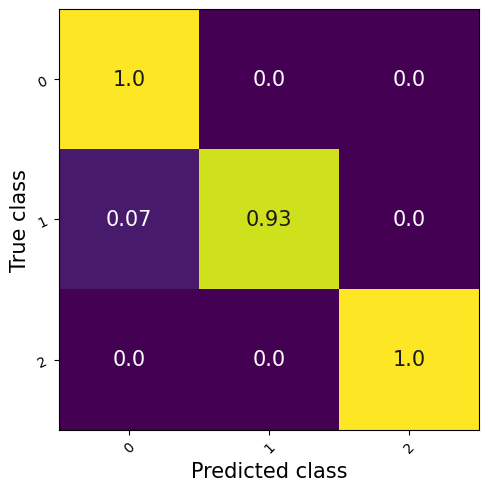

tensor([[2020,    0,    1],
        [   1,   13,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9751 ✨
perclass_f1scores: tensor([0.9995, 0.9630, 0.9630])
perclass_precision: tensor([0.9995, 1.0000, 0.9286])
perclass_recall: tensor([0.9995, 0.9286, 1.0000])
MAE overall: 0.3846 ✨
MAE per_class: {1: np.float64(0.7692307692307693), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


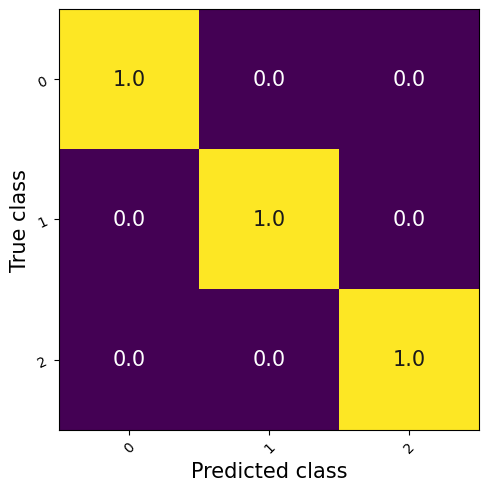

tensor([[1766,    0,    0],
        [   0,   13,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3462 ✨
MAE per_class: {1: np.float64(0.6923076923076923), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


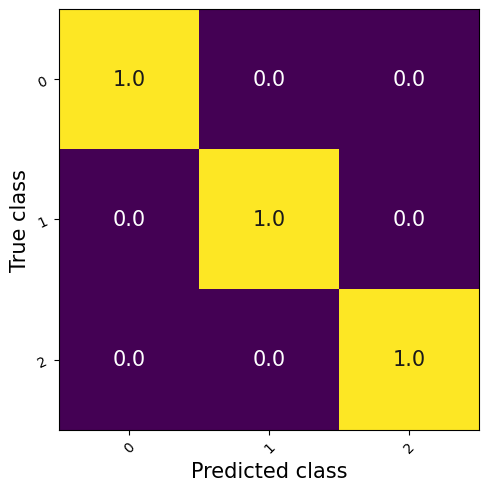

tensor([[1766,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3846 ✨
MAE per_class: {1: np.float64(0.7142857142857143), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


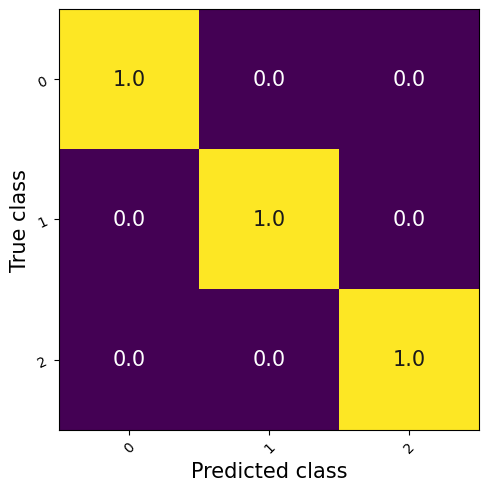

tensor([[2021,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4444 ✨
MAE per_class: {1: np.float64(0.7857142857142857), 2: np.float64(0.07692307692307693)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


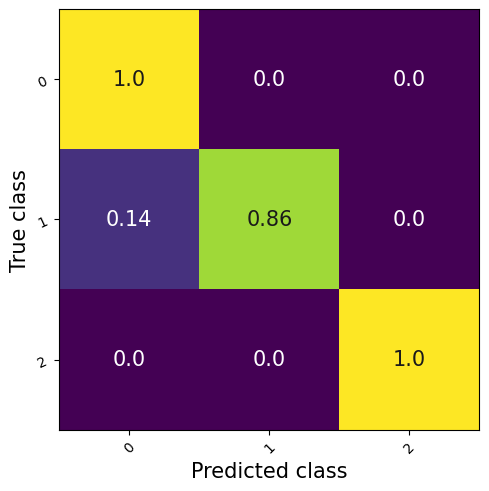

tensor([[1762,    0,    2],
        [   2,   12,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9518 ✨
perclass_f1scores: tensor([0.9989, 0.9231, 0.9333])
perclass_precision: tensor([0.9989, 1.0000, 0.8750])
perclass_recall: tensor([0.9989, 0.8571, 1.0000])
MAE overall: 0.3846 ✨
MAE per_class: {1: np.float64(0.8333333333333334), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


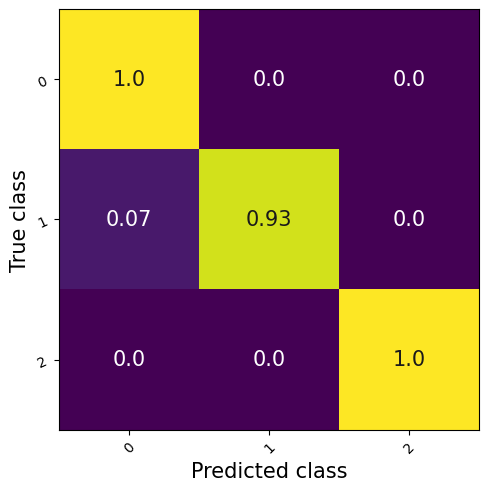

tensor([[2273,    0,    2],
        [   1,   14,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9661 ✨
perclass_f1scores: tensor([0.9993, 0.9655, 0.9333])
perclass_precision: tensor([0.9996, 1.0000, 0.8750])
perclass_recall: tensor([0.9991, 0.9333, 1.0000])
MAE overall: 0.4286 ✨
MAE per_class: {1: np.float64(0.7857142857142857), 2: np.float64(0.07142857142857142)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


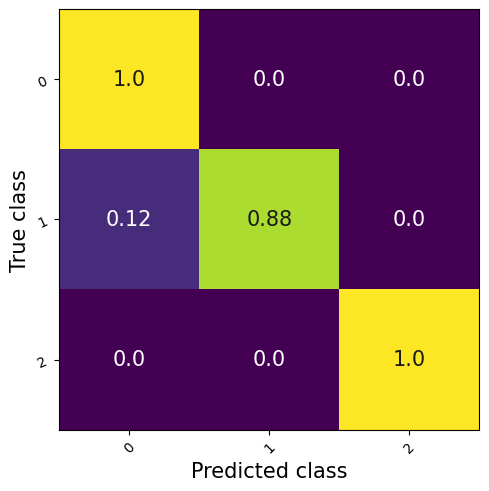

tensor([[2014,    0,    2],
        [   2,   14,    0],
        [   0,    0,   16]])
Macro F1-Score: 0.9578 ✨
perclass_f1scores: tensor([0.9990, 0.9333, 0.9412])
perclass_precision: tensor([0.9990, 1.0000, 0.8889])
perclass_recall: tensor([0.9990, 0.8750, 1.0000])
MAE overall: 0.4333 ✨
MAE per_class: {1: np.float64(0.8571428571428571), 2: np.float64(0.0625)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB09/10_21_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


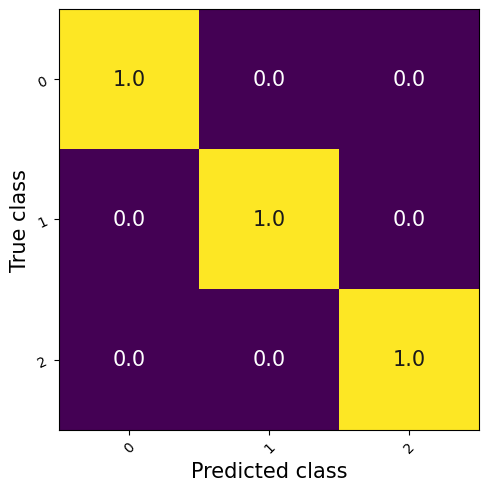

tensor([[2788,    0,    0],
        [   0,   14,    0],
        [   0,    0,   14]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5714 ✨
MAE per_class: {1: np.float64(0.9285714285714286), 2: np.float64(0.21428571428571427)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


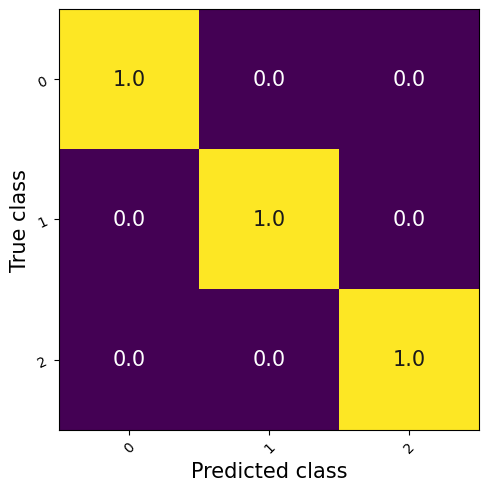

tensor([[1768,    1,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 0.9565, 1.0000])
perclass_precision: tensor([1.0000, 0.9167, 1.0000])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.1739 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.25)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


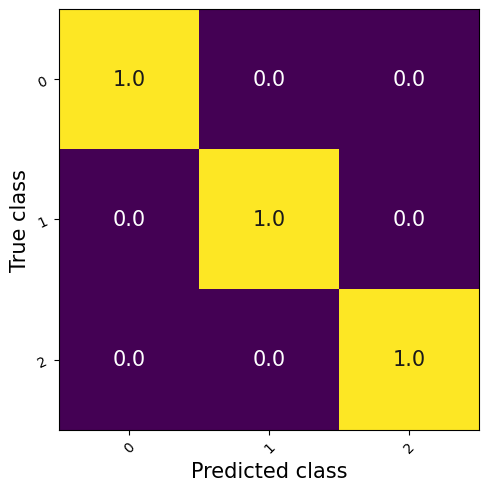

tensor([[1513,    1,    0],
        [   0,   12,    0],
        [   0,    0,   10]])
Macro F1-Score: 0.9866 ✨
perclass_f1scores: tensor([0.9997, 0.9600, 1.0000])
perclass_precision: tensor([1.0000, 0.9231, 1.0000])
perclass_recall: tensor([0.9993, 1.0000, 1.0000])
MAE overall: 0.2273 ✨
MAE per_class: {1: np.float64(0.3333333333333333), 2: np.float64(0.1)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


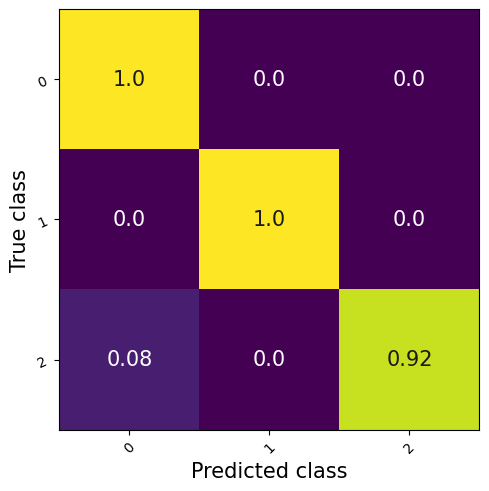

tensor([[1511,    0,    1],
        [   0,   12,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9720 ✨
perclass_f1scores: tensor([0.9993, 1.0000, 0.9167])
perclass_precision: tensor([0.9993, 1.0000, 0.9167])
perclass_recall: tensor([0.9993, 1.0000, 0.9167])
MAE overall: 0.0435 ✨
MAE per_class: {1: np.float64(0.08333333333333333), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


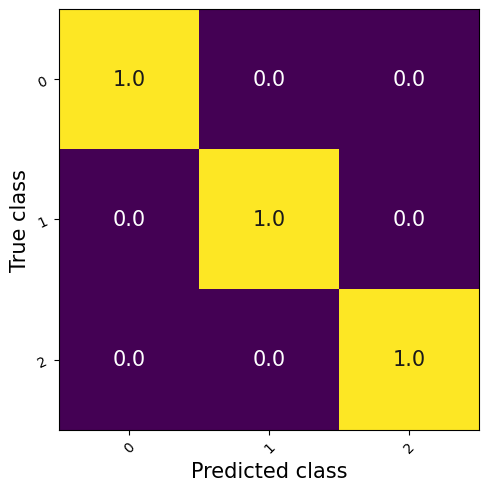

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1364 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.2727272727272727)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


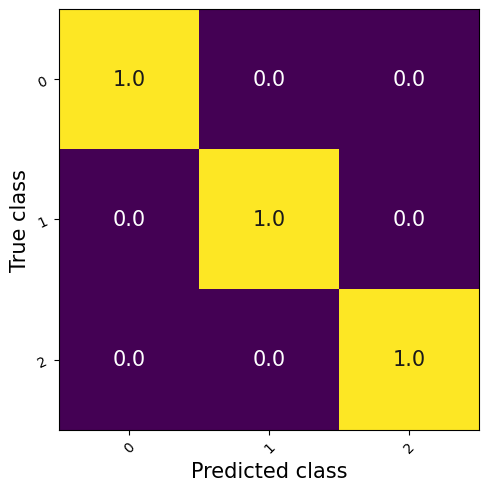

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0909 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.09090909090909091)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


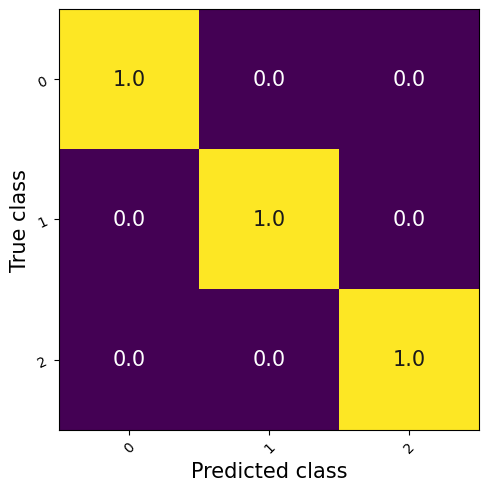

tensor([[1514,    0,    0],
        [   0,   12,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0455 ✨
MAE per_class: {1: np.float64(0.08333333333333333), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_ccw_normal_01_07.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


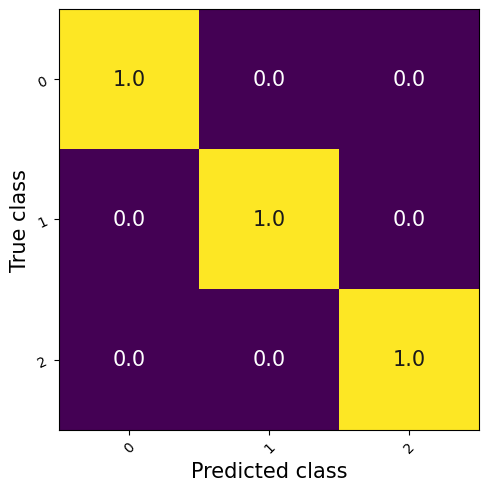

tensor([[1515,    0,    0],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0476 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


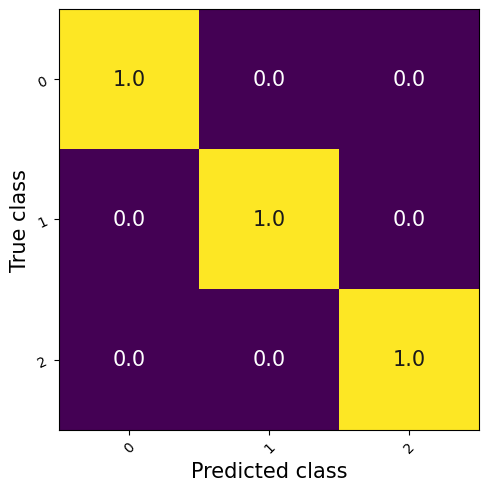

tensor([[1763,    1,    0],
        [   0,   15,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9892 ✨
perclass_f1scores: tensor([0.9997, 0.9677, 1.0000])
perclass_precision: tensor([1.0000, 0.9375, 1.0000])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.1786 ✨
MAE per_class: {1: np.float64(0.3333333333333333), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


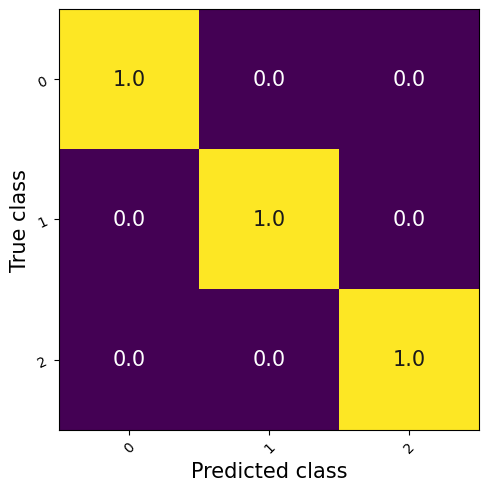

tensor([[1763,    0,    1],
        [   0,   14,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9884 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9655])
perclass_precision: tensor([1.0000, 1.0000, 0.9333])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.2143 ✨
MAE per_class: {1: np.float64(0.14285714285714285), 2: np.float64(0.2857142857142857)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


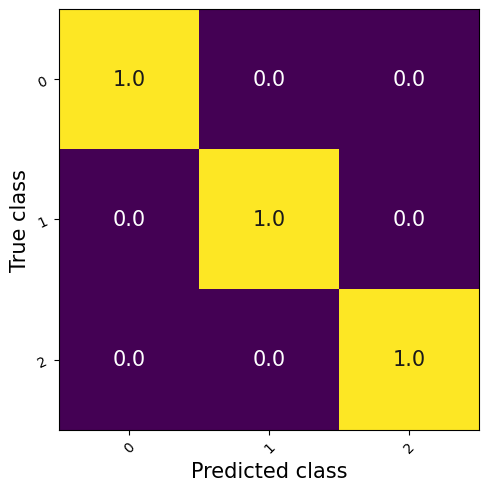

tensor([[1763,    0,    1],
        [   0,   15,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9876 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9630])
perclass_precision: tensor([1.0000, 1.0000, 0.9286])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.2143 ✨
MAE per_class: {1: np.float64(0.26666666666666666), 2: np.float64(0.15384615384615385)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


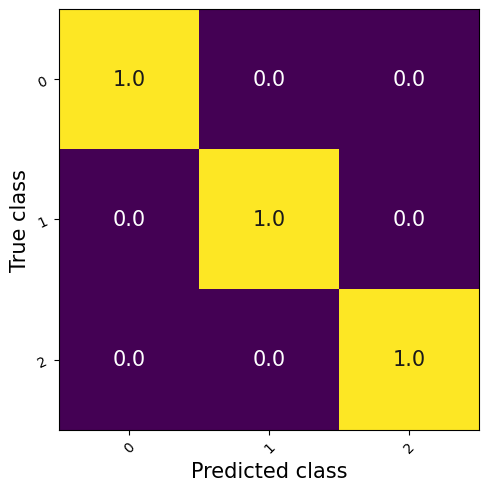

tensor([[2020,    0,    0],
        [   0,   15,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1786 ✨
MAE per_class: {1: np.float64(0.26666666666666666), 2: np.float64(0.07692307692307693)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB11/10_28_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


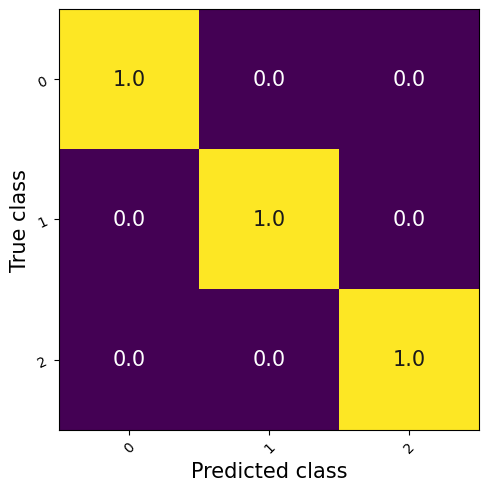

tensor([[2532,    0,    1],
        [   0,   13,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9884 ✨
perclass_f1scores: tensor([0.9998, 1.0000, 0.9655])
perclass_precision: tensor([1.0000, 1.0000, 0.9333])
perclass_recall: tensor([0.9996, 1.0000, 1.0000])
MAE overall: 0.2593 ✨
MAE per_class: {1: np.float64(0.15384615384615385), 2: np.float64(0.35714285714285715)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


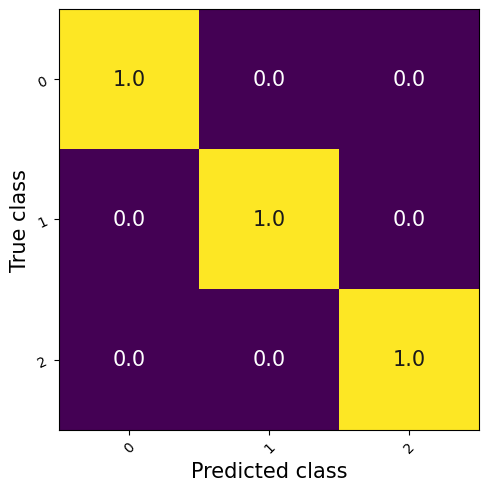

tensor([[1514,    0,    1],
        [   0,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 1.0000, 0.9565])
perclass_precision: tensor([1.0000, 1.0000, 0.9167])
perclass_recall: tensor([0.9993, 1.0000, 1.0000])
MAE overall: 0.9524 ✨
MAE per_class: {1: np.float64(0.8), 2: np.float64(1.0909090909090908)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (4, 256, 7)
all_arrays shape: (4, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([4, 256, 6])
Pred torch.Size([1024]) Target torch.Size([1024])


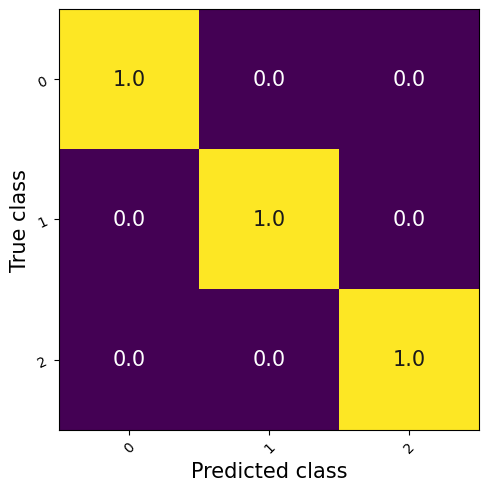

tensor([[1003,    0,    0],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.7143 ✨
MAE per_class: {1: np.float64(0.7272727272727273), 2: np.float64(0.7)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (4, 256, 7)
all_arrays shape: (4, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([4, 256, 6])
Pred torch.Size([1024]) Target torch.Size([1024])


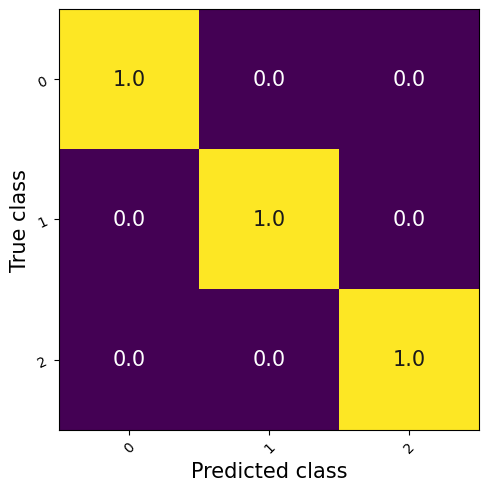

tensor([[1002,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.6364 ✨
MAE per_class: {1: np.float64(0.7272727272727273), 2: np.float64(0.5454545454545454)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


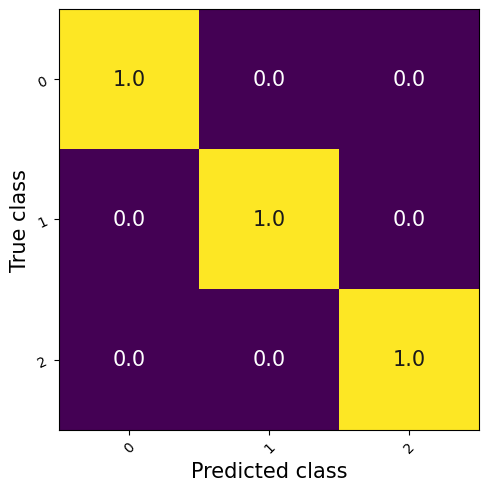

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5652 ✨
MAE per_class: {1: np.float64(0.5833333333333334), 2: np.float64(0.5454545454545454)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


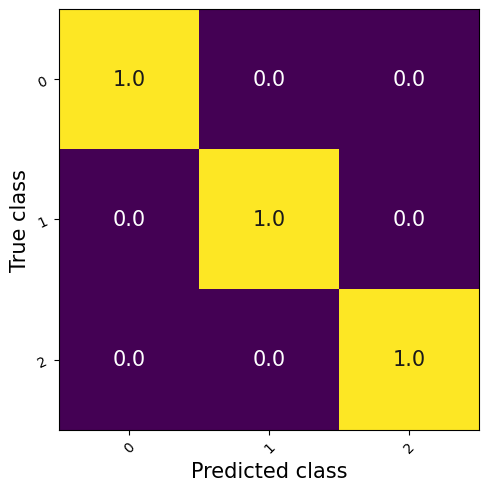

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.4348 ✨
MAE per_class: {1: np.float64(0.5833333333333334), 2: np.float64(0.2727272727272727)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


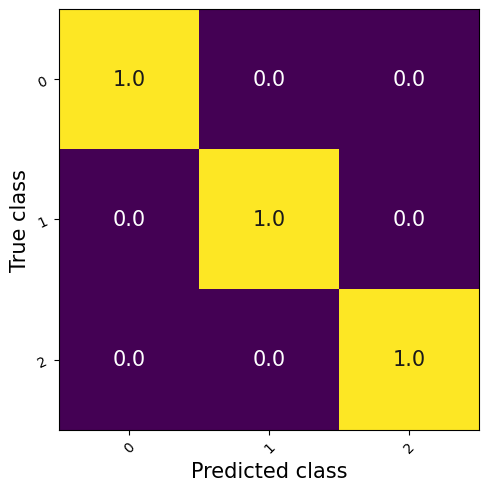

tensor([[1513,    1,    0],
        [   0,   10,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9840 ✨
perclass_f1scores: tensor([0.9997, 0.9524, 1.0000])
perclass_precision: tensor([1.0000, 0.9091, 1.0000])
perclass_recall: tensor([0.9993, 1.0000, 1.0000])
MAE overall: 0.7727 ✨
MAE per_class: {1: np.float64(0.4), 2: np.float64(1.0833333333333333)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


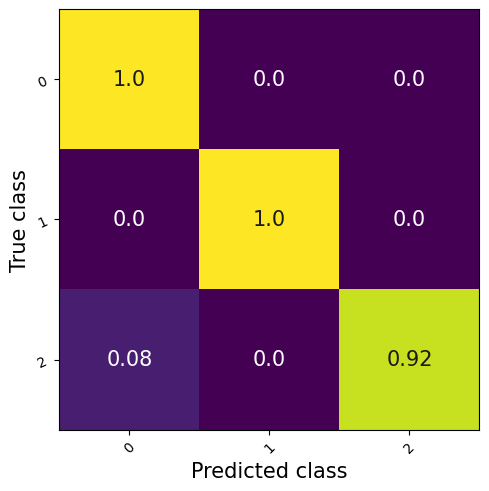

tensor([[1254,    0,    1],
        [   0,   13,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9720 ✨
perclass_f1scores: tensor([0.9992, 1.0000, 0.9167])
perclass_precision: tensor([0.9992, 1.0000, 0.9167])
perclass_recall: tensor([0.9992, 1.0000, 0.9167])
MAE overall: 0.7500 ✨
MAE per_class: {1: np.float64(0.6153846153846154), 2: np.float64(0.9090909090909091)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (4, 256, 7)
all_arrays shape: (4, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([4, 256, 6])
Pred torch.Size([1024]) Target torch.Size([1024])


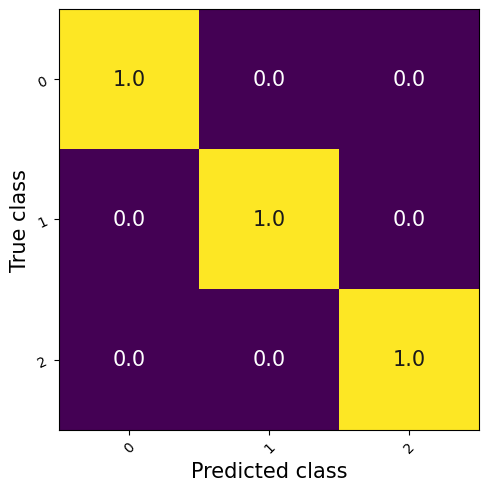

tensor([[1001,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.5217 ✨
MAE per_class: {1: np.float64(0.25), 2: np.float64(0.8181818181818182)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


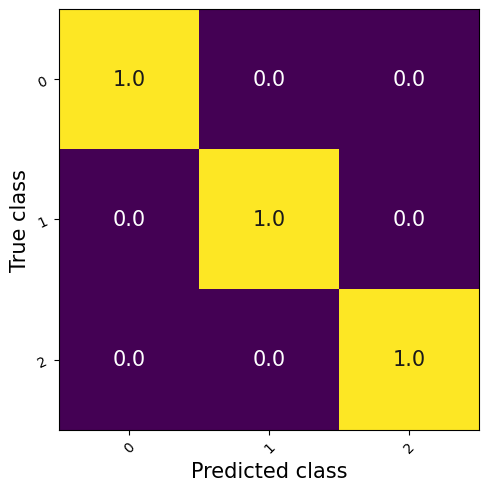

tensor([[1511,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.7200 ✨
MAE per_class: {1: np.float64(0.5384615384615384), 2: np.float64(0.9166666666666666)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB14/11_25_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


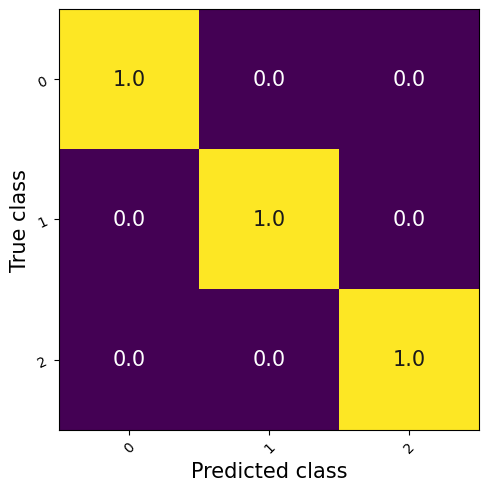

tensor([[1255,    0,    0],
        [   0,   13,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.8000 ✨
MAE per_class: {1: np.float64(0.6923076923076923), 2: np.float64(0.9166666666666666)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


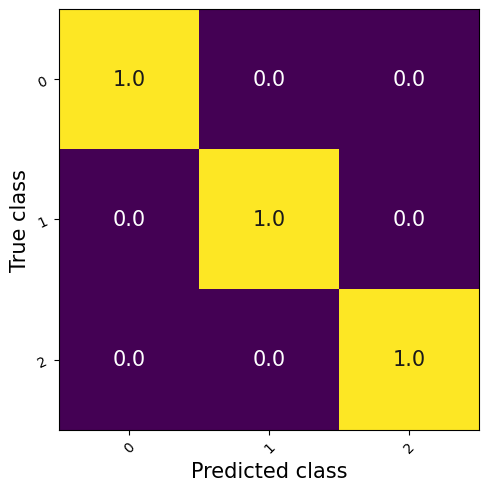

tensor([[2027,    0,    0],
        [   0,   10,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1905 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.36363636363636365)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


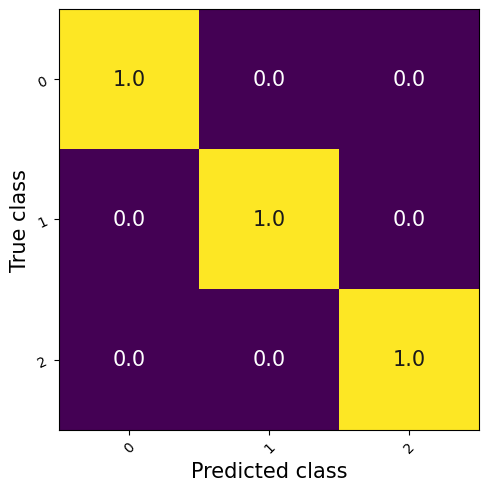

tensor([[1257,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.2174 ✨
MAE per_class: {1: np.float64(0.18181818181818182), 2: np.float64(0.25)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


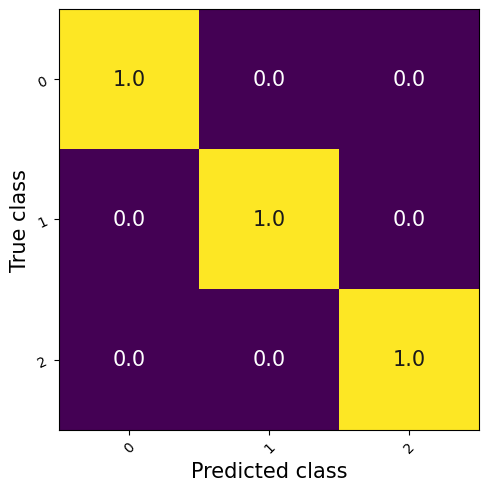

tensor([[1260,    0,    0],
        [   0,   11,    0],
        [   0,    0,    9]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0500 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


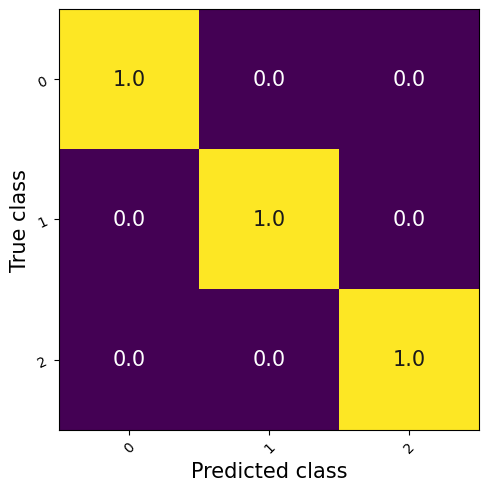

tensor([[1769,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3043 ✨
MAE per_class: {1: np.float64(0.4166666666666667), 2: np.float64(0.18181818181818182)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


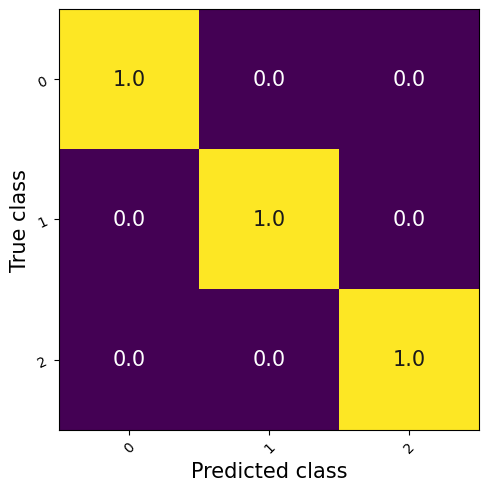

tensor([[2025,    1,    0],
        [   0,   10,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9840 ✨
perclass_f1scores: tensor([0.9998, 0.9524, 1.0000])
perclass_precision: tensor([1.0000, 0.9091, 1.0000])
perclass_recall: tensor([0.9995, 1.0000, 1.0000])
MAE overall: 0.3182 ✨
MAE per_class: {1: np.float64(0.4), 2: np.float64(0.25)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


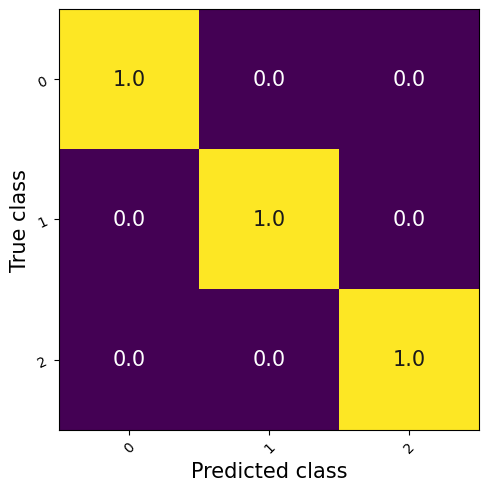

tensor([[1512,    0,    0],
        [   0,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0417 ✨
MAE per_class: {1: np.float64(0.08333333333333333), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


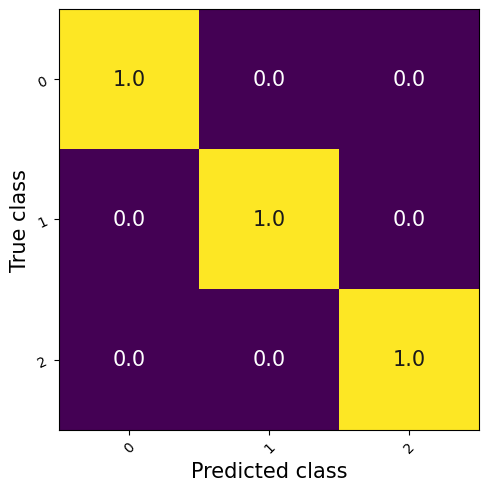

tensor([[1510,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0385 ✨
MAE per_class: {1: np.float64(0.07142857142857142), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB17/11_11_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


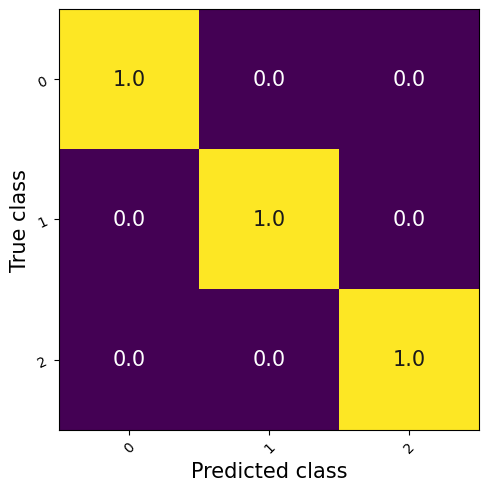

tensor([[1510,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0385 ✨
MAE per_class: {1: np.float64(0.07142857142857142), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


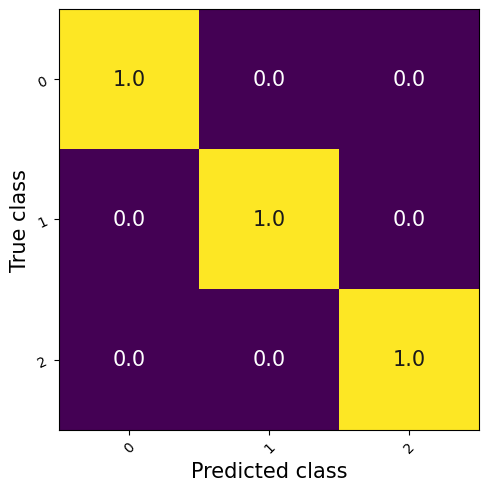

tensor([[2023,    0,    0],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0800 ✨
MAE per_class: {1: np.float64(0.16666666666666666), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


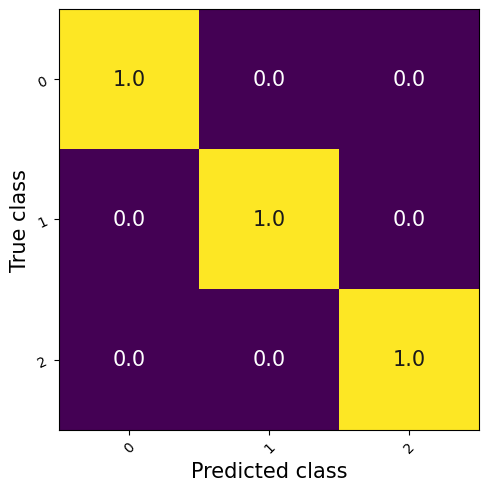

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0000 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


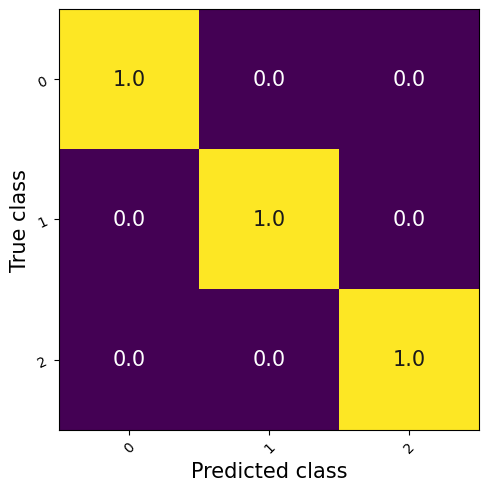

tensor([[1769,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0435 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


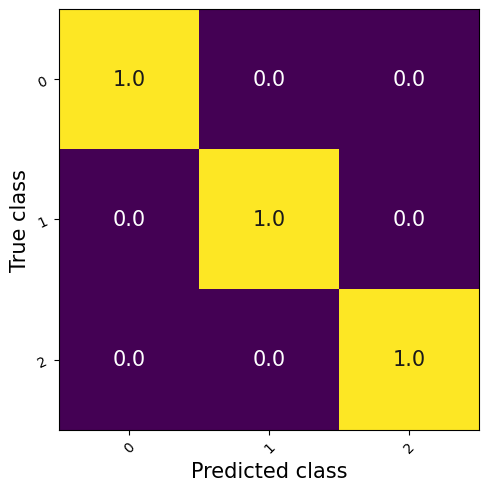

tensor([[1768,    1,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 0.9565, 1.0000])
perclass_precision: tensor([1.0000, 0.9167, 1.0000])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.0870 ✨
MAE per_class: {1: np.float64(0.18181818181818182), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


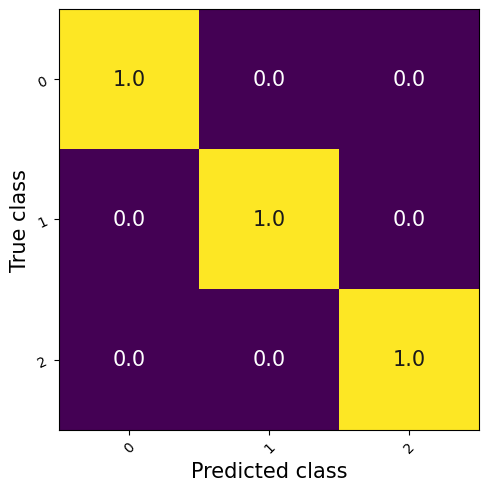

tensor([[2026,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0455 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


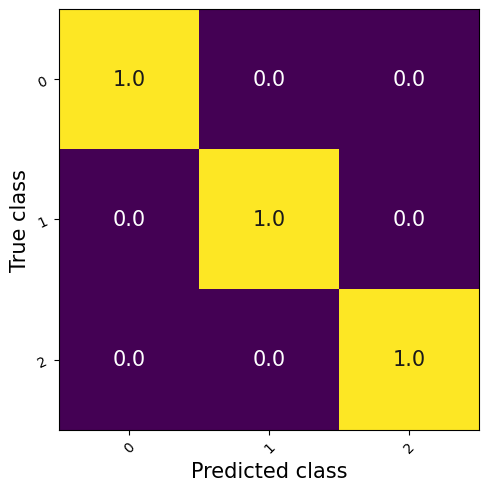

tensor([[2528,    4,    0],
        [   0,   13,    0],
        [   0,    0,   15]])
Macro F1-Score: 0.9553 ✨
perclass_f1scores: tensor([0.9992, 0.8667, 1.0000])
perclass_precision: tensor([1.0000, 0.7647, 1.0000])
perclass_recall: tensor([0.9984, 1.0000, 1.0000])
MAE overall: 0.1786 ✨
MAE per_class: {1: np.float64(0.07692307692307693), 2: np.float64(0.26666666666666666)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


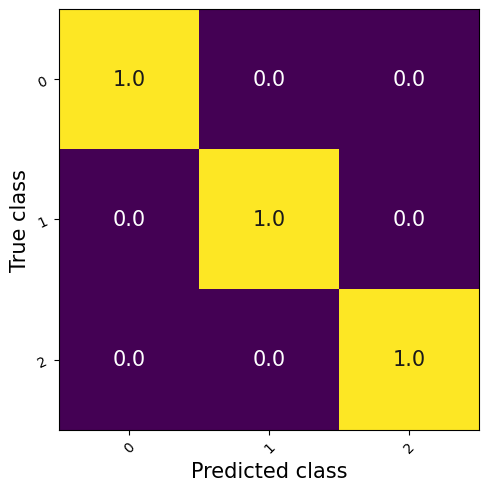

tensor([[2020,    0,    0],
        [   0,   14,    0],
        [   0,    0,   14]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0357 ✨
MAE per_class: {1: np.float64(0.07142857142857142), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


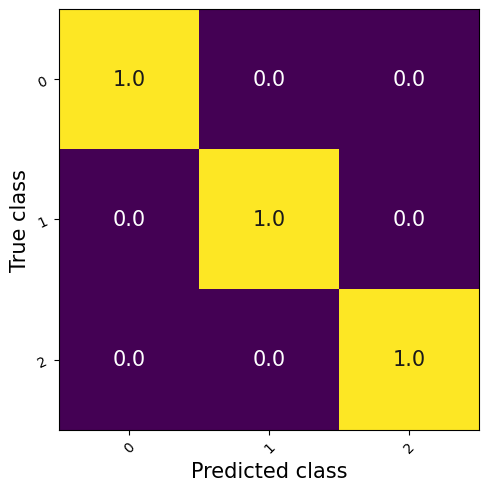

tensor([[1765,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0741 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.15384615384615385)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


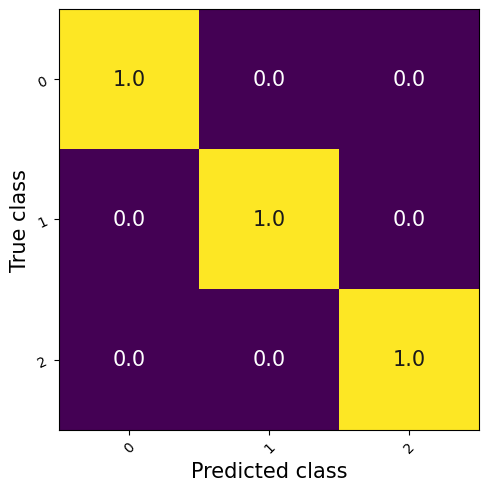

tensor([[1765,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0741 ✨
MAE per_class: {1: np.float64(0.07142857142857142), 2: np.float64(0.07692307692307693)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB19/11_18_2018/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


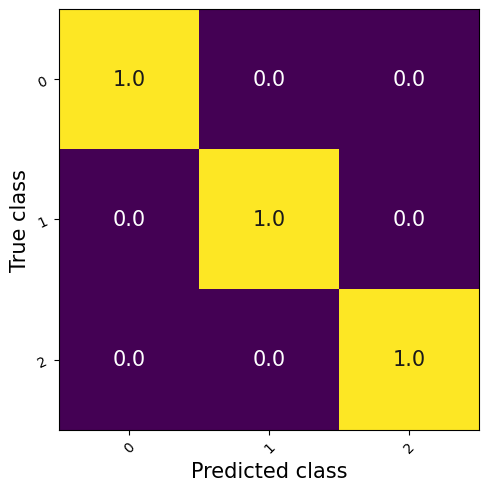

tensor([[2276,    1,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9884 ✨
perclass_f1scores: tensor([0.9998, 0.9655, 1.0000])
perclass_precision: tensor([1.0000, 0.9333, 1.0000])
perclass_recall: tensor([0.9996, 1.0000, 1.0000])
MAE overall: 0.1111 ✨
MAE per_class: {1: np.float64(0.07142857142857142), 2: np.float64(0.15384615384615385)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


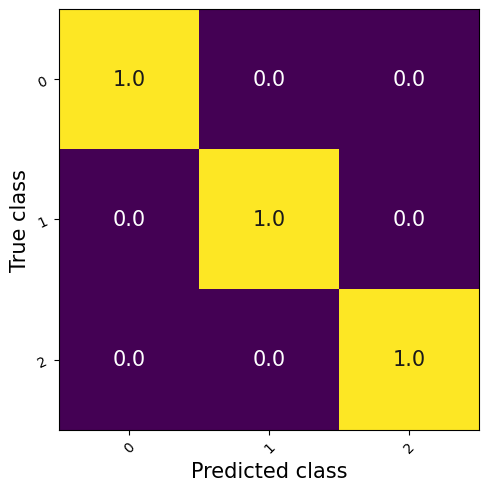

tensor([[1513,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3478 ✨
MAE per_class: {1: np.float64(0.45454545454545453), 2: np.float64(0.25)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


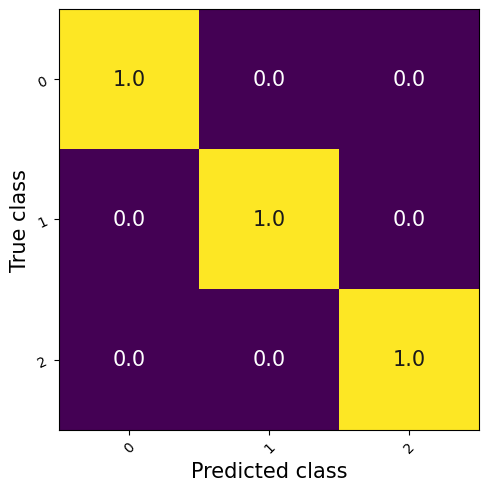

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1304 ✨
MAE per_class: {1: np.float64(0.25), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_02npy.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


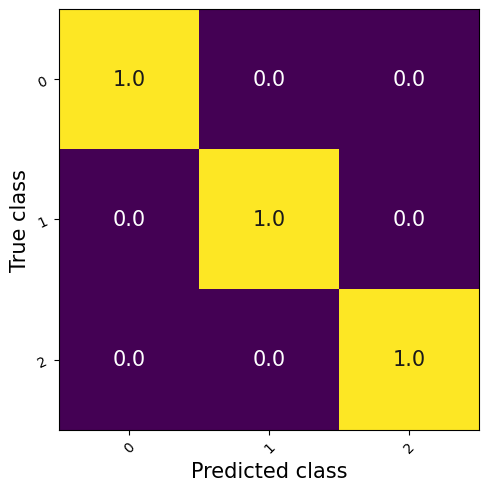

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1304 ✨
MAE per_class: {1: np.float64(0.25), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


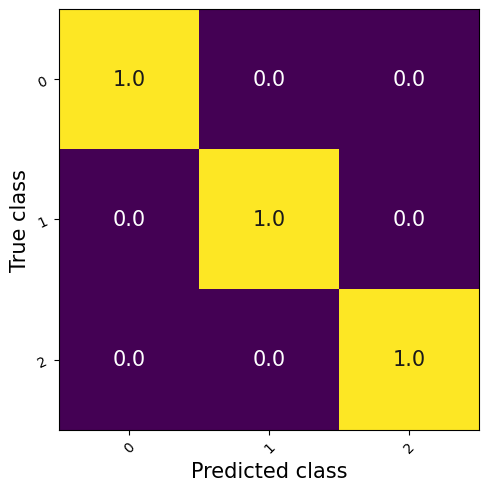

tensor([[1257,    1,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9996, 0.9565, 1.0000])
perclass_precision: tensor([1.0000, 0.9167, 1.0000])
perclass_recall: tensor([0.9992, 1.0000, 1.0000])
MAE overall: 0.3182 ✨
MAE per_class: {1: np.float64(0.6363636363636364), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


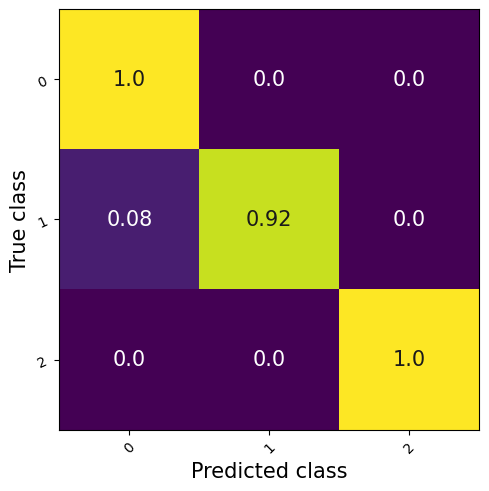

tensor([[1255,    2,    0],
        [   1,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9596 ✨
perclass_f1scores: tensor([0.9988, 0.8800, 1.0000])
perclass_precision: tensor([0.9992, 0.8462, 1.0000])
perclass_recall: tensor([0.9984, 0.9167, 1.0000])
MAE overall: 0.2273 ✨
MAE per_class: {1: np.float64(0.36363636363636365), 2: np.float64(0.09090909090909091)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


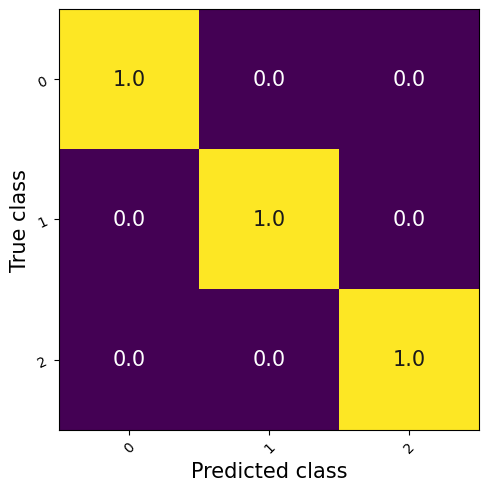

tensor([[1257,    0,    0],
        [   0,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1739 ✨
MAE per_class: {1: np.float64(0.3333333333333333), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


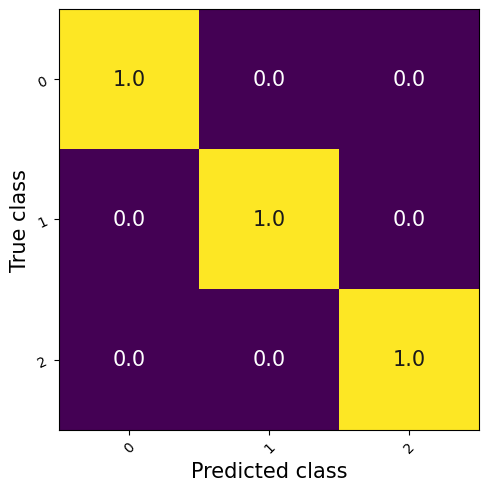

tensor([[1764,    1,    0],
        [   0,   13,    0],
        [   0,    0,   14]])
Macro F1-Score: 0.9876 ✨
perclass_f1scores: tensor([0.9997, 0.9630, 1.0000])
perclass_precision: tensor([1.0000, 0.9286, 1.0000])
perclass_recall: tensor([0.9994, 1.0000, 1.0000])
MAE overall: 0.2593 ✨
MAE per_class: {1: np.float64(0.15384615384615385), 2: np.float64(0.35714285714285715)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


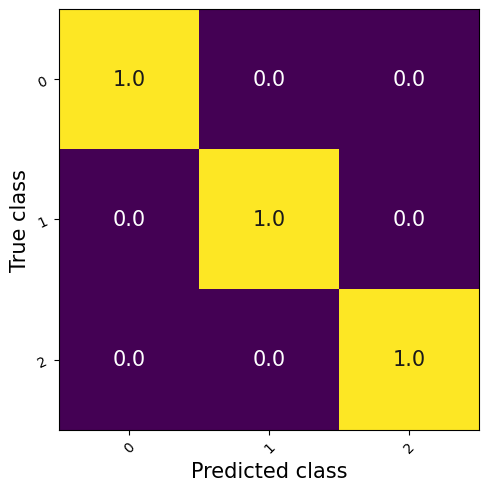

tensor([[1256,    0,    0],
        [   0,   13,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0000 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


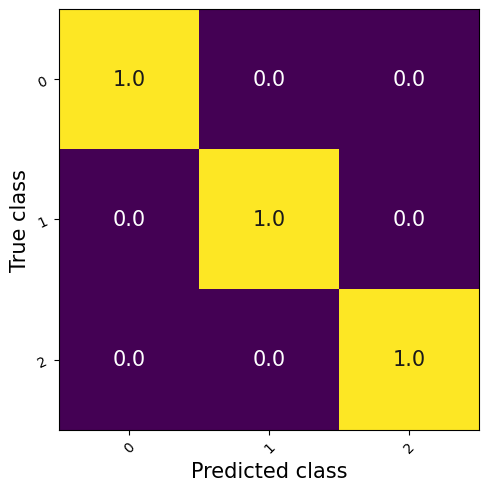

tensor([[1508,    0,    0],
        [   0,   14,    0],
        [   0,    0,   14]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0714 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.14285714285714285)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


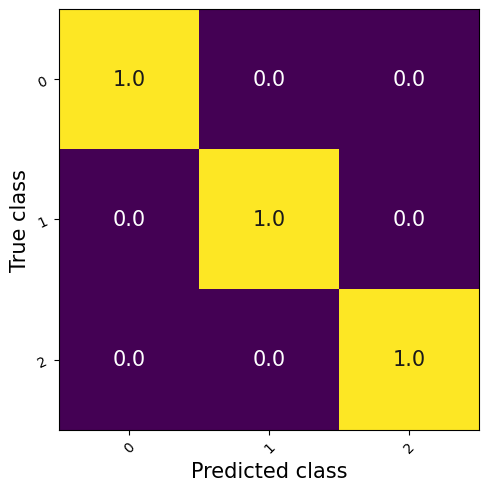

tensor([[1256,    0,    0],
        [   0,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1667 ✨
MAE per_class: {1: np.float64(0.25), 2: np.float64(0.08333333333333333)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB21/01_27_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (5, 256, 7)
all_arrays shape: (5, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([5, 256, 6])
Pred torch.Size([1280]) Target torch.Size([1280])


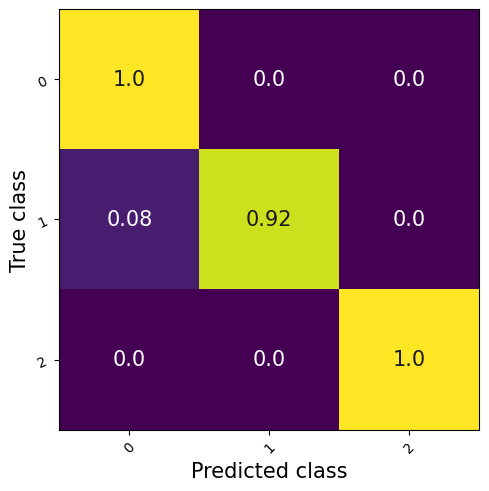

tensor([[1255,    0,    1],
        [   1,   12,    0],
        [   0,    0,   11]])
Macro F1-Score: 0.9719 ✨
perclass_f1scores: tensor([0.9992, 0.9600, 0.9565])
perclass_precision: tensor([0.9992, 1.0000, 0.9167])
perclass_recall: tensor([0.9992, 0.9231, 1.0000])
MAE overall: 0.0000 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


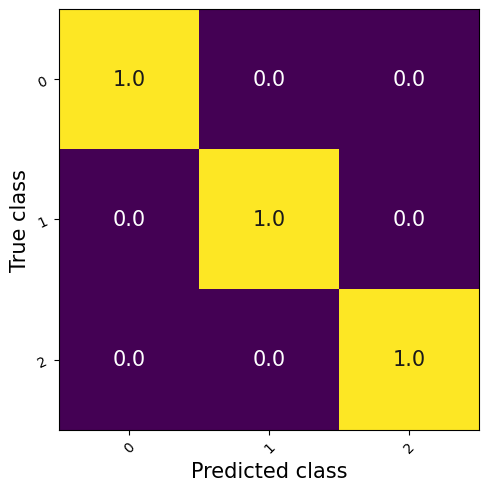

tensor([[1772,    0,    0],
        [   0,    9,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.2000 ✨
MAE per_class: {1: np.float64(0.1111111111111111), 2: np.float64(0.2727272727272727)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


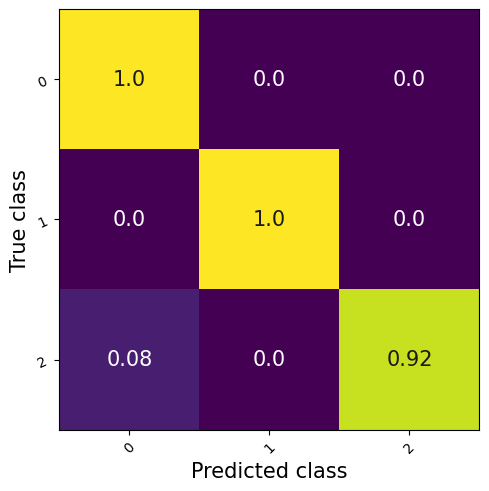

tensor([[1512,    0,    1],
        [   0,   11,    0],
        [   1,    0,   11]])
Macro F1-Score: 0.9720 ✨
perclass_f1scores: tensor([0.9993, 1.0000, 0.9167])
perclass_precision: tensor([0.9993, 1.0000, 0.9167])
perclass_recall: tensor([0.9993, 1.0000, 0.9167])
MAE overall: 0.2273 ✨
MAE per_class: {1: np.float64(0.18181818181818182), 2: np.float64(0.2727272727272727)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


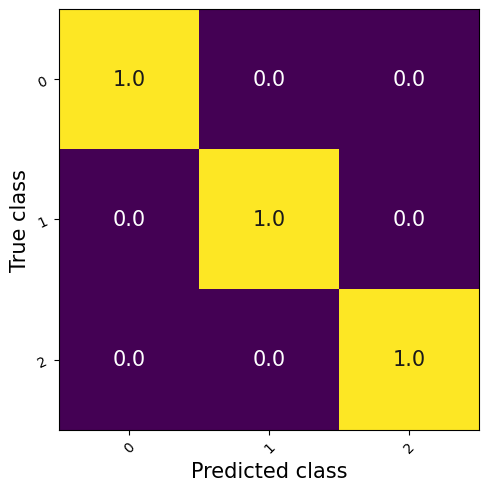

tensor([[1515,    0,    0],
        [   0,   11,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0952 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.1)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


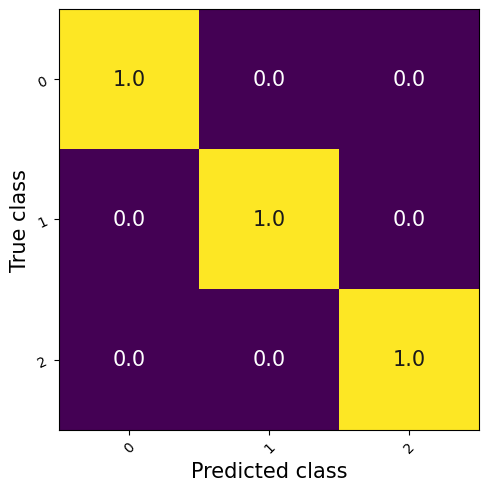

tensor([[1516,    0,    0],
        [   0,   10,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0500 ✨
MAE per_class: {1: np.float64(0.1), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


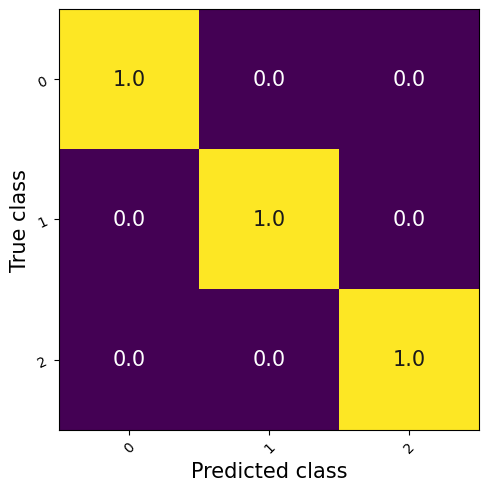

tensor([[1516,    0,    0],
        [   0,   10,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1500 ✨
MAE per_class: {1: np.float64(0.2), 2: np.float64(0.1)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


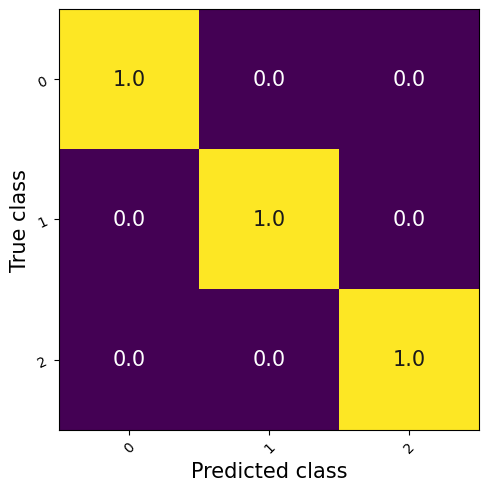

tensor([[2787,    0,    0],
        [   0,   14,    0],
        [   0,    0,   15]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1379 ✨
MAE per_class: {1: np.float64(0.07142857142857142), 2: np.float64(0.2)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


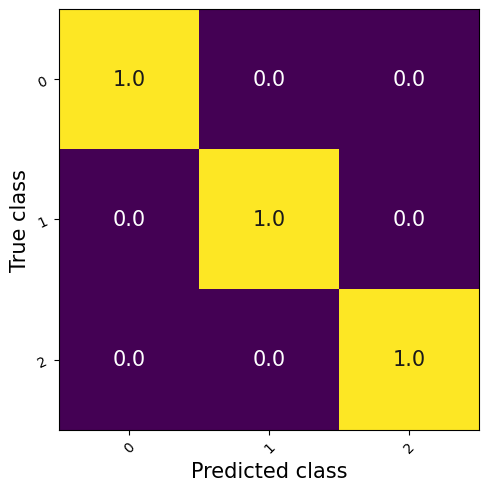

tensor([[1509,    0,    0],
        [   0,   14,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0370 ✨
MAE per_class: {1: np.float64(0.07142857142857142), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


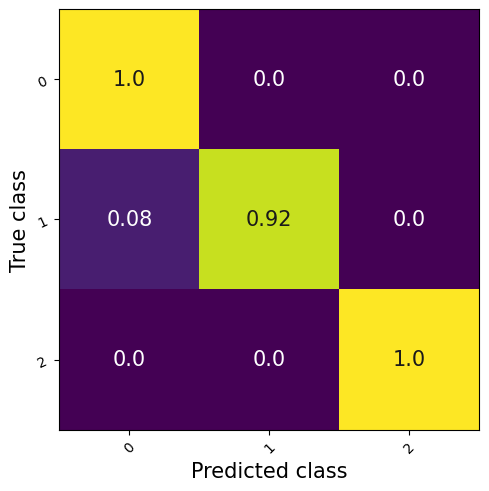

tensor([[1512,    0,    0],
        [   1,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9997, 0.9565, 1.0000])
perclass_precision: tensor([0.9993, 1.0000, 1.0000])
perclass_recall: tensor([1.0000, 0.9167, 1.0000])
MAE overall: 0.0000 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


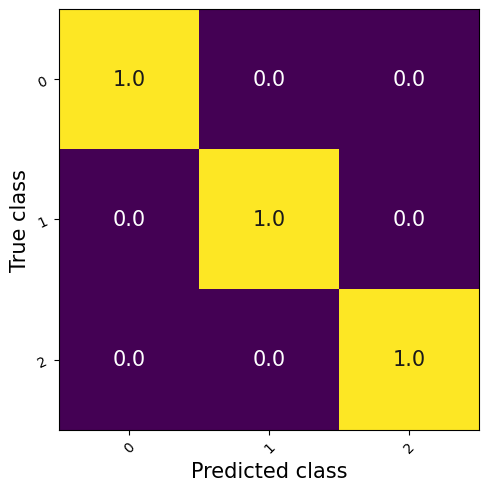

tensor([[1510,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1538 ✨
MAE per_class: {1: np.float64(0.21428571428571427), 2: np.float64(0.08333333333333333)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


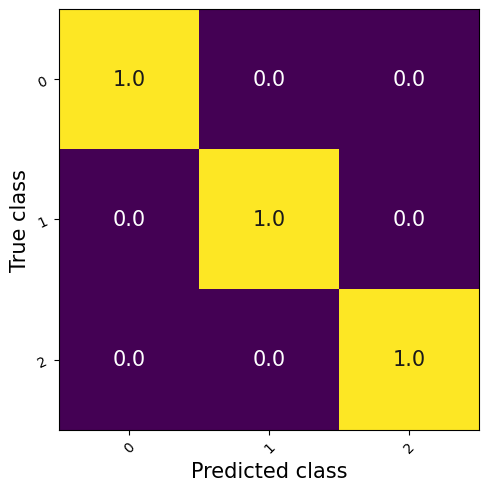

tensor([[2278,    1,    0],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9866 ✨
perclass_f1scores: tensor([0.9998, 0.9600, 1.0000])
perclass_precision: tensor([1.0000, 0.9231, 1.0000])
perclass_recall: tensor([0.9996, 1.0000, 1.0000])
MAE overall: 0.2000 ✨
MAE per_class: {1: np.float64(0.16666666666666666), 2: np.float64(0.23076923076923078)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB23/11_25_2018/levelground/imu/levelground_cw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


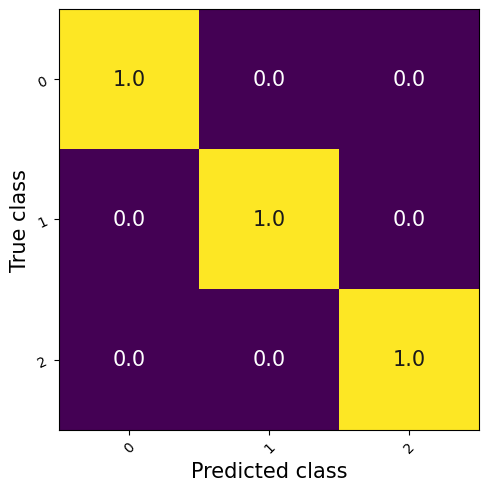

tensor([[1510,    0,    0],
        [   0,   14,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1154 ✨
MAE per_class: {1: np.float64(0.21428571428571427), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


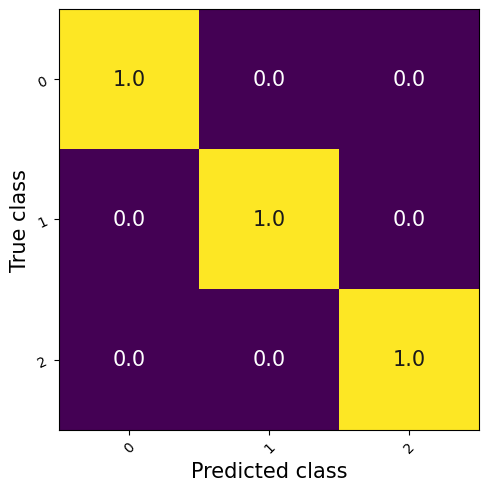

tensor([[2029,    0,    0],
        [   0,    9,    0],
        [   0,    0,   10]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3158 ✨
MAE per_class: {1: np.float64(0.3333333333333333), 2: np.float64(0.3)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


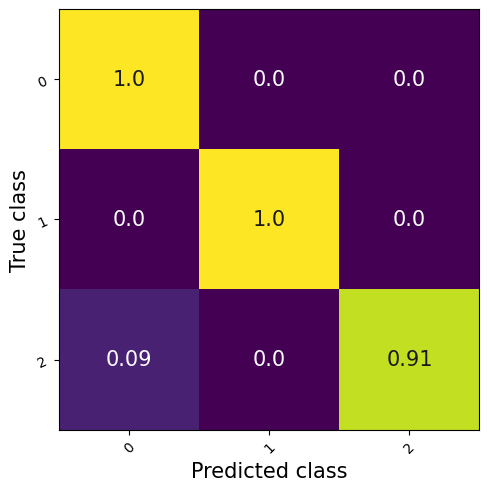

tensor([[1513,    1,    0],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9694 ✨
perclass_f1scores: tensor([0.9993, 0.9565, 0.9524])
perclass_precision: tensor([0.9993, 0.9167, 1.0000])
perclass_recall: tensor([0.9993, 1.0000, 0.9091])
MAE overall: 0.0952 ✨
MAE per_class: {1: np.float64(0.18181818181818182), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


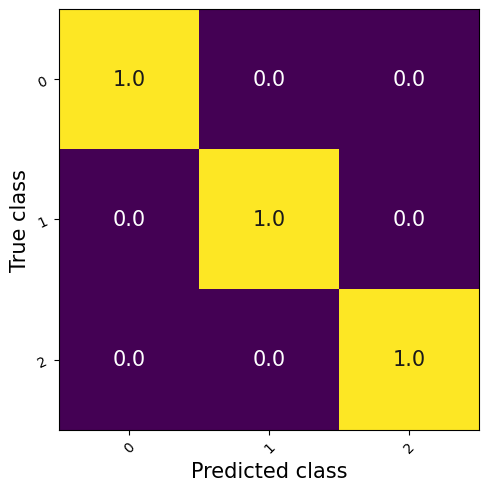

tensor([[1517,    0,    0],
        [   0,   10,    0],
        [   0,    0,    9]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1579 ✨
MAE per_class: {1: np.float64(0.2), 2: np.float64(0.1111111111111111)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


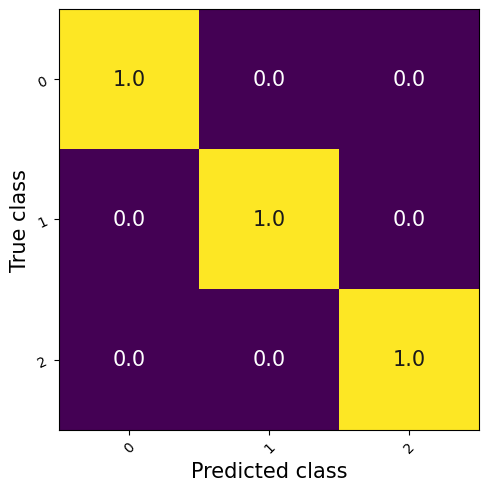

tensor([[1770,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0909 ✨
MAE per_class: {1: np.float64(0.18181818181818182), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


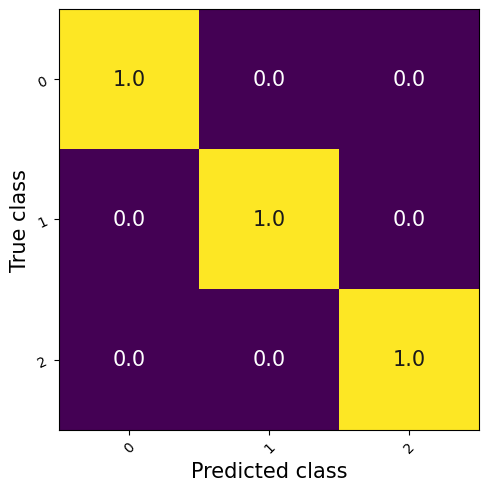

tensor([[1514,    0,    0],
        [   0,   11,    0],
        [   0,    0,   11]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.2273 ✨
MAE per_class: {1: np.float64(0.18181818181818182), 2: np.float64(0.2727272727272727)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_ccw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([6, 256, 6])
Pred torch.Size([1536]) Target torch.Size([1536])


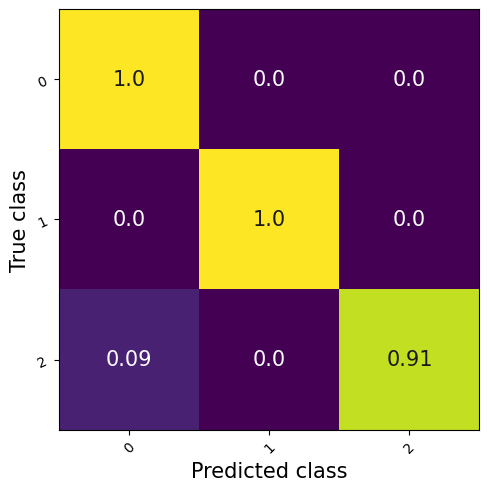

tensor([[1513,    0,    1],
        [   0,   11,    0],
        [   1,    0,   10]])
Macro F1-Score: 0.9695 ✨
perclass_f1scores: tensor([0.9993, 1.0000, 0.9091])
perclass_precision: tensor([0.9993, 1.0000, 0.9091])
perclass_recall: tensor([0.9993, 1.0000, 0.9091])
MAE overall: 0.1429 ✨
MAE per_class: {1: np.float64(0.2727272727272727), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


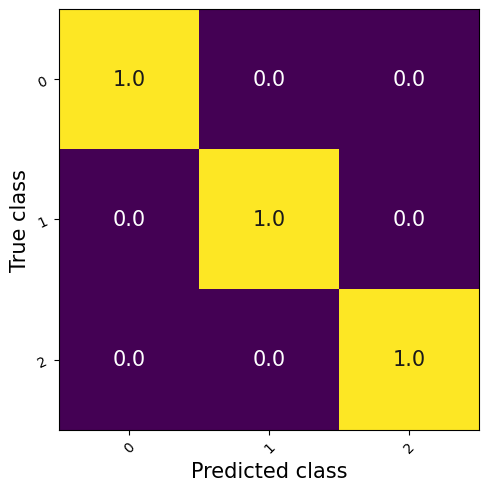

tensor([[2025,    0,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1739 ✨
MAE per_class: {1: np.float64(0.09090909090909091), 2: np.float64(0.25)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


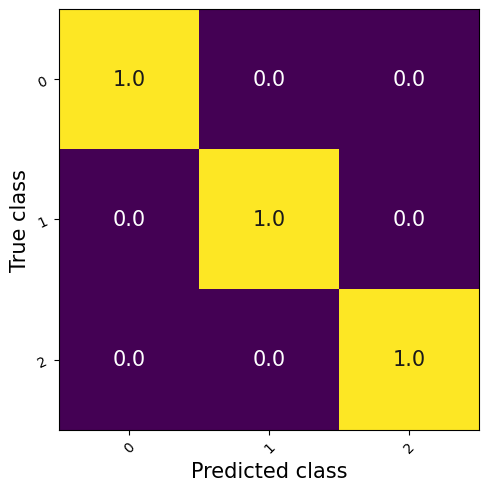

tensor([[2024,    0,    0],
        [   0,   12,    0],
        [   0,    0,   12]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.2500 ✨
MAE per_class: {1: np.float64(0.25), 2: np.float64(0.25)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_01.npy
self.expand_labels 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([8, 256, 6])
Pred torch.Size([2048]) Target torch.Size([2048])


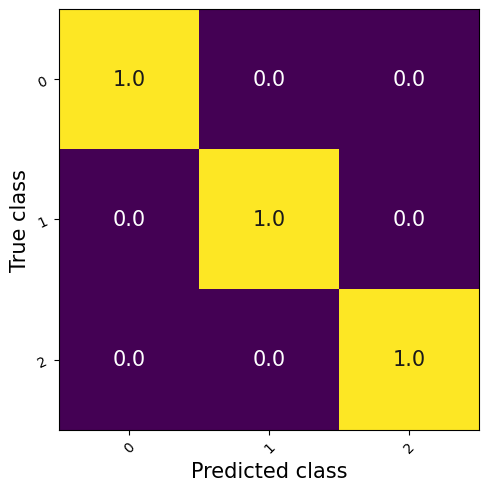

tensor([[2024,    1,    0],
        [   0,   11,    0],
        [   0,    0,   12]])
Macro F1-Score: 0.9854 ✨
perclass_f1scores: tensor([0.9998, 0.9565, 1.0000])
perclass_precision: tensor([1.0000, 0.9167, 1.0000])
perclass_recall: tensor([0.9995, 1.0000, 1.0000])
MAE overall: 0.3478 ✨
MAE per_class: {1: np.float64(0.36363636363636365), 2: np.float64(0.3333333333333333)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_02.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


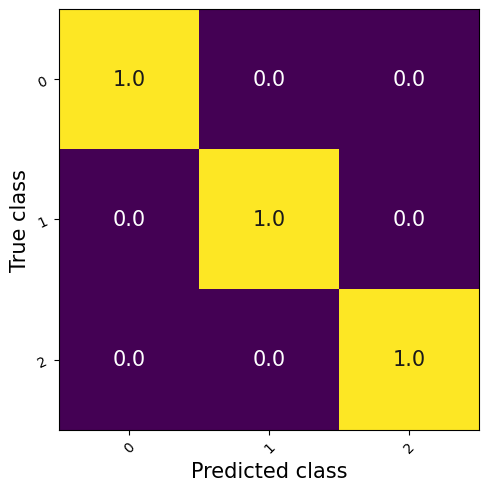

tensor([[1765,    1,    1],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 0.9741 ✨
perclass_f1scores: tensor([0.9994, 0.9600, 0.9630])
perclass_precision: tensor([1.0000, 0.9231, 0.9286])
perclass_recall: tensor([0.9989, 1.0000, 1.0000])
MAE overall: 0.5200 ✨
MAE per_class: {1: np.float64(0.5833333333333334), 2: np.float64(0.46153846153846156)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB24/12_02_2018/levelground/imu/levelground_cw_normal_02_03.npy
self.expand_labels 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([7, 256, 6])
Pred torch.Size([1792]) Target torch.Size([1792])


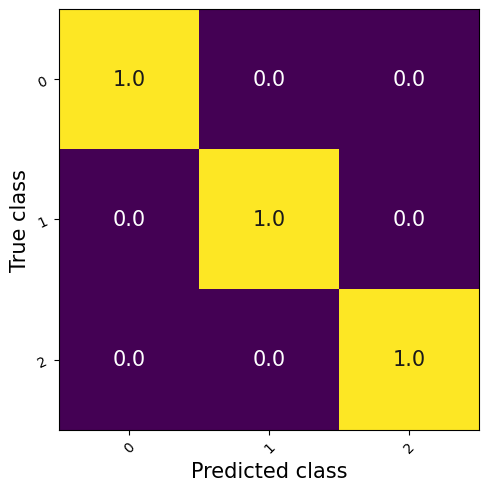

tensor([[1767,    0,    0],
        [   0,   12,    0],
        [   0,    0,   13]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.3200 ✨
MAE per_class: {1: np.float64(0.3333333333333333), 2: np.float64(0.3076923076923077)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_01.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


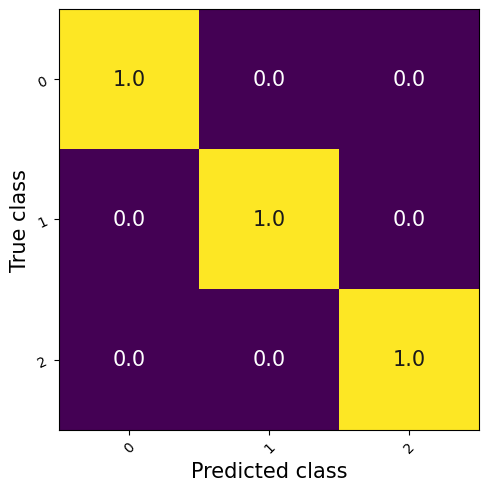

tensor([[2787,    0,    0],
        [   0,   14,    0],
        [   0,    0,   15]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.1034 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.2)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_02.npy
self.expand_labels 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([11, 256, 6])
Pred torch.Size([2816]) Target torch.Size([2816])


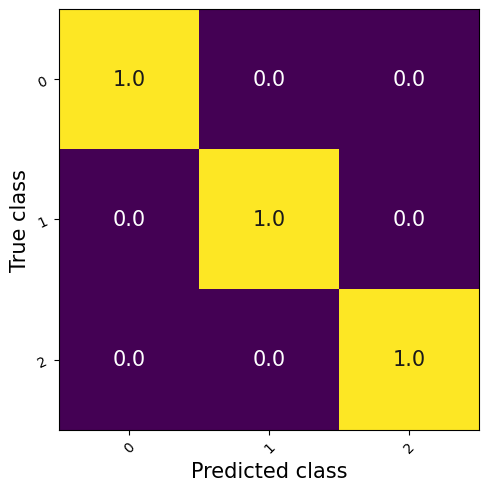

tensor([[2782,    0,    1],
        [   0,   17,    0],
        [   0,    0,   16]])
Macro F1-Score: 0.9898 ✨
perclass_f1scores: tensor([0.9998, 1.0000, 0.9697])
perclass_precision: tensor([1.0000, 1.0000, 0.9412])
perclass_recall: tensor([0.9996, 1.0000, 1.0000])
MAE overall: 0.0909 ✨
MAE per_class: {1: np.float64(0.058823529411764705), 2: np.float64(0.125)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_03.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


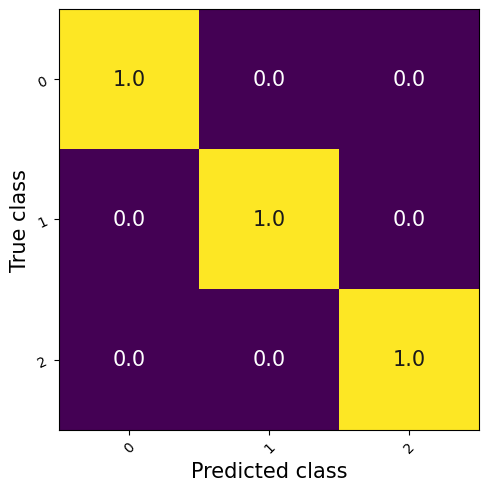

tensor([[2270,    0,    0],
        [   0,   18,    0],
        [   0,    0,   16]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0294 ✨
MAE per_class: {1: np.float64(0.05555555555555555), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_04.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


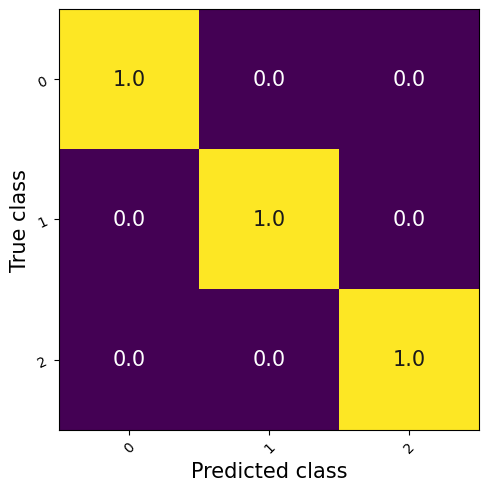

tensor([[2272,    0,    0],
        [   0,   17,    0],
        [   0,    0,   15]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0000 ✨
MAE per_class: {1: np.float64(0.0), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_05.npy
self.expand_labels 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([9, 256, 6])
Pred torch.Size([2304]) Target torch.Size([2304])


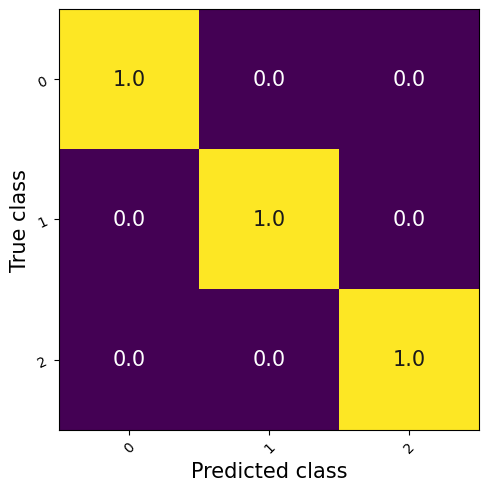

tensor([[2271,    0,    0],
        [   0,   17,    0],
        [   0,    0,   16]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0606 ✨
MAE per_class: {1: np.float64(0.11764705882352941), 2: np.float64(0.0)} ✨
train_stats: {'mean': array([-1.07758607,  0.0479508 ,  0.02717078,  0.02035611, -0.18265179,
       -0.08436056]), 'std': array([0.50959778, 0.75258931, 2.27528855, 0.05960081, 0.47015633,
       0.61942234])}
/home/qivy00li/projects/gait_ml/data/processed/external_data1/AB25/01_20_2019/levelground/imu/levelground_cw_normal_01_06.npy
self.expand_labels 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)
====++++Enters ZSCALE in ExternalGAITDATASET====++++
torch.Size([10, 256, 6])
Pred torch.Size([2560]) Target torch.Size([2560])


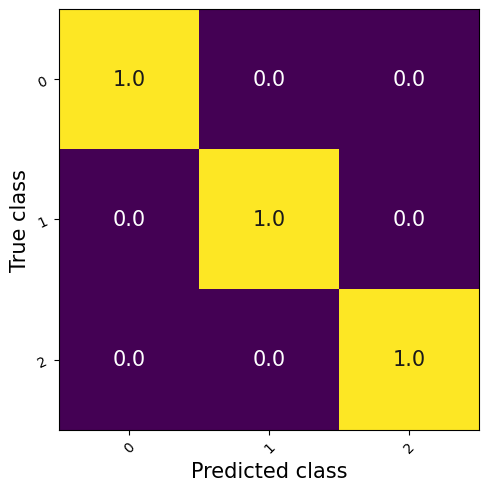

tensor([[2526,    0,    0],
        [   0,   18,    0],
        [   0,    0,   16]])
Macro F1-Score: 1.0000 ✨
perclass_f1scores: tensor([1., 1., 1.])
perclass_precision: tensor([1., 1., 1.])
perclass_recall: tensor([1., 1., 1.])
MAE overall: 0.0882 ✨
MAE per_class: {1: np.float64(0.05555555555555555), 2: np.float64(0.125)} ✨


In [221]:
testset_f1_scores = []
testset_pc_f1_scores = []
testset_pc_precision = []
testset_pc_recall = []
testset_mae = []
testset_pc_mae = []
testset_cm = []
group_assigment = []
all_preds = []
all_targets = []

cur_set_to_test = np.arange(len(test_set_fpaths))
for curr_test_idx in cur_set_to_test.tolist():

    if use_internal_train_stats:
        train_stat = {'mean': np.array([-0.26654707, -0.02442654,  0.37051307, -0.00488071,  1.36632781, 0.86179046]), 
                      'std': np.array([1.42070944, 2.89440634, 1.53666348, 5.25694552, 3.22176259,5.12151813]),}
        # global_mean = train_stat["mean"]
        # global_var = train_stat["std"]
    else:
        # global_mean = np.zeros(6)
        # global_var = np.ones(6)
        train_stat=curr_datamodule.train_dataset.zscale_stats
        
    curr_test_datamodule = ExternalGaitDataModule(np.array(test_set_fpaths), 
                                             test_idx=[curr_test_idx], 
                                             batch_size=1024,
                                             window_size=256,
                                             step_size=256,
                                             expand_labels=0,
                                             zscale=True,
                                             zscale_stats=train_stat
                                            )
    curr_test_datamodule.setup("test")
    test_dataloader = curr_test_datamodule.test_dataloader()
    best_model.eval()
    pred=[]
    target=[]
    for sample_input, sample_target in test_dataloader:
        # data_sf = [pd.DataFrame(sample_input[i].numpy(), columns=['gyr_x', 'gyr_y', 'gyr_z', 'acc_x', 'acc_y', 'acc_z']) for i in range(sample_input.shape[0])]
        # data_sf = [rotate_dataset(i, R) for i in data_sf]
        # # data_sf = [sensor_alignment.align_dataset_to_gravity(i, 100) for i in data_sf]
        # sample_input = torch.tensor(np.stack(([i.values for i in data_sf]))).to(torch.float32)
        # print("old mean:", sample_input.mean([0, 1]))
        # sample_input = (sample_input-global_mean)/global_var
        # print("normalized mean:", sample_input.mean([0, 1]))
        sample_input = sample_input.to(device_)
        sample_target = sample_target.to(device_)
        print(sample_input.shape)
        with torch.no_grad():
            predicted_output = best_model(sample_input, sample_target, teacher_forcing_ratio=0.0)
        pred.append(predicted_output)
        target.append(sample_target)
    
    cur_pred = torch.concat(pred).reshape(-1, 3)
    cur_pred = torch.nn.functional.softmax(cur_pred, dim=-1).argmax(1)
    cur_target = torch.concat(target).reshape(-1)
    reshaped_input = sample_input.reshape(-1, sample_input.shape[-1]).cpu().numpy()
    print("Pred", cur_pred.shape, "Target", cur_target.shape)
    
    ALIGN_TOLERANCE = 3
    merged_preds = evaluate.merge_clustered_events(cur_pred.cpu().numpy())
    merged_targets = evaluate.merge_clustered_events(cur_target.cpu().numpy())
    aligned_preds = evaluate.align_events(merged_targets, merged_preds, ALIGN_TOLERANCE)
    
    
    cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
    cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    fig_, ax_ = cm.plot()
    plt.show()
    unnormalized_cm = MulticlassConfusionMatrix(num_classes=3, normalize=None)
    unnormalized_cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    ucm_tensor = unnormalized_cm.compute()
    testset_cm.append(ucm_tensor)
    print(ucm_tensor)
    
    num_classes = 3
    f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro')
    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    print(f"Macro F1-Score: {f1_macro_score.item():.4f} ✨")
    
    pc_f1score = MulticlassF1Score(num_classes=num_classes, average='none')
    perclass_f1scores = pc_f1score(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_f1_scores.append(perclass_f1scores)
    print(f"perclass_f1scores:", perclass_f1scores)
    
    pc_precision = MulticlassPrecision(num_classes=num_classes, average='none')
    perclass_precision = pc_precision(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_precision.append(perclass_precision)
    print(f"perclass_precision:", perclass_precision)
    
    pc_recall = MulticlassRecall(num_classes=num_classes, average='none')
    perclass_recall = pc_recall(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    testset_pc_recall.append(perclass_recall)
    print(f"perclass_recall:", perclass_recall)
    
    f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
    
    overall, per_class = calculate_gait_mae(merged_targets, merged_preds, tolerance=3)
    overall = overall.item() if not np.isnan(overall) else np.nan
    print(f"MAE overall: {overall:.4f} ✨")
    print(f"MAE per_class: {per_class} ✨")
    testset_f1_scores.append(f1_macro_score)
    testset_mae.append(overall)
    testset_pc_mae.append(per_class)

    all_preds.append(aligned_preds)
    all_targets.append(merged_targets)

In [210]:
# Add nan if element missing in MAE calculation
new_testset_pc_mae = []
for i in testset_pc_mae:
    if 1 not in i:
        i[1] = np.nan
    if 2 not in i:
        i[2] = np.nan
    new_testset_pc_mae.append(i)

In [211]:
extdata1_pc_f1_df = pd.DataFrame(torch.stack(testset_pc_f1_scores).numpy())
extdata1_pc_f1_df.columns = ["NE", "IC", "FO"]
extdata1_pc_f1_df = extdata1_pc_f1_df.melt()

extdata1_pc_mae_df = pd.DataFrame(new_testset_pc_mae) * 10.0
extdata1_pc_mae_df.columns = ["IC", "FO"]
extdata1_pc_mae_df = extdata1_pc_mae_df.melt()
extdata1_pc_mae_df.head()



,variable,value
0,IC,NaN
1,IC,NaN
2,IC,15.0
3,IC,20.0
4,IC,15.0


### 2.4 Plot CM of external dataset

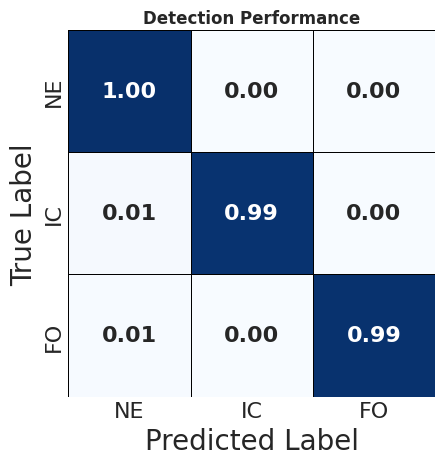

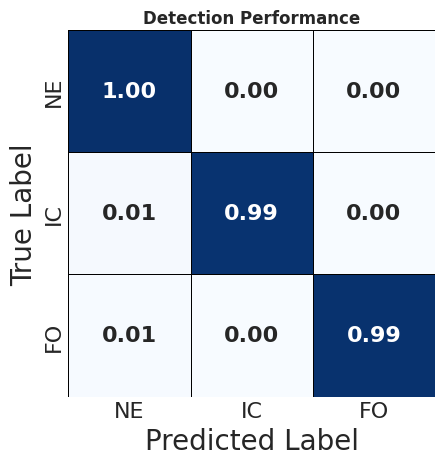

In [441]:
cur_cm = torch.stack(testset_cm).sum(0).numpy()
# cur_cm = cur_cm/cur_cm.sum(1)
utils.plot_confusion_matrix(cur_cm, class_names=["NE", "IC", "FO"], title="Detection Performance", fmt=".2f", cbar_label=["NE", "IC", "FO"], normalize="true")

In [214]:
# # Sanity check using MulticlassConfusionMatrix
# cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
# cm.confmat = torch.tensor(cur_cm)
# fig_, ax_ = cm.plot()

In [215]:
###Plot f1 scores external dataset

# plot_journal_boxplot(extdata1_pc_f1_df, x_col="variable", y_col="value", title="Detection Performance", x_label="Events", y_label="F1 Score")

### 2.5 Plot temporal deviation external dataset

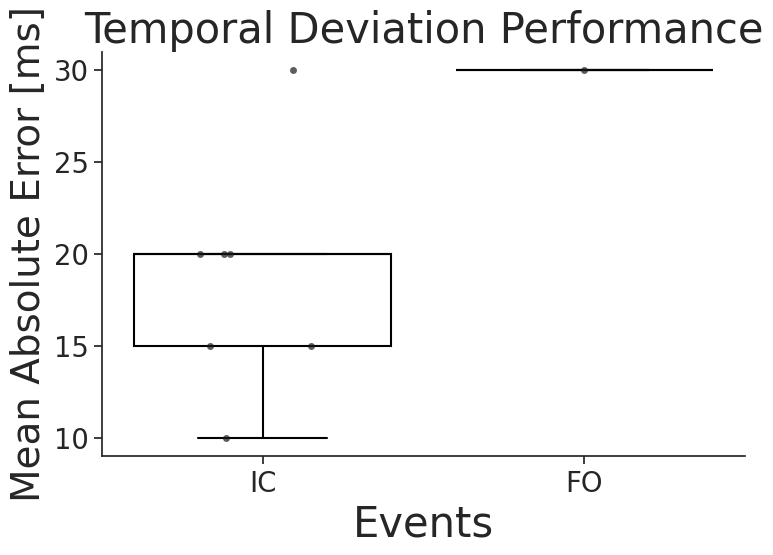

In [217]:
plot_journal_boxplot(extdata1_pc_mae_df, x_col="variable", y_col="value", title="Temporal Deviation Performance", x_label="Events", y_label="Mean Absolute Error [ms]")

In [ ]:
# plotting.plot_xyz(reshaped_input[:, 0], reshaped_input[:, 1], reshaped_input[:, 2], merged_targets.astype(int))
# plotting.plot_xyz(reshaped_input[:, 0], reshaped_input[:, 1], reshaped_input[:, 2], merged_preds.astype(int))

### 3. Evalaute concordance of gait feature

In [434]:
from gait_ml import utils

In [ ]:
# Find all patient ids
subject_ids = [Path(i).parents[3].name for i in test_set_fpaths]

# Take average feature per subject since there are ~
stance_pred = [utils.calculate_gait_phases_vectorized(i) for i in all_preds]
stance_target = [utils.calculate_gait_phases_vectorized(i) for i in all_targets]
stance_pred = utils.aggregate_res(stance_pred, subject_ids)
stance_target = utils.aggregate_res(stance_target, subject_ids)

res_df = pd.concat([stance_pred, stance_target], axis=1)
res_df

/beegfs1/home/qivy00li/projects/gait_ml/src/gait_ml/utils.py:173: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(


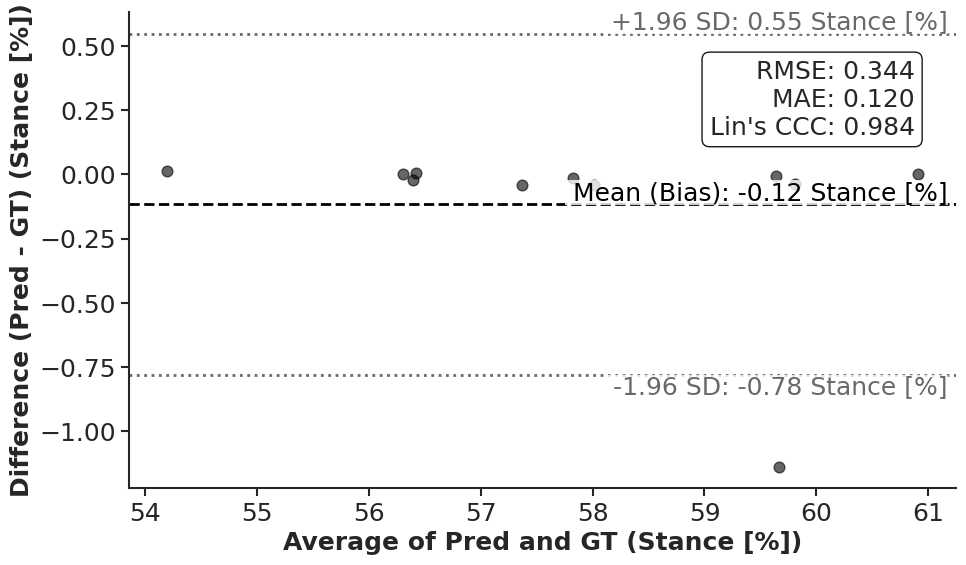

In [440]:
# 2. Call the plotting function
fig, ax = utils.plot_bland_altman_publication(
    res_df.iloc[:, 0], 
    res_df.iloc[:, 1], 
    method1_name='Pred',
    method2_name='GT',
    units='Stance [%]'  # <-- Specify the units here
)